02_Recent_Classification_Methods.ipynb

1. Introduction
2. Imports & Configuration
3. Classification Problem Setup
4. Dataset Preparation
5. Baseline: Logistic Regression
6. Linear SVM
7. Kernel SVM
8. Random Forest
9. Gradient Boosting
10. XGBoost
11. LightGBM
12. CatBoost
13. Modern Neural Classification
14. Calibration & Probability Quality
15. Class Imbalance
16. Threshold Optimization
17. Explainability
18. Comprehensive Model Comparison
19. Error Analysis
20. Practical Model Selection
21. Key Takeaways

# Recent Classification Methods

Classification is a supervised learning problem in which a model learns to assign
observations to one or more discrete classes.

This notebook studies classical and modern classification methods, with particular
attention to methods that are widely used in contemporary machine learning systems.

We will move from simple baselines to more expressive models and then study issues
that become important in practical classification:

- nonlinear decision boundaries
- ensemble learning
- gradient boosting
- modern gradient-boosted tree libraries
- neural classification
- probability calibration
- class imbalance
- decision-threshold optimization
- model interpretability
- systematic model comparison
- error analysis

The goal is not simply to train many classifiers. The goal is to understand **why
different classifiers behave differently and how to select an appropriate method
for a given classification problem**.

---

## Learning Objectives

By the end of this notebook, we should be able to:

1. Explain the fundamental classification problem.
2. Establish a strong baseline using logistic regression.
3. Understand linear and nonlinear decision boundaries.
4. Compare kernel-based and tree-based classifiers.
5. Understand the role of gradient boosting in modern machine learning.
6. Apply XGBoost, LightGBM, and CatBoost to classification problems.
7. Understand neural-network-based classification.
8. Evaluate classifiers using metrics beyond accuracy.
9. Analyze ROC and Precision–Recall curves.
10. Understand probability calibration.
11. Handle imbalanced classification problems.
12. Optimize classification thresholds for a particular objective.
13. Analyze model errors and feature importance.
14. Compare models systematically rather than relying on a single metric.
15. Select a classification method based on data characteristics and practical
    requirements.

---

## Classification as a Learning Problem

Let the input space be

$$
\mathcal{X}\subseteq\mathbb{R}^{d}
$$

and let the set of possible classes be

$$
\mathcal{Y}=\{1,2,\ldots,K\}.
$$

Given a training dataset

$$
\mathcal{D}
=
\{(x_i,y_i)\}_{i=1}^{n},
$$

a classification algorithm learns a function

$$
f:\mathcal{X}\rightarrow\mathcal{Y}.
$$

For probabilistic classification, the model instead estimates

$$
P(Y=k\mid X=x)
$$

for each class $k$.

The final prediction can then be obtained using

$$
\hat{y}
=
\arg\max_{k}
P(Y=k\mid X=x).
$$

The distinction between **predicting a class** and **estimating class
probabilities** is important. In many real-world applications, the probability
estimate is more useful than the class label itself.

---

## Binary Classification

In binary classification, there are two possible classes:

$$
\mathcal{Y}=\{0,1\}.
$$

A classifier produces either a class prediction

$$
\hat{y}\in\{0,1\}
$$

or an estimated probability

$$
\hat{p}=P(Y=1\mid X=x).
$$

A threshold is then used to convert the probability into a class prediction:

$$
\hat{y}
=
\begin{cases}
1 & \text{if } \hat{p}\geq t\\
0 & \text{if } \hat{p}<t
\end{cases}
$$

where $t$ is the classification threshold.

The commonly used threshold $t=0.5$ is not universally optimal.

Changing the threshold can trade off:

- precision
- recall
- false-positive rate
- false-negative rate
- business or application-specific costs

This will become an important topic later in the notebook.

---

## Multiclass Classification

In multiclass classification, there are more than two possible classes:

$$
\mathcal{Y}=\{1,2,\ldots,K\},
\qquad K>2.
$$

A probabilistic classifier estimates

$$
P(Y=k\mid X=x)
$$

for every class.

The predicted class is usually

$$
\hat{y}
=
\arg\max_k P(Y=k\mid X=x).
$$

Multiclass classification introduces additional considerations such as:

- class-specific performance
- macro vs. weighted averaging
- one-vs-rest strategies
- one-vs-one strategies
- multiclass probability estimation

---

## Why Study Multiple Classification Methods?

No single classification algorithm is optimal for every dataset.

Different methods make different assumptions and have different inductive biases.

For example:

| Method | Main Strength | Important Consideration |
|---|---|---|
| Logistic Regression | Simple, interpretable baseline | Linear decision boundary |
| Linear SVM | Strong high-dimensional classifier | Requires appropriate scaling |
| Kernel SVM | Nonlinear decision boundaries | Can become expensive on large datasets |
| Random Forest | Robust nonlinear model | Less efficient than boosting for some tabular problems |
| Gradient Boosting | Powerful sequential ensemble | Requires hyperparameter tuning |
| XGBoost | Highly effective tabular learner | More tuning complexity |
| LightGBM | Fast and scalable boosting | Can overfit with poorly chosen parameters |
| CatBoost | Excellent handling of categorical features | Additional model complexity |
| Neural Networks | Highly flexible representation learning | Usually require more data and tuning |

The purpose of this notebook is therefore to develop a **model-selection
perspective**, rather than assuming that the newest or most complex algorithm is
always the best choice.

---

## A Practical Classification Workflow

A reliable classification workflow generally follows this sequence:

$$
\text{Data}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Baseline}
\rightarrow
\text{Modeling}
\rightarrow
\text{Evaluation}
\rightarrow
\text{Calibration}
\rightarrow
\text{Threshold Selection}
\rightarrow
\text{Error Analysis}
\rightarrow
\text{Model Selection}
$$

A good classifier is not necessarily the classifier with the highest accuracy.

The final choice should consider:

- predictive performance
- generalization
- calibration
- computational cost
- interpretability
- data size
- feature types
- class imbalance
- inference requirements
- maintenance complexity

---

## Notebook Roadmap

We will first establish a baseline using logistic regression.

We will then introduce increasingly expressive classifiers:

$$
\text{Linear Models}
\rightarrow
\text{Kernel Methods}
\rightarrow
\text{Bagging}
\rightarrow
\text{Gradient Boosting}
\rightarrow
\text{Neural Models}
$$

Finally, we will move beyond raw predictive accuracy and investigate:

$$
\text{Probabilities}
\rightarrow
\text{Calibration}
\rightarrow
\text{Thresholds}
\rightarrow
\text{Error Analysis}
\rightarrow
\text{Model Selection}.
$$

This progression will help connect the mathematical foundations of classification
with the methods used in modern machine learning practice.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

NumPy version: 2.5.1
Pandas version: 3.0.5


## 3. Classification Problem Setup

To compare classification methods fairly, we need a controlled dataset where
different types of models have meaningful behavior.

We will construct a synthetic binary classification dataset containing:

- informative features
- redundant features
- noisy features
- moderate class imbalance
- nonlinear relationships
- overlapping classes

The dataset is intentionally more realistic than a perfectly separable toy
dataset.

We will use it throughout the notebook so that differences between classifiers
are easier to interpret.

In [2]:
X, y = make_classification(
    n_samples=6000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    weights=[0.65, 0.35],
    class_sep=0.9,
    flip_y=0.04,
    random_state=RANDOM_STATE
)

X = pd.DataFrame(
    X,
    columns=[f"feature_{i+1}" for i in range(X.shape[1])]
)

y = pd.Series(y, name="target")

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (6000, 20)
Target shape: (6000,)


In [3]:
X.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20
0,0.376263,-1.001279,-0.445670,-1.107442,-0.209283,-2.249195,-3.649200,1.012820,-0.626143,1.585620,0.079188,0.142433,-1.157510,-0.865683,-2.096084,0.566342,-1.399546,2.009595,0.290362,-0.452644
1,1.598959,-1.627768,0.001421,-4.594983,-0.093972,1.237458,-1.113874,-1.937358,-0.909069,-0.579928,-1.180302,-0.355832,1.877752,0.834709,-2.186500,2.477445,-1.315951,0.185311,0.322842,0.580687
2,-2.777550,-0.623019,0.985718,-3.038456,1.145810,5.344341,-1.450501,-3.437971,-0.449895,-1.124729,-0.765974,0.169710,0.013230,2.171127,-0.536818,-3.764993,-1.891657,0.565860,-1.145602,1.624864
3,0.524970,1.293786,0.667938,-5.267766,1.140021,4.396728,-2.116786,-0.317987,-0.612220,-0.057705,0.883637,-0.346263,3.881252,0.991005,0.155403,1.671655,0.451586,1.071767,0.089125,-2.380037
4,-0.178725,-0.929017,-2.529458,1.733607,-0.474070,0.379954,1.747792,0.031414,0.397728,0.733022,0.835361,-2.177413,1.656071,0.705092,-0.495991,2.706946,-0.749042,-1.463768,1.322113,-0.616598


In [4]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   6000 non-null   float64
 1   feature_2   6000 non-null   float64
 2   feature_3   6000 non-null   float64
 3   feature_4   6000 non-null   float64
 4   feature_5   6000 non-null   float64
 5   feature_6   6000 non-null   float64
 6   feature_7   6000 non-null   float64
 7   feature_8   6000 non-null   float64
 8   feature_9   6000 non-null   float64
 9   feature_10  6000 non-null   float64
 10  feature_11  6000 non-null   float64
 11  feature_12  6000 non-null   float64
 12  feature_13  6000 non-null   float64
 13  feature_14  6000 non-null   float64
 14  feature_15  6000 non-null   float64
 15  feature_16  6000 non-null   float64
 16  feature_17  6000 non-null   float64
 17  feature_18  6000 non-null   float64
 18  feature_19  6000 non-null   float64
 19  feature_20  6000 non-null   float64
dt

In [5]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
feature_1,6000.0,-0.008031,1.900439,-6.121805,-1.309879,-0.057520,1.256026,8.050769
feature_2,6000.0,-0.015309,0.994693,-3.768876,-0.672855,-0.016665,0.654063,3.249630
feature_3,6000.0,0.564848,1.907432,-7.055123,-0.534709,0.627879,1.745748,8.267467
feature_4,6000.0,-2.107846,3.189153,-14.669620,-4.214339,-2.074527,-0.034562,10.522831
feature_5,6000.0,-0.001009,0.991230,-3.318567,-0.672204,0.009867,0.670524,3.899964
feature_6,6000.0,1.344619,3.794919,-17.175049,-0.852622,2.049891,4.023965,14.271133
feature_7,6000.0,-0.295037,1.749953,-6.808747,-1.469745,-0.321191,0.820138,6.893526
feature_8,6000.0,-0.923643,1.707015,-6.777965,-2.048649,-0.902130,0.204975,7.384134
feature_9,6000.0,0.001582,0.979390,-3.387346,-0.649721,-0.015826,0.652972,3.680782
feature_10,6000.0,0.255612,1.836123,-6.889445,-1.028258,0.217703,1.510781,7.530627


### Class Distribution

Before training a classifier, we should inspect the target distribution.

Accuracy can be misleading when one class is substantially more common than
another. Therefore, understanding the class balance is an important part of
classification analysis.

In [6]:
class_counts = y.value_counts().sort_index()

print(class_counts)

class_proportions = y.value_counts(normalize=True).sort_index()

print("\nClass proportions:")
print(class_proportions)

target
0    3859
1    2141
Name: count, dtype: int64

Class proportions:
target
0    0.643167
1    0.356833
Name: proportion, dtype: float64


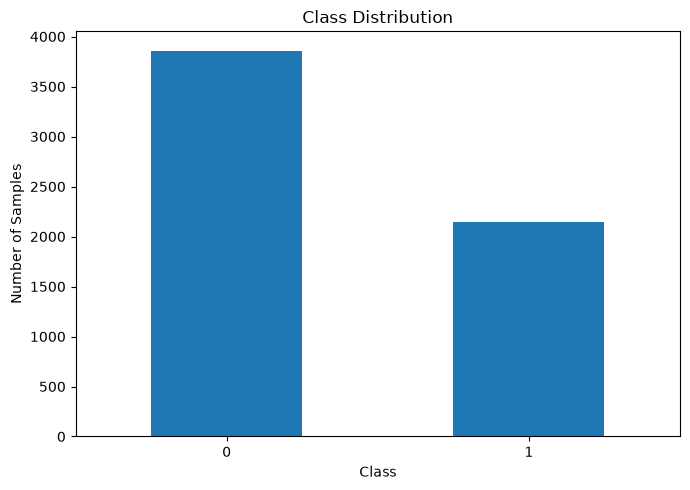

In [7]:
plt.figure(figsize=(7, 5))

class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Train/Test Split

We separate the dataset into training and test sets.

Stratification is used so that the relative proportion of each class is preserved
in both subsets.

The test set will remain untouched during model development and will be used
only for final evaluation.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Training samples: 4800
Test samples: 1200

Training class proportions:
target
0    0.643125
1    0.356875
Name: proportion, dtype: float64

Test class proportions:
target
0    0.643333
1    0.356667
Name: proportion, dtype: float64


Visualize the feature relationships

Because the dataset has 20 dimensions, we cannot directly visualize the full
feature space. For an initial look, inspect a few feature pairs.

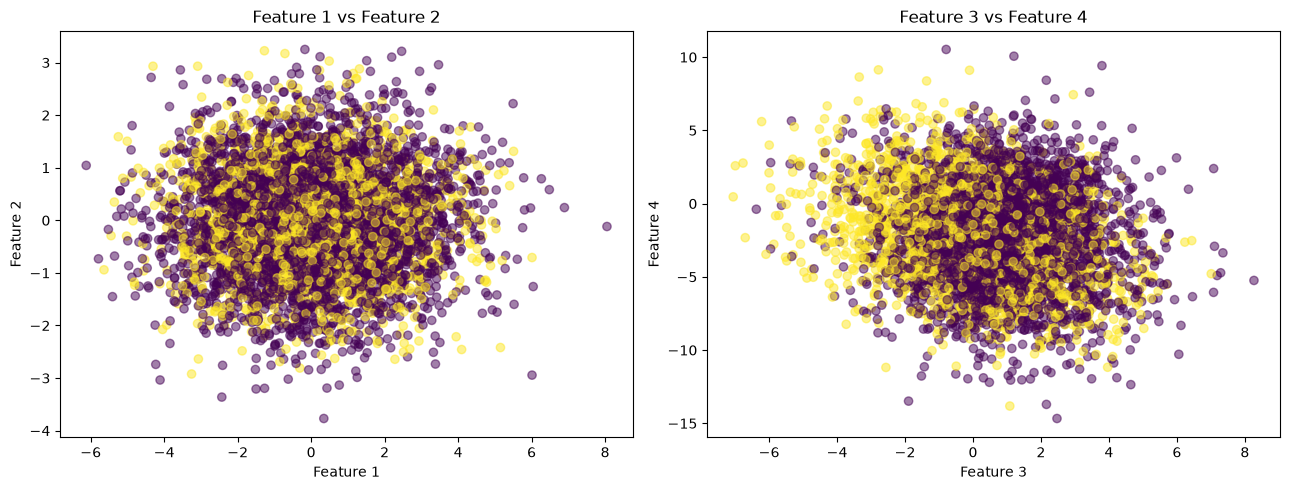

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(
    X["feature_1"],
    X["feature_2"],
    c=y,
    alpha=0.5
)

axes[0].set_title("Feature 1 vs Feature 2")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(
    X["feature_3"],
    X["feature_4"],
    c=y,
    alpha=0.5
)

axes[1].set_title("Feature 3 vs Feature 4")
axes[1].set_xlabel("Feature 3")
axes[1].set_ylabel("Feature 4")

plt.tight_layout()
plt.show()

## Correlation structure

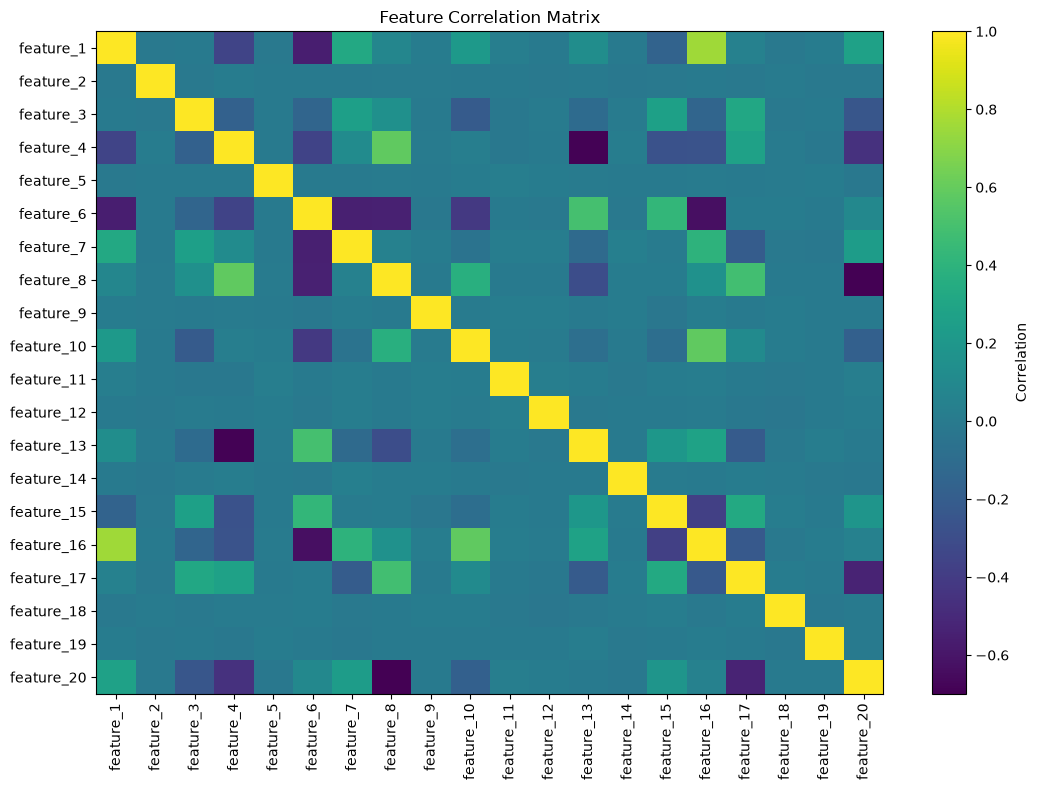

In [10]:
correlation_matrix = X.corr()

plt.figure(figsize=(11, 8))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Experimental Design

Our classification problem has several characteristics that make it useful for
model comparison.

The data contains redundant information, noise, overlapping classes, and class
imbalance. Consequently, a classifier must learn useful structure while avoiding
overfitting to irrelevant variation.

This gives us a useful experimental setting for comparing:

$$
\text{linear models}
\quad\text{vs.}\quad
\text{nonlinear models}
\quad\text{vs.}\quad
\text{ensemble methods}
\quad\text{vs.}\quad
\text{neural models}.
$$

We will now establish a simple baseline before moving to more sophisticated
classification methods.

## 4. Logistic Regression Baseline

Logistic regression is one of the most important classification baselines.

Despite its simplicity, it provides:

- a strong and interpretable baseline
- probabilistic predictions
- a linear decision boundary
- relatively fast training
- useful coefficients for understanding feature effects

For binary classification, logistic regression models the probability of the
positive class as

$$
P(Y=1\mid X=x)
=
\sigma(w^\top x+b),
$$

where the sigmoid function is

$$
\sigma(z)
=
\frac{1}{1+e^{-z}}.
$$

The model is trained by minimizing the binary cross-entropy loss:

$$
\mathcal{L}
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right].
$$

The resulting decision boundary is linear in the original feature space.

This makes logistic regression a useful baseline: if a complex model cannot
substantially outperform it, the additional complexity may not be justified.

## Build a preprocessing pipeline

In [11]:
logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic regression trained successfully.")

Logistic regression trained successfully.


## Generate predictions

In [12]:
y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("First 10 predicted classes:")
print(y_pred_logistic[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_logistic[:10])

First 10 predicted classes:
[0 0 0 1 0 1 0 1 0 0]

First 10 predicted probabilities:
[0.44983338 0.18296388 0.18689614 0.55892481 0.19700816 0.64764649
 0.09531597 0.56547708 0.27537736 0.11396101]


## Generate predictions

In [13]:
y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("First 10 predicted classes:")
print(y_pred_logistic[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_logistic[:10])

First 10 predicted classes:
[0 0 0 1 0 1 0 1 0 0]

First 10 predicted probabilities:
[0.44983338 0.18296388 0.18689614 0.55892481 0.19700816 0.64764649
 0.09531597 0.56547708 0.27537736 0.11396101]


## Classification metrics

In [14]:
logistic_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_logistic),
    "Precision": precision_score(y_test, y_pred_logistic),
    "Recall": recall_score(y_test, y_pred_logistic),
    "F1": f1_score(y_test, y_pred_logistic),
    "ROC-AUC": roc_auc_score(y_test, y_prob_logistic),
    "PR-AUC": average_precision_score(y_test, y_prob_logistic)
}

pd.Series(logistic_metrics).round(4)

Accuracy     0.7058
Precision    0.6271
Recall       0.4322
F1           0.5118
ROC-AUC      0.7280
PR-AUC       0.5845
dtype: float64

In [15]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Class 0", "Class 1"]
    )
)

              precision    recall  f1-score   support

     Class 0       0.73      0.86      0.79       772
     Class 1       0.63      0.43      0.51       428

    accuracy                           0.71      1200
   macro avg       0.68      0.64      0.65      1200
weighted avg       0.69      0.71      0.69      1200



### Confusion Matrix

For binary classification, predictions can be divided into four categories:

- **True Positive (TP):** positive example correctly classified
- **True Negative (TN):** negative example correctly classified
- **False Positive (FP):** negative example incorrectly classified as positive
- **False Negative (FN):** positive example incorrectly classified as negative

The confusion matrix allows us to see these errors directly rather than reducing
performance to a single number.

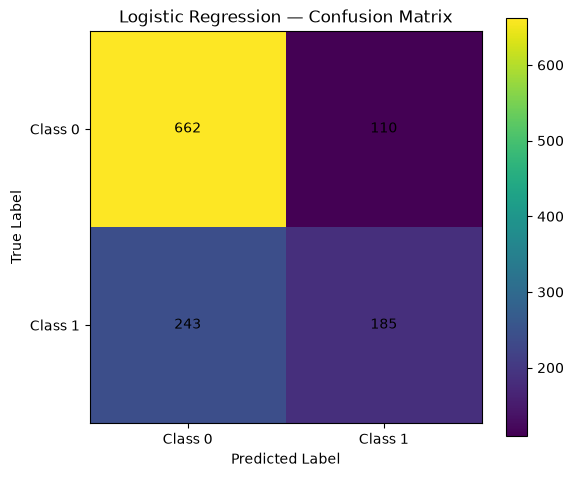

In [16]:
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## ROC and Precision–Recall curves

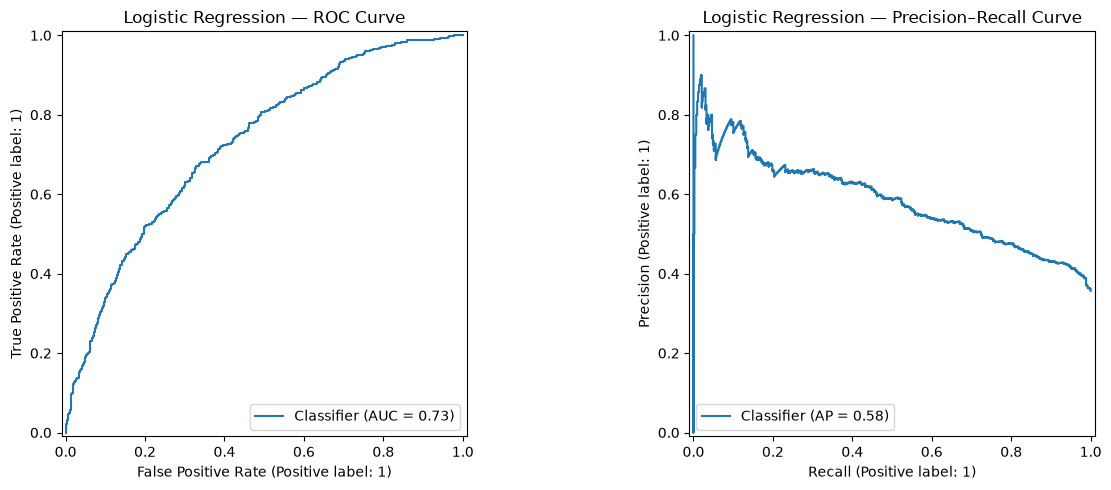

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    ax=axes[0]
)

axes[0].set_title("Logistic Regression — ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    ax=axes[1]
)

axes[1].set_title("Logistic Regression — Precision–Recall Curve")

plt.tight_layout()
plt.show()

### Model Coefficients

Because the features were standardized, the learned coefficients provide a
rough indication of the direction and relative strength of each feature's
association with the predicted class.

A positive coefficient increases the log-odds of Class 1, while a negative
coefficient decreases them.

The coefficients should be interpreted as model parameters rather than proof of
causality.

In [18]:
classifier = logistic_model.named_steps["classifier"]

coefficients = pd.Series(
    classifier.coef_[0],
    index=X_train.columns
).sort_values()

coefficients

feature_15   -0.437585
feature_7    -0.350693
feature_3    -0.251577
feature_8    -0.222641
feature_20   -0.189598
feature_1    -0.098318
feature_9    -0.027162
feature_4    -0.015391
feature_13   -0.013124
feature_14   -0.007256
feature_18   -0.001534
feature_2     0.020106
feature_11    0.031275
feature_19    0.035694
feature_5     0.037589
feature_12    0.042348
feature_6     0.105447
feature_17    0.123533
feature_16    0.155157
feature_10    0.448440
dtype: float64

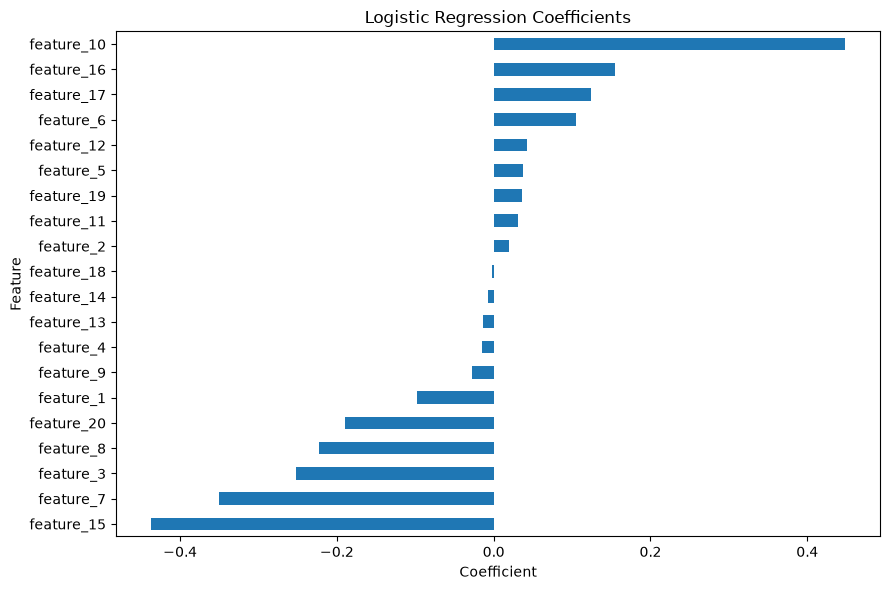

In [19]:
plt.figure(figsize=(9, 6))

coefficients.plot(kind="barh")

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Baseline Interpretation

Logistic regression provides our reference performance.

Its main limitation is structural:

$$
w^\top x+b=0
$$

defines a linear decision boundary.

If the true relationship between the features and target is strongly nonlinear,
a linear classifier may systematically underfit the problem.

This motivates the next methods.

We will first investigate **Support Vector Machines**, which can construct
nonlinear decision boundaries through kernel functions.

## 5. Support Vector Machines

Support Vector Machines construct a decision boundary that attempts to separate
classes while maximizing the margin between them.

For a linear classifier, the decision function is

$$
f(x)=w^\top x+b.
$$

The separating hyperplane is

$$
w^\top x+b=0.
$$

The margin is maximized by minimizing the magnitude of $w$ while penalizing
classification violations.

The soft-margin SVM optimization problem can be written as

$$
\min_{w,b,\xi}
\frac{1}{2}\|w\|^2
+
C\sum_{i=1}^{n}\xi_i
$$

subject to

$$
y_i(w^\top x_i+b)\geq 1-\xi_i,
\qquad
\xi_i\geq0.
$$

Here:

- $C$ controls the penalty for margin violations.
- $\xi_i$ are slack variables.
- larger $C$ places more emphasis on correctly classifying training examples.
- smaller $C$ allows a wider margin with more training violations.

SVMs are particularly useful when the number of features is relatively large
and the dataset is not excessively large.

## Linear SVM

In [20]:
linear_svm = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            SVC(
                kernel="linear",
                C=1.0,
                probability=True,
                random_state=RANDOM_STATE
            )
        )
    ]
)

linear_svm.fit(X_train, y_train)

y_pred_linear_svm = linear_svm.predict(X_test)
y_prob_linear_svm = linear_svm.predict_proba(X_test)[:, 1]

print("Linear SVM trained successfully.")

Linear SVM trained successfully.


## Evaluate Linear SVM

In [21]:
linear_svm_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_linear_svm),
    "Precision": precision_score(y_test, y_pred_linear_svm),
    "Recall": recall_score(y_test, y_pred_linear_svm),
    "F1": f1_score(y_test, y_pred_linear_svm),
    "ROC-AUC": roc_auc_score(y_test, y_prob_linear_svm),
    "PR-AUC": average_precision_score(y_test, y_prob_linear_svm)
}

pd.Series(linear_svm_metrics).round(4)

Accuracy     0.7067
Precision    0.6484
Recall       0.3879
F1           0.4854
ROC-AUC      0.7192
PR-AUC       0.6148
dtype: float64

### The Kernel Trick

A linear SVM can only construct a linear decision boundary in the original
feature space.

However, a nonlinear transformation

$$
\phi(x)
$$

can map the observations into a higher-dimensional feature space where a linear
separator may exist.

Instead of explicitly computing $\phi(x)$, kernel methods compute similarities
using a kernel function:

$$
K(x_i,x_j)
=
\phi(x_i)^\top\phi(x_j).
$$

This is known as the **kernel trick**.

A commonly used kernel is the radial basis function (RBF):

$$
K(x_i,x_j)
=
\exp
\left(
-\gamma\|x_i-x_j\|^2
\right).
$$

The parameter $\gamma$ controls how local the influence of individual training
points becomes.

- small $\gamma$ → smoother, broader influence
- large $\gamma$ → more localized influence

The combination of $C$ and $\gamma$ strongly affects the complexity of an RBF
SVM.

## RBF Kernel SVM

In [22]:
rbf_svm = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            SVC(
                kernel="rbf",
                C=2.0,
                gamma="scale",
                probability=True,
                random_state=RANDOM_STATE
            )
        )
    ]
)

rbf_svm.fit(X_train, y_train)

y_pred_rbf_svm = rbf_svm.predict(X_test)
y_prob_rbf_svm = rbf_svm.predict_proba(X_test)[:, 1]

print("RBF SVM trained successfully.")

RBF SVM trained successfully.


## Evaluate RBF SVM

In [23]:
rbf_svm_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rbf_svm),
    "Precision": precision_score(y_test, y_pred_rbf_svm),
    "Recall": recall_score(y_test, y_pred_rbf_svm),
    "F1": f1_score(y_test, y_pred_rbf_svm),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rbf_svm),
    "PR-AUC": average_precision_score(y_test, y_prob_rbf_svm)
}

pd.Series(rbf_svm_metrics).round(4)

Accuracy     0.8833
Precision    0.8830
Recall       0.7757
F1           0.8259
ROC-AUC      0.9358
PR-AUC       0.9013
dtype: float64

## Compare linear and nonlinear SVM

In [24]:
svm_comparison = pd.DataFrame(
    {
        "Linear SVM": linear_svm_metrics,
        "RBF SVM": rbf_svm_metrics
    }
).T

svm_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Linear SVM,0.7067,0.6484,0.3879,0.4854,0.7192,0.6148
RBF SVM,0.8833,0.8830,0.7757,0.8259,0.9358,0.9013


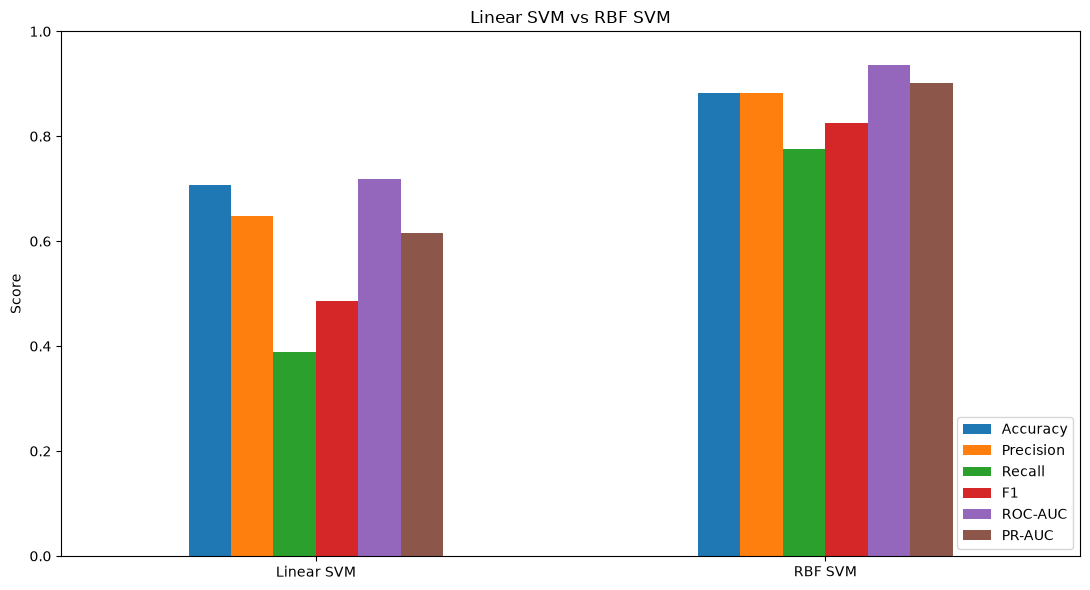

In [25]:
svm_comparison[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Linear SVM vs RBF SVM")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

## ROC comparison

<Figure size 800x600 with 0 Axes>

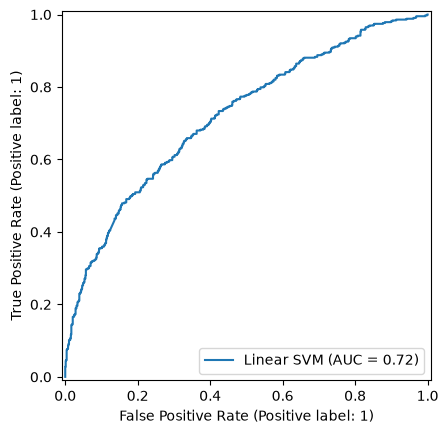

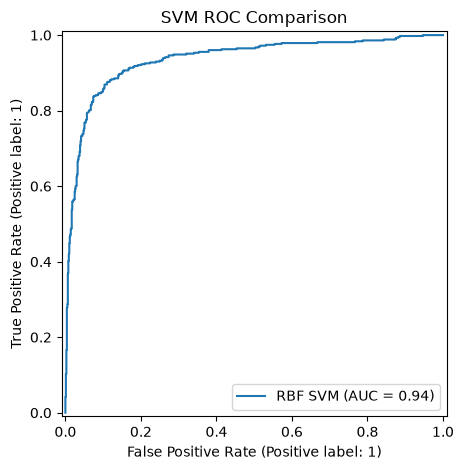

In [26]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_linear_svm,
    name="Linear SVM"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rbf_svm,
    name="RBF SVM"
)

plt.title("SVM ROC Comparison")
plt.tight_layout()
plt.show()

## Precision–Recall comparison

<Figure size 800x600 with 0 Axes>

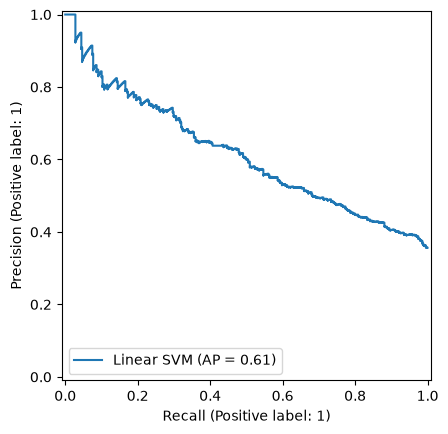

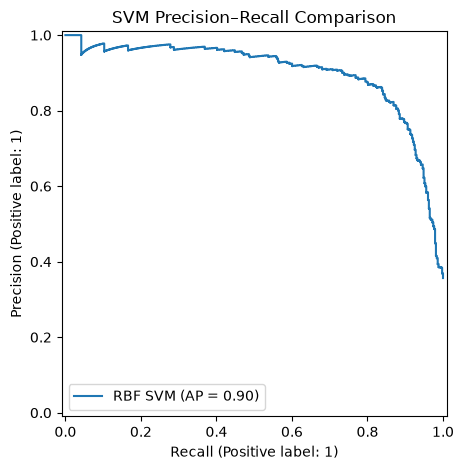

In [27]:
plt.figure(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_linear_svm,
    name="Linear SVM"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rbf_svm,
    name="RBF SVM"
)

plt.title("SVM Precision–Recall Comparison")
plt.tight_layout()
plt.show()

### Decision Scores

SVMs naturally produce a decision score indicating which side of the decision
boundary an observation lies on.

For a linear SVM:

$$
f(x)=w^\top x+b.
$$

The sign of the score determines the predicted class:

$$
\hat{y}=
\begin{cases}
1 & f(x)>0\\
0 & f(x)\leq0.
\end{cases}
$$

The magnitude of the score represents the distance from the decision boundary
up to a scaling factor.

This is different from a calibrated probability. A decision score should not
automatically be interpreted as

$$
P(Y=1\mid X=x).
$$

In [28]:
decision_scores = rbf_svm.decision_function(X_test)

print("First 10 RBF SVM decision scores:")
print(decision_scores[:10])

First 10 RBF SVM decision scores:
[ 0.8248257  -1.4410219  -1.49003803  0.27163491 -1.29954276  0.11460684
 -2.72326703 -0.63679051  2.96805066 -0.99307334]


### SVM Takeaways

The comparison demonstrates an important principle:

> Increasing model flexibility can help when the underlying classification
> relationship is nonlinear, but flexibility also increases computational and
> tuning requirements.

Linear SVMs are attractive when the decision structure is approximately linear.

RBF SVMs can model substantially more complex boundaries, but their computational
cost can become problematic as the number of training observations grows.

For large tabular datasets, this motivates another family of models that has
become extremely important in modern machine learning:

$$
\boxed{\text{Tree-based ensemble methods}}
$$

In the next section, we will introduce **Random Forests** and examine why
ensembles of decision trees can capture nonlinear interactions without requiring
explicit feature transformations.

## 6. Random Forest Classification

A decision tree recursively partitions the feature space into regions.

For classification, a common impurity measure is the Gini impurity:

$$
G(t)
=
1-\sum_{k=1}^{K}p_{k|t}^{2},
$$

where $p_{k|t}$ is the proportion of observations belonging to class $k$
within node $t$.

A split is selected by reducing impurity.

Decision trees can naturally represent nonlinear relationships and feature
interactions. However, a single deep tree can have high variance and overfit.

Random Forest addresses this problem by constructing an ensemble of decision
trees using two sources of randomness:

1. bootstrap samples of the training observations
2. random subsets of features considered at each split

The prediction is obtained by aggregating the predictions of many trees.

For classification, the ensemble prediction can be represented as

$$
\hat{y}
=
\operatorname{mode}
\left(
T_1(x),T_2(x),\ldots,T_B(x)
\right),
$$

where $B$ is the number of trees.

The central idea is **variance reduction through averaging**.

In [29]:
random_forest = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


## Evaluate the model

In [30]:
rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
    "PR-AUC": average_precision_score(y_test, y_prob_rf)
}

pd.Series(rf_metrics).round(4)

Accuracy     0.8958
Precision    0.8855
Recall       0.8131
F1           0.8477
ROC-AUC      0.9467
PR-AUC       0.9137
dtype: float64

## Confusion matrix

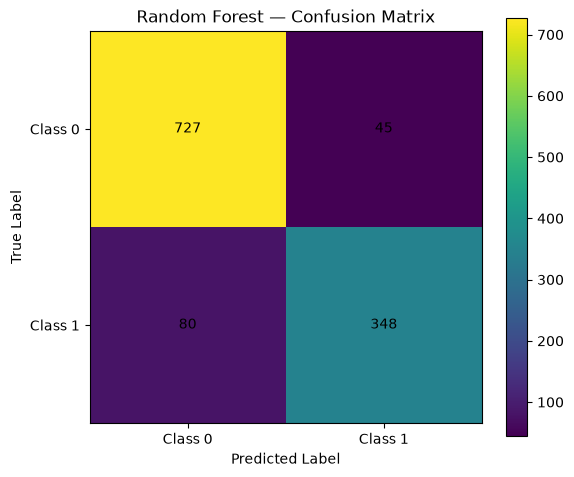

In [31]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
plt.imshow(cm_rf)

plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_rf[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

### Feature Importance

Random Forest provides feature-importance estimates based on the reduction in
impurity produced by splits involving each feature.

The resulting importance values satisfy

$$
\sum_{j=1}^{d}I_j=1.
$$

A larger value indicates that the feature contributed more to impurity reduction
across the ensemble.

However, impurity-based importance has limitations. In particular, it can be
biased toward features with many possible split points or high cardinality.

Therefore, feature importance should be treated as a model diagnostic rather
than definitive evidence that a feature is intrinsically important.

In [32]:
rf_importance = pd.Series(
    random_forest.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

rf_importance

feature_3     0.091506
feature_17    0.088074
feature_6     0.086695
feature_15    0.075612
feature_7     0.075179
feature_16    0.072557
feature_10    0.071508
feature_13    0.062149
feature_8     0.057478
feature_20    0.057452
feature_1     0.049221
feature_4     0.047388
feature_18    0.021685
feature_19    0.021274
feature_5     0.021112
feature_14    0.020844
feature_9     0.020699
feature_11    0.019963
feature_2     0.019898
feature_12    0.019704
dtype: float64

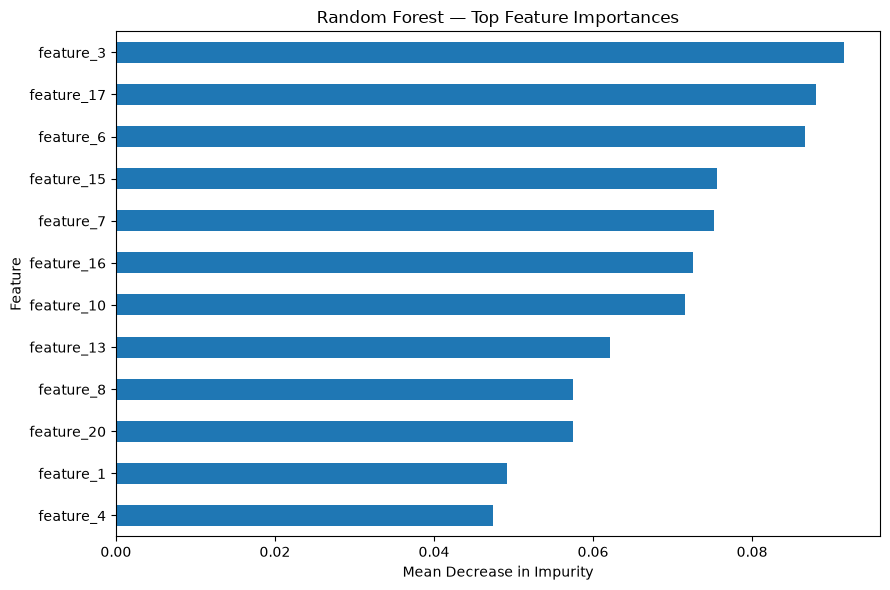

In [33]:
top_rf_importance = rf_importance.head(12).sort_values()

plt.figure(figsize=(9, 6))

top_rf_importance.plot(kind="barh")

plt.title("Random Forest — Top Feature Importances")
plt.xlabel("Mean Decrease in Impurity")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Out-of-Bag Evaluation

Random Forest training uses bootstrap samples.

For each tree, some training observations are not selected for that tree's
bootstrap sample. These observations are called **out-of-bag (OOB) samples**
for that tree.

Across the ensemble, OOB observations can be used to estimate generalization
performance without requiring a separate validation set.

We can therefore enable OOB evaluation:

$$
\text{OOB Score}
\approx
\text{generalization performance}.
$$

The OOB estimate is useful during model development, although a final untouched
test set remains important for unbiased final evaluation.

Create an OOB-enabled forest:

In [34]:
random_forest_oob = RandomForestClassifier(
    n_estimators=400,
    max_features="sqrt",
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_forest_oob.fit(X_train, y_train)

print("OOB accuracy:", round(random_forest_oob.oob_score_, 4))

OOB accuracy: 0.9


## OOB probability predictions

In [35]:
oob_probabilities = random_forest_oob.oob_decision_function_[:, 1]

oob_roc_auc = roc_auc_score(
    y_train,
    oob_probabilities
)

oob_pr_auc = average_precision_score(
    y_train,
    oob_probabilities
)

print("OOB ROC-AUC:", round(oob_roc_auc, 4))
print("OOB PR-AUC:", round(oob_pr_auc, 4))

OOB ROC-AUC: 0.9485
OOB PR-AUC: 0.9228


## Compare Logistic Regression, SVM, and Random Forest

In [36]:
model_comparison = pd.DataFrame(
    {
        "Logistic Regression": logistic_metrics,
        "Linear SVM": linear_svm_metrics,
        "RBF SVM": rbf_svm_metrics,
        "Random Forest": rf_metrics
    }
).T

model_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.7058,0.6271,0.4322,0.5118,0.7280,0.5845
Linear SVM,0.7067,0.6484,0.3879,0.4854,0.7192,0.6148
RBF SVM,0.8833,0.8830,0.7757,0.8259,0.9358,0.9013
Random Forest,0.8958,0.8855,0.8131,0.8477,0.9467,0.9137


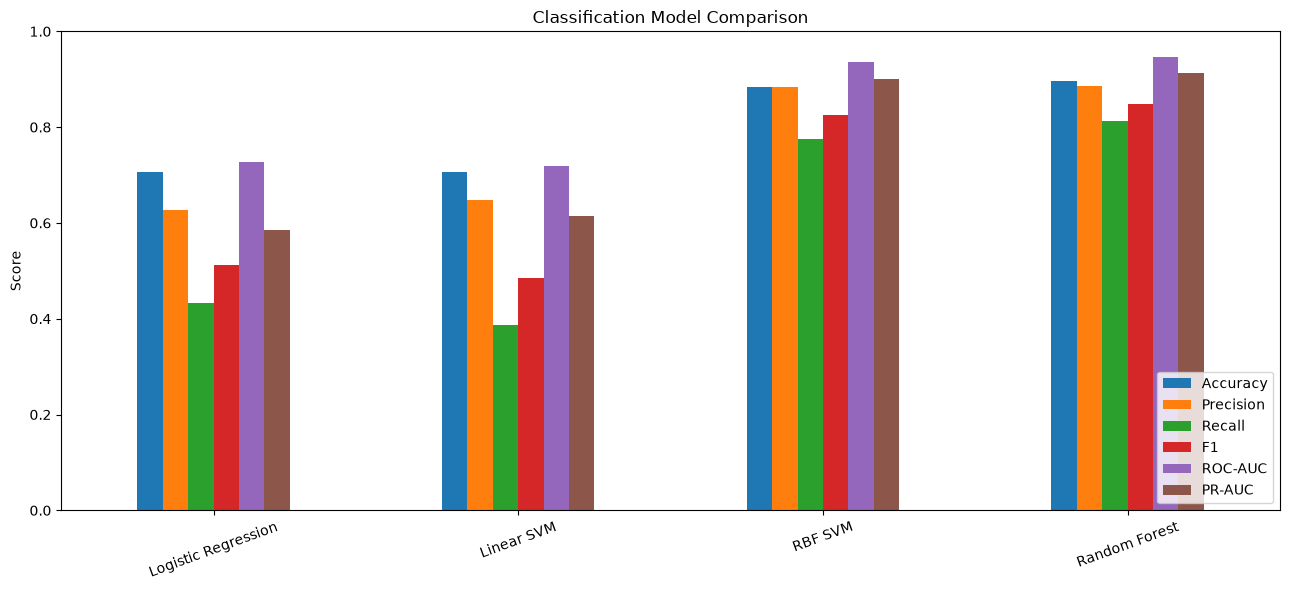

In [37]:
model_comparison[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

## ROC comparison

<Figure size 800x600 with 0 Axes>

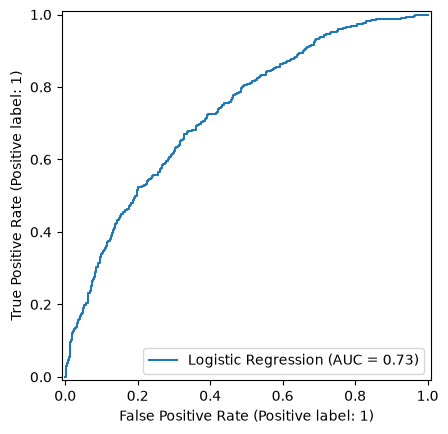

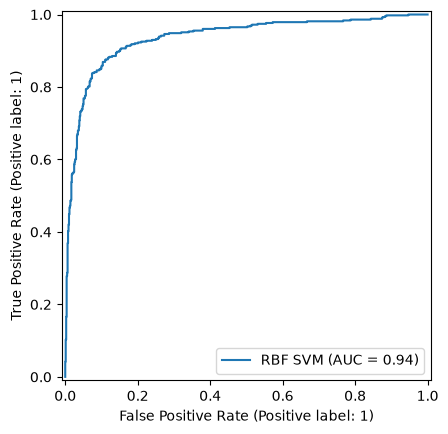

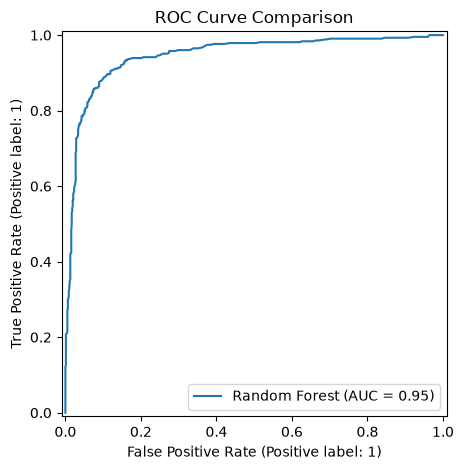

In [38]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rbf_svm,
    name="RBF SVM"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

## Precision–Recall comparison

<Figure size 800x600 with 0 Axes>

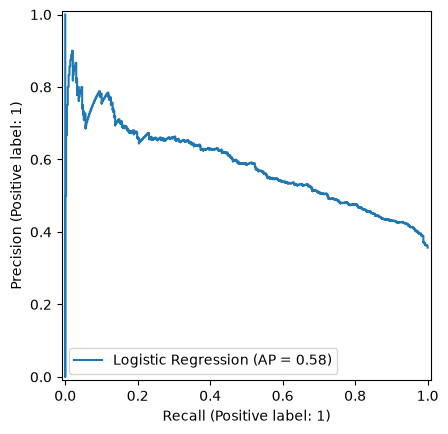

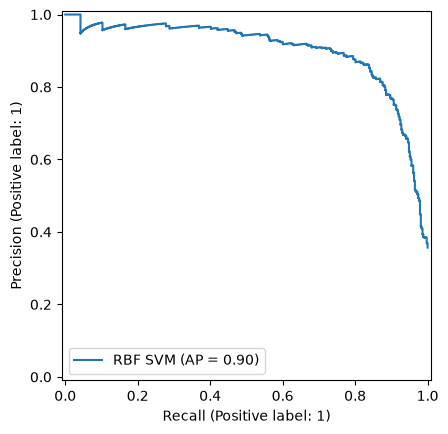

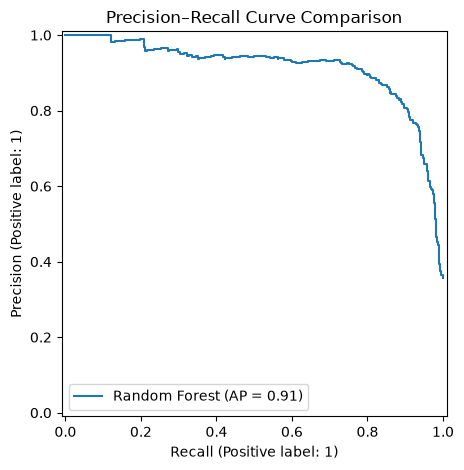

In [39]:
plt.figure(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rbf_svm,
    name="RBF SVM"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

plt.title("Precision–Recall Curve Comparison")
plt.tight_layout()
plt.show()

### Random Forest Takeaways

Random Forest provides several advantages over linear models:

- nonlinear decision boundaries
- automatic feature interaction modeling
- relatively little preprocessing
- robustness to noisy features
- good performance on many tabular datasets
- built-in feature-importance estimates
- OOB evaluation

However, Random Forest is not always the strongest tree-based method.

Random Forest builds trees largely independently and then averages them:

$$
\text{Random Forest}
=
\text{many independent trees}
+
\text{aggregation}.
$$

A different strategy is to build trees **sequentially**, where each new tree
attempts to correct errors made by the existing ensemble.

This leads to **gradient boosting**:

$$
\boxed{
\text{Gradient Boosting}
}
$$

Gradient boosting has become one of the most important approaches for
structured/tabular classification problems and forms the foundation of modern
libraries such as XGBoost, LightGBM, and CatBoost.

## 7. Gradient Boosting Classification

Random Forest reduces variance by averaging many independently trained trees.

Gradient boosting takes a different approach.

Instead of building independent trees, boosting builds a sequence of weak
learners. Each new learner attempts to improve the current ensemble.

For an additive model, we can write

$$
F_M(x)
=
F_0(x)
+
\sum_{m=1}^{M}\eta h_m(x),
$$

where:

- $F_0(x)$ is the initial model,
- $h_m(x)$ is the learner added at iteration $m$,
- $M$ is the number of boosting iterations,
- $\eta$ is the learning rate.

For classification, gradient boosting can be understood as minimizing a
differentiable loss function.

At iteration $m$, the next learner is fitted to information related to the
negative gradient of the loss:

$$
r_{im}
=
-
\left[
\frac{\partial L(y_i,F(x_i))}
{\partial F(x_i)}
\right]_{F=F_{m-1}}.
$$

The new model then becomes

$$
F_m(x)
=
F_{m-1}(x)
+
\eta h_m(x).
$$

This creates a powerful sequential learning process.

### Important hyperparameters

The most important parameters include:

- `n_estimators`: number of boosting stages
- `learning_rate`: contribution of each tree
- `max_depth`: complexity of individual trees
- `min_samples_leaf`: minimum observations in a leaf
- `subsample`: fraction of observations used by each stage

There is an important relationship between learning rate and the number of
estimators:

$$
\text{smaller learning rate}
\quad\Longrightarrow\quad
\text{more boosting stages are often required}.
$$

In [40]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=5,
    subsample=0.9,
    random_state=RANDOM_STATE
)

gradient_boosting.fit(X_train, y_train)

y_pred_gb = gradient_boosting.predict(X_test)
y_prob_gb = gradient_boosting.predict_proba(X_test)[:, 1]

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


## Evaluate

In [41]:
gb_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_gb),
    "Precision": precision_score(y_test, y_pred_gb),
    "Recall": recall_score(y_test, y_pred_gb),
    "F1": f1_score(y_test, y_pred_gb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_gb),
    "PR-AUC": average_precision_score(y_test, y_prob_gb)
}

pd.Series(gb_metrics).round(4)

Accuracy     0.8633
Precision    0.8568
Recall       0.7407
F1           0.7945
ROC-AUC      0.9189
PR-AUC       0.8519
dtype: float64

## Confusion matrix

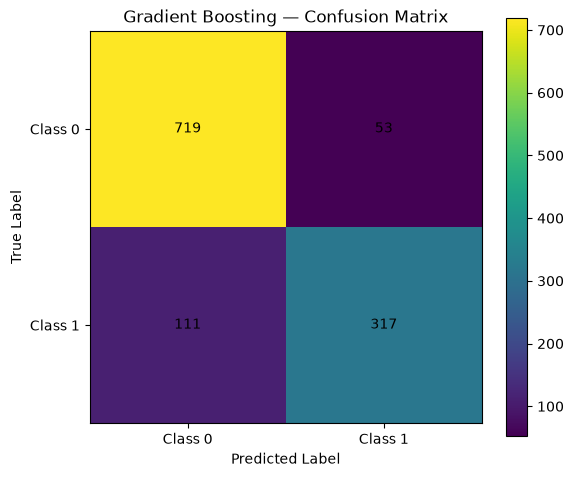

In [42]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 5))
plt.imshow(cm_gb)

plt.title("Gradient Boosting — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_gb[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## Feature importance

In [44]:
gb_importance = pd.Series(
    gradient_boosting.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

gb_importance.head(12)

feature_6     0.141976
feature_17    0.140777
feature_3     0.133595
feature_7     0.117667
feature_15    0.074117
feature_16    0.072810
feature_10    0.072316
feature_8     0.067006
feature_20    0.053008
feature_13    0.041074
feature_1     0.036691
feature_4     0.025605
dtype: float64

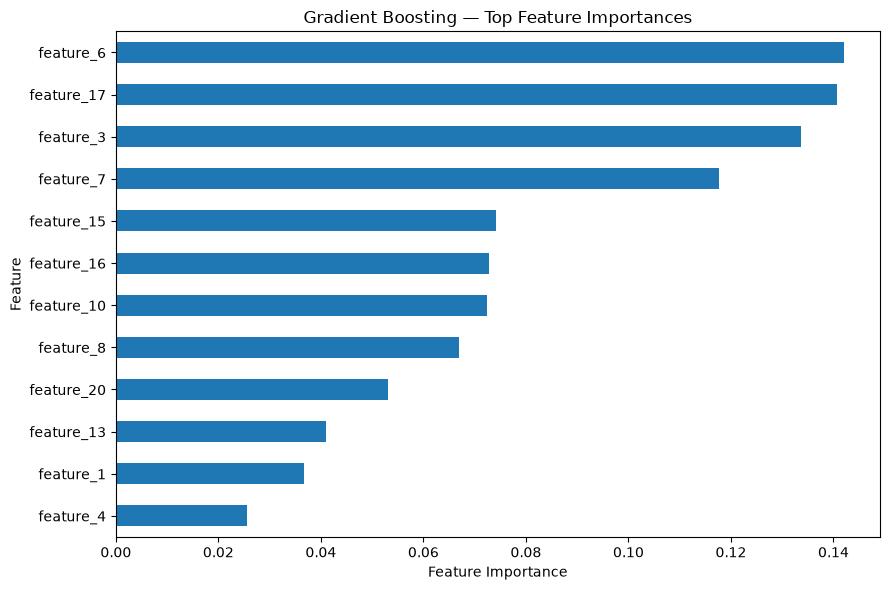

In [45]:
plt.figure(figsize=(9, 6))

gb_importance.head(12).sort_values().plot(kind="barh")

plt.title("Gradient Boosting — Top Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Performance Across Boosting Stages

A major advantage of boosting is that we can inspect how the ensemble develops
as additional trees are added.

The model can be written as

$$
F_1(x)
\rightarrow
F_2(x)
\rightarrow
\cdots
\rightarrow
F_M(x).
$$

Too few boosting stages can lead to underfitting, while excessive model
complexity can eventually lead to overfitting.

Examining performance across stages gives us insight into this bias-variance
trade-off.

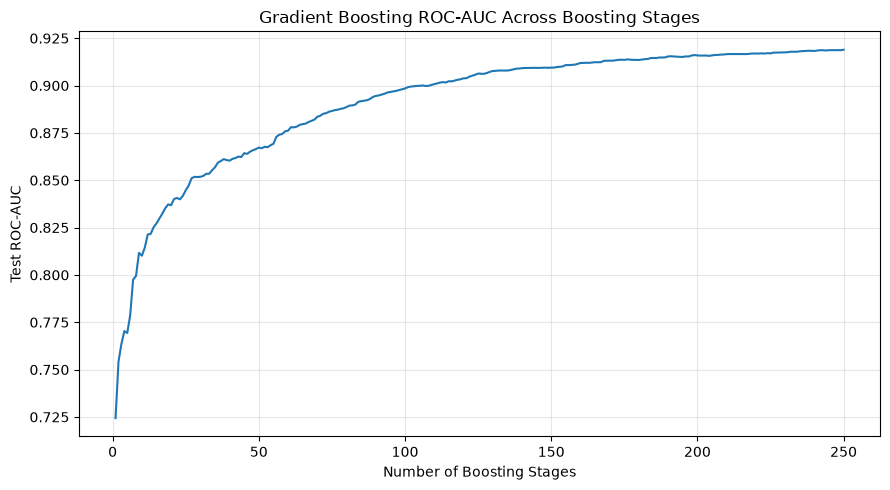

In [46]:
stages = np.arange(
    1,
    gradient_boosting.n_estimators + 1
)

test_scores = []

for y_stage_prob in gradient_boosting.staged_predict_proba(X_test):
    test_scores.append(
        roc_auc_score(
            y_test,
            y_stage_prob[:, 1]
        )
    )

plt.figure(figsize=(9, 5))

plt.plot(stages, test_scores)

plt.title("Gradient Boosting ROC-AUC Across Boosting Stages")
plt.xlabel("Number of Boosting Stages")
plt.ylabel("Test ROC-AUC")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Learning Rate and Number of Trees

Gradient boosting contains an important trade-off between the learning rate
and the number of estimators.

A large learning rate allows each tree to make a larger correction:

$$
F_m(x)=F_{m-1}(x)+\eta h_m(x).
$$

A smaller $\eta$ makes each correction more conservative.

In practice, smaller learning rates combined with more boosting stages often
produce smoother optimization, although the best combination depends on the
dataset.

In [47]:
boosting_configs = {
    "Fast": {
        "learning_rate": 0.15,
        "n_estimators": 100
    },
    "Balanced": {
        "learning_rate": 0.05,
        "n_estimators": 250
    },
    "Slow": {
        "learning_rate": 0.02,
        "n_estimators": 500
    }
}

learning_rate_results = []

for name, params in boosting_configs.items():
    model = GradientBoostingClassifier(
        learning_rate=params["learning_rate"],
        n_estimators=params["n_estimators"],
        max_depth=3,
        min_samples_leaf=5,
        subsample=0.9,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_test)[:, 1]

    learning_rate_results.append(
        {
            "Configuration": name,
            "Learning Rate": params["learning_rate"],
            "Estimators": params["n_estimators"],
            "ROC-AUC": roc_auc_score(y_test, probabilities),
            "PR-AUC": average_precision_score(
                y_test,
                probabilities
            )
        }
    )

learning_rate_results = pd.DataFrame(learning_rate_results)

learning_rate_results.round(4)

,Configuration,Learning Rate,Estimators,ROC-AUC,PR-AUC
0,Fast,0.15,100,0.9217,0.8523
1,Balanced,0.05,250,0.9189,0.8519
2,Slow,0.02,500,0.9187,0.8504


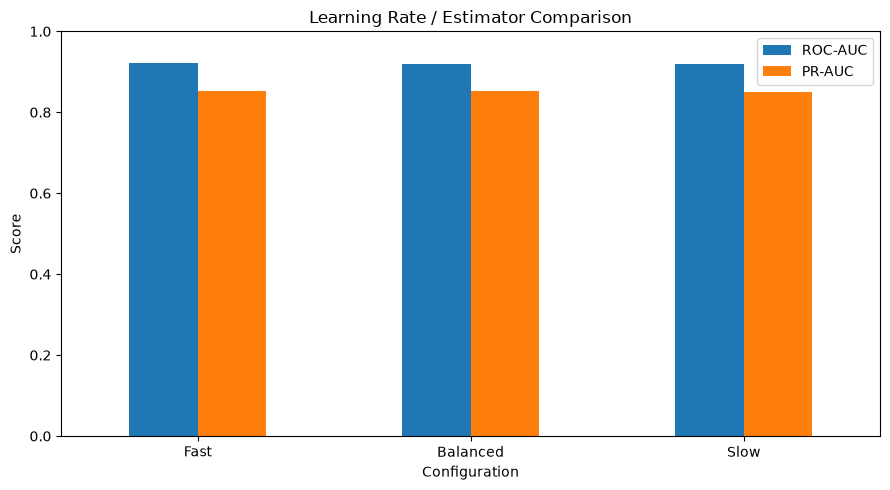

In [48]:
learning_rate_results.set_index(
    "Configuration"
)[["ROC-AUC", "PR-AUC"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Learning Rate / Estimator Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Compare all models so far

In [49]:
model_comparison = pd.DataFrame(
    {
        "Logistic Regression": logistic_metrics,
        "Linear SVM": linear_svm_metrics,
        "RBF SVM": rbf_svm_metrics,
        "Random Forest": rf_metrics,
        "Gradient Boosting": gb_metrics
    }
).T

model_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.7058,0.6271,0.4322,0.5118,0.7280,0.5845
Linear SVM,0.7067,0.6484,0.3879,0.4854,0.7192,0.6148
RBF SVM,0.8833,0.8830,0.7757,0.8259,0.9358,0.9013
Random Forest,0.8958,0.8855,0.8131,0.8477,0.9467,0.9137
Gradient Boosting,0.8633,0.8568,0.7407,0.7945,0.9189,0.8519


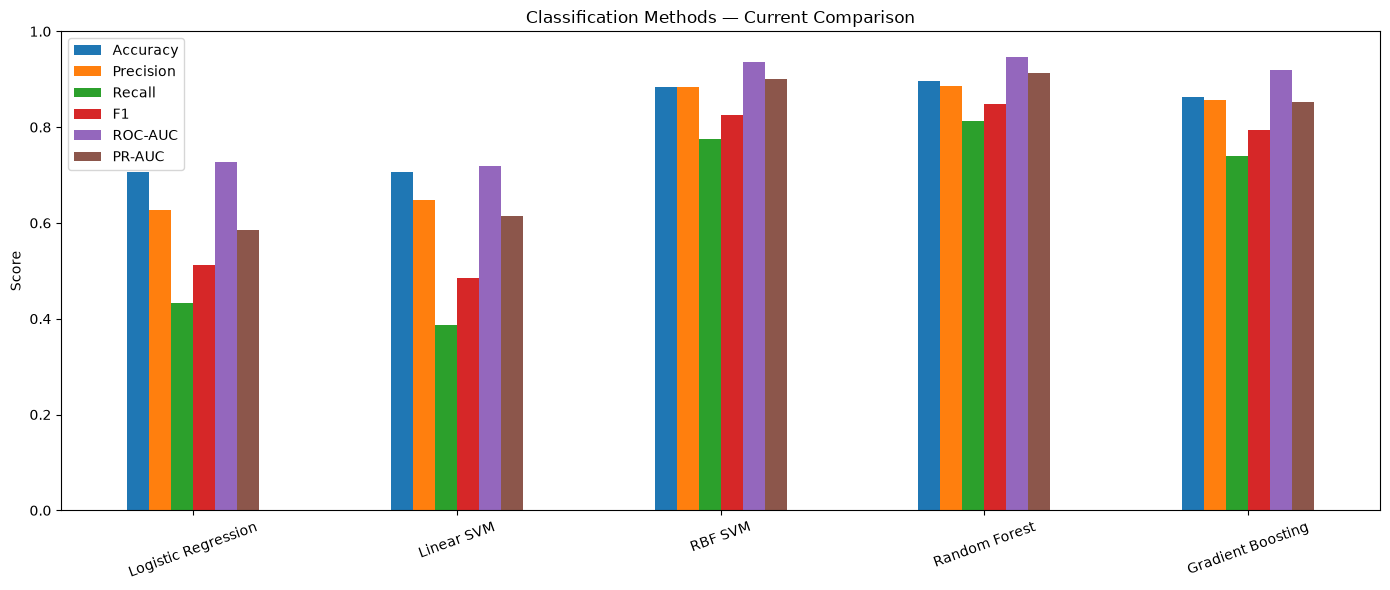

In [50]:
model_comparison[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Classification Methods — Current Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## ROC comparison

<Figure size 900x600 with 0 Axes>

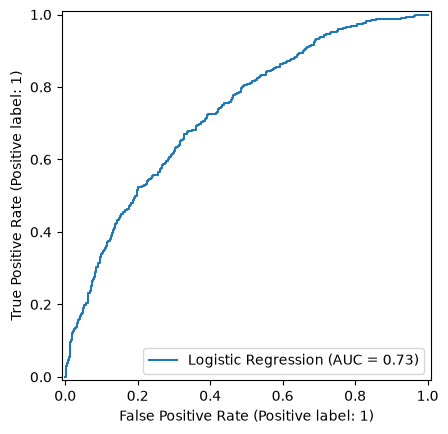

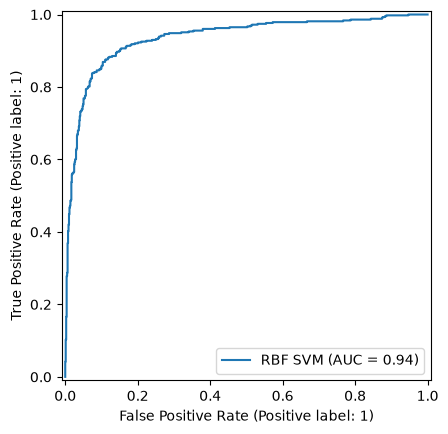

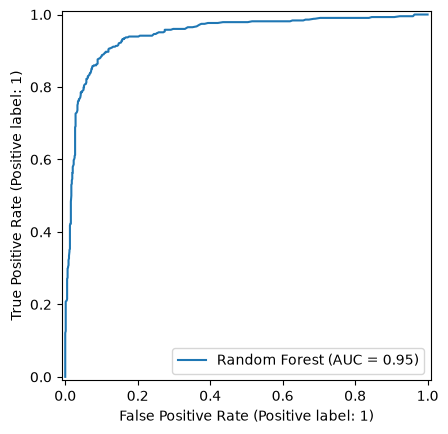

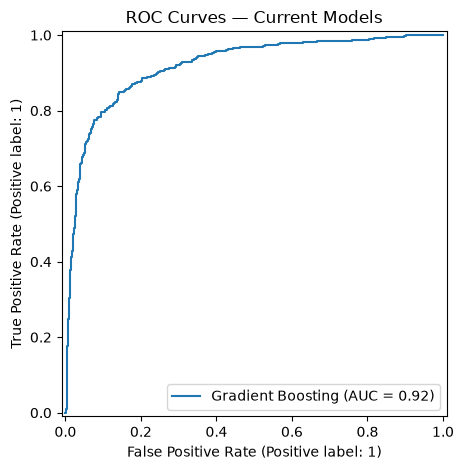

In [51]:
plt.figure(figsize=(9, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rbf_svm,
    name="RBF SVM"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_gb,
    name="Gradient Boosting"
)

plt.title("ROC Curves — Current Models")
plt.tight_layout()
plt.show()

## Precision–Recall comparison

<Figure size 900x600 with 0 Axes>

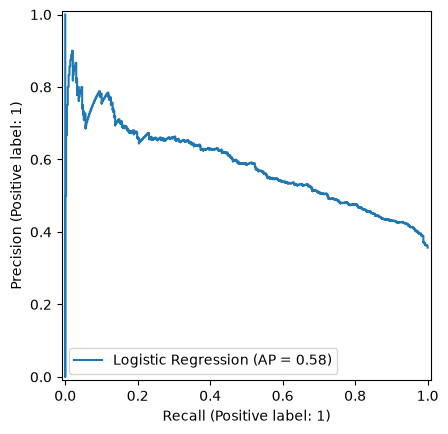

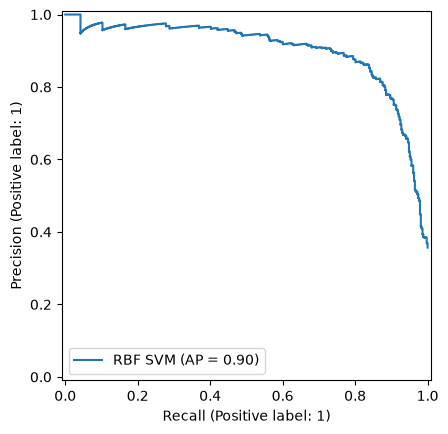

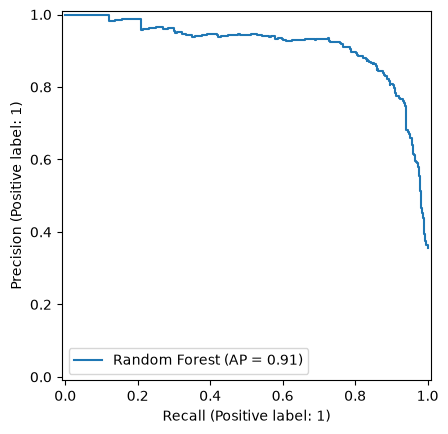

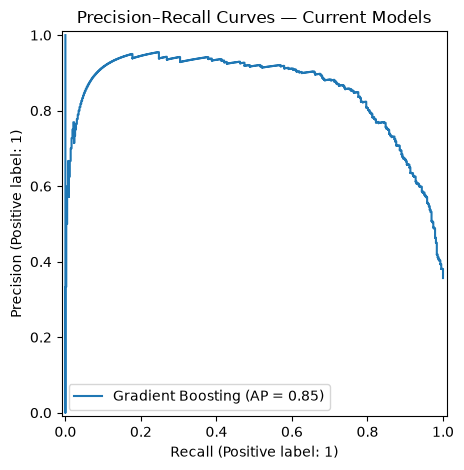

In [52]:
plt.figure(figsize=(9, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rbf_svm,
    name="RBF SVM"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_gb,
    name="Gradient Boosting"
)

plt.title("Precision–Recall Curves — Current Models")
plt.tight_layout()
plt.show()

### Gradient Boosting Takeaways

Gradient boosting differs fundamentally from Random Forest.

Random Forest primarily uses:

$$
\boxed{
\text{parallel independent trees}
+
\text{averaging}
}
$$

Gradient boosting uses:

$$
\boxed{
\text{sequential trees}
+
\text{error correction}
}
$$

This sequential optimization makes boosting extremely powerful for structured
data.

However, the basic `GradientBoostingClassifier` is not the only boosting
algorithm available.

Modern implementations introduce substantial improvements in:

- regularization
- parallelization
- tree construction
- missing-value handling
- categorical-feature handling
- computational efficiency
- scalability
- early stopping

Three particularly important modern gradient-boosting systems are:

$$
\boxed{
\text{XGBoost}
\qquad
\text{LightGBM}
\qquad
\text{CatBoost}
}
$$

We will examine these next.

## 8. XGBoost Classification

XGBoost (Extreme Gradient Boosting) is a highly optimized implementation of
gradient-boosted decision trees.

It extends the basic gradient boosting framework with stronger regularization,
efficient tree construction, shrinkage, subsampling, and second-order
optimization.

The model is represented as an additive ensemble:

$$
\hat{y}_i
=
\sum_{k=1}^{K} f_k(x_i),
$$

where each $f_k$ is a decision tree.

The objective can be expressed as

$$
\mathcal{L}
=
\sum_{i=1}^{n}
l(y_i,\hat{y}_i)
+
\sum_{k=1}^{K}\Omega(f_k),
$$

where:

- $l$ is the prediction loss
- $\Omega(f_k)$ is a regularization term controlling tree complexity.

A typical tree regularization term can be written as

$$
\Omega(f)
=
\gamma T
+
\frac{1}{2}\lambda\|w\|^2,
$$

where:

- $T$ is the number of leaves
- $\gamma$ penalizes additional leaves
- $\lambda$ controls leaf-weight regularization

This explicitly penalizes unnecessarily complex trees.

---

### Second-Order Optimization

XGBoost uses both first- and second-order information.

For a new tree, the loss can be approximated using a second-order Taylor
expansion:

$$
\mathcal{L}^{(t)}
\approx
\sum_i
\left[
g_i f_t(x_i)
+
\frac{1}{2}h_i f_t(x_i)^2
\right]
+
\Omega(f_t),
$$

where

$$
g_i
=
\frac{\partial l(y_i,\hat{y}_i^{(t-1)})}
{\partial \hat{y}_i^{(t-1)}}
$$

and

$$
h_i
=
\frac{\partial^2 l(y_i,\hat{y}_i^{(t-1)})}
{\partial (\hat{y}_i^{(t-1)})^2}.
$$

Using second-order information gives XGBoost a more informed optimization
procedure than using gradients alone.

---

### Important XGBoost Hyperparameters

Some important parameters include:

- `n_estimators`: maximum number of boosting rounds
- `learning_rate`: shrinkage applied to each tree
- `max_depth`: maximum tree depth
- `min_child_weight`: minimum amount of instance weight required in a child
- `subsample`: fraction of training observations sampled per tree
- `colsample_bytree`: fraction of features sampled per tree
- `reg_alpha`: L1 regularization
- `reg_lambda`: L2 regularization
- `gamma`: minimum loss reduction required for a split

The key idea is that XGBoost combines **expressive trees with explicit
regularization**.

In [54]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


## Train an XGBoost classifier

In [55]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost trained successfully.")

XGBoost trained successfully.


## Evaluate XGBoost

In [56]:
xgb_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb),
    "PR-AUC": average_precision_score(y_test, y_prob_xgb)
}

pd.Series(xgb_metrics).round(4)

Accuracy     0.8925
Precision    0.8883
Recall       0.7991
F1           0.8413
ROC-AUC      0.9401
PR-AUC       0.8938
dtype: float64

## Classification report

In [57]:
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Class 0", "Class 1"]
    )
)

              precision    recall  f1-score   support

     Class 0       0.89      0.94      0.92       772
     Class 1       0.89      0.80      0.84       428

    accuracy                           0.89      1200
   macro avg       0.89      0.87      0.88      1200
weighted avg       0.89      0.89      0.89      1200



## Confusion matrix

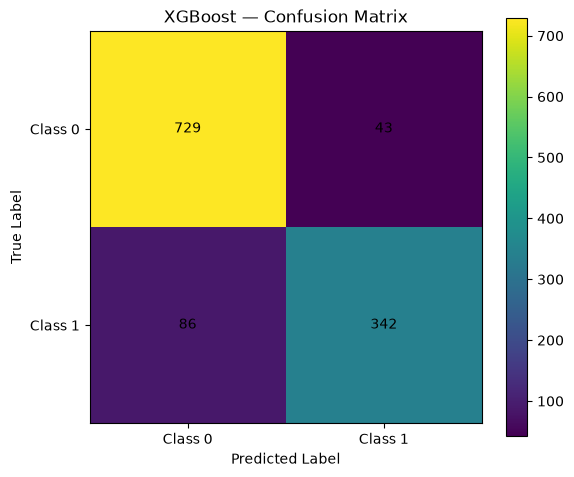

In [58]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
plt.imshow(cm_xgb)

plt.title("XGBoost — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_xgb[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

### XGBoost Feature Importance

XGBoost provides several ways to measure feature importance.

A simple approach is the gain-based importance, which measures how much a
feature contributes to improving the objective when it is used for splitting.

Feature importance can help us investigate what the model is using, but it
should not automatically be interpreted as causal importance.

For deeper interpretation, techniques such as permutation importance and SHAP
can be used later.

In [59]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

xgb_importance.head(12)

feature_6     0.100264
feature_7     0.093484
feature_3     0.089340
feature_17    0.077591
feature_8     0.069629
feature_15    0.068953
feature_16    0.062718
feature_1     0.060785
feature_10    0.060381
feature_20    0.055811
feature_4     0.055153
feature_13    0.052175
dtype: float32

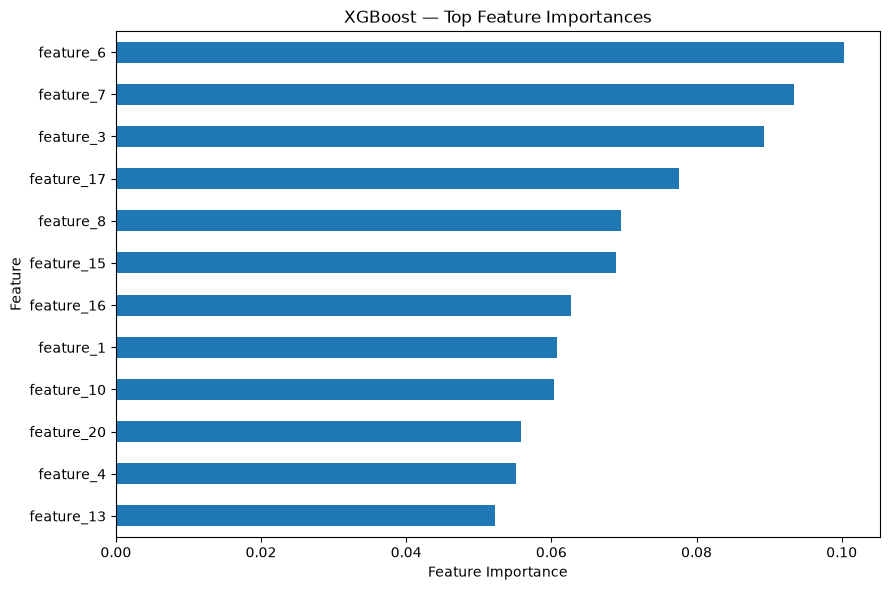

In [60]:
plt.figure(figsize=(9, 6))

xgb_importance.head(12).sort_values().plot(
    kind="barh"
)

plt.title("XGBoost — Top Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Training performance

In [63]:
X_train_sub, X_valid, y_train_sub, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print("Training subset:", X_train_sub.shape)
print("Validation set:", X_valid.shape)

Training subset: (3840, 20)
Validation set: (960, 20)


### Early Stopping

One practical advantage of modern boosting libraries is the ability to monitor
validation performance during training.

Suppose we allow a large maximum number of boosting rounds:

$$
M_{\max}\gg1.
$$

If validation performance stops improving, further trees may add complexity
without improving generalization.

Early stopping terminates training after a specified number of rounds without
meaningful improvement.

Conceptually:

$$
\text{Training}
\rightarrow
\text{Validation monitoring}
\rightarrow
\text{Best iteration}
\rightarrow
\text{Stop}.
$$

This makes the effective number of trees a data-dependent quantity rather than
something that must be chosen entirely in advance.

In [64]:
xgb_early = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_early.fit(
    X_train_sub,
    y_train_sub,
    eval_set=[
        (X_train_sub, y_train_sub),
        (X_valid, y_valid)
    ],
    verbose=False
)

print("Best iteration:", xgb_early.best_iteration)
print("Best validation score:", xgb_early.best_score)

Best iteration: 999
Best validation score: 0.29018156675865614


## Visualize training and validation loss

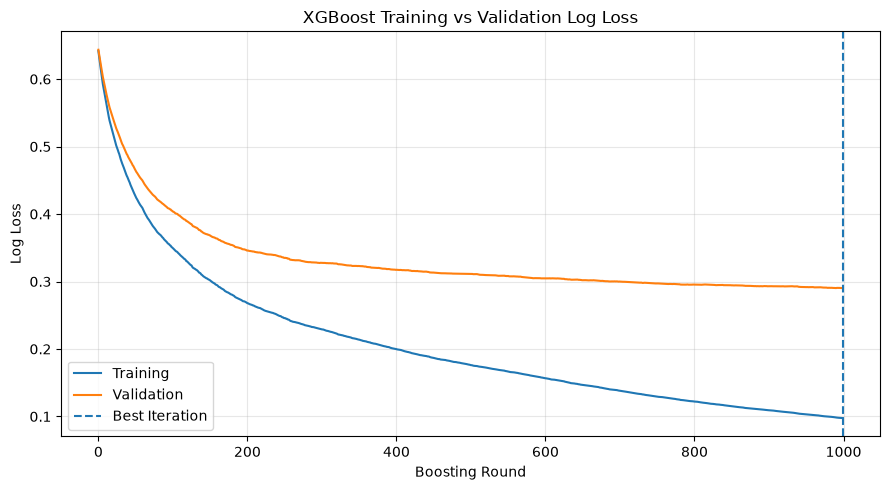

In [65]:
early_history = xgb_early.evals_result()

train_logloss = early_history["validation_0"]["logloss"]
valid_logloss = early_history["validation_1"]["logloss"]

plt.figure(figsize=(9, 5))

plt.plot(
    train_logloss,
    label="Training"
)

plt.plot(
    valid_logloss,
    label="Validation"
)

plt.axvline(
    x=xgb_early.best_iteration,
    linestyle="--",
    label="Best Iteration"
)

plt.title("XGBoost Training vs Validation Log Loss")
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Compare XGBoost with previous models

In [66]:
model_comparison = pd.DataFrame(
    {
        "Logistic Regression": logistic_metrics,
        "Linear SVM": linear_svm_metrics,
        "RBF SVM": rbf_svm_metrics,
        "Random Forest": rf_metrics,
        "Gradient Boosting": gb_metrics,
        "XGBoost": xgb_metrics
    }
).T

model_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.7058,0.6271,0.4322,0.5118,0.7280,0.5845
Linear SVM,0.7067,0.6484,0.3879,0.4854,0.7192,0.6148
RBF SVM,0.8833,0.8830,0.7757,0.8259,0.9358,0.9013
Random Forest,0.8958,0.8855,0.8131,0.8477,0.9467,0.9137
Gradient Boosting,0.8633,0.8568,0.7407,0.7945,0.9189,0.8519
XGBoost,0.8925,0.8883,0.7991,0.8413,0.9401,0.8938


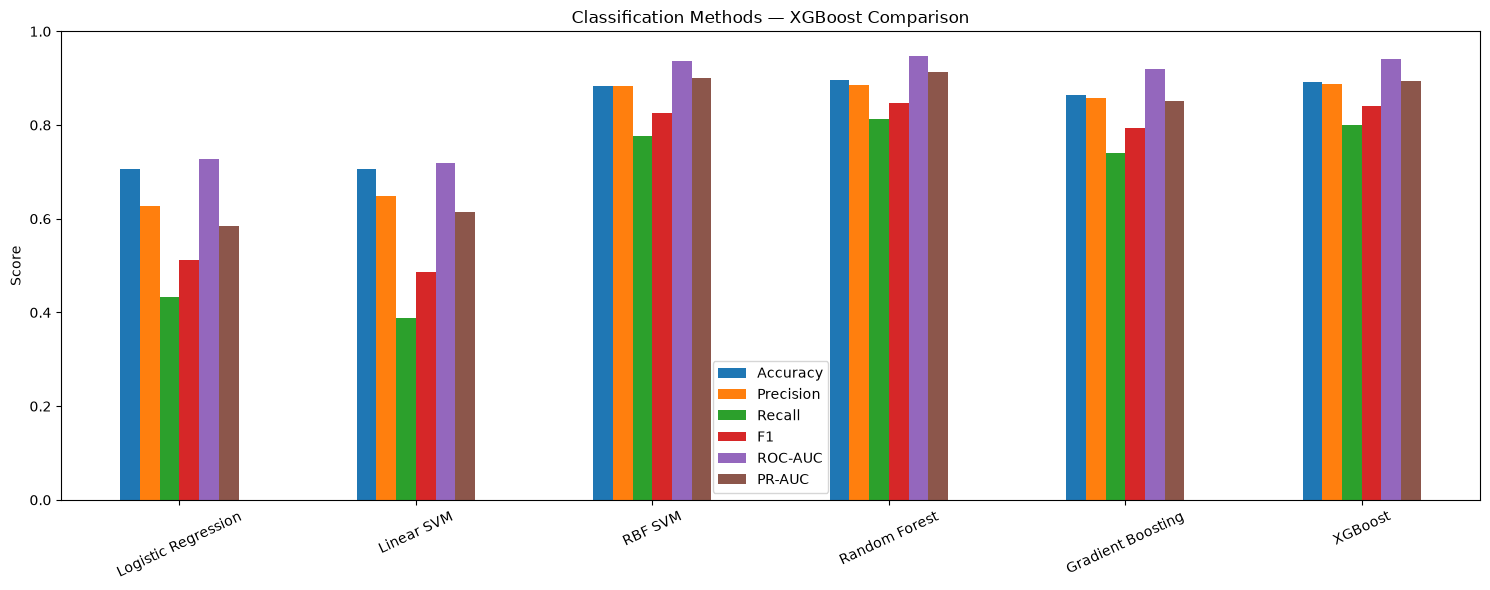

In [67]:
model_comparison[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(15, 6)
)

plt.title("Classification Methods — XGBoost Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

## ROC comparison

<Figure size 900x600 with 0 Axes>

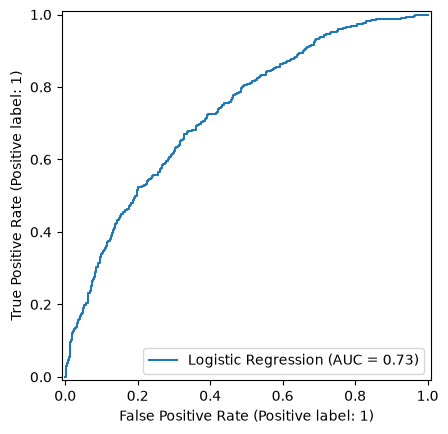

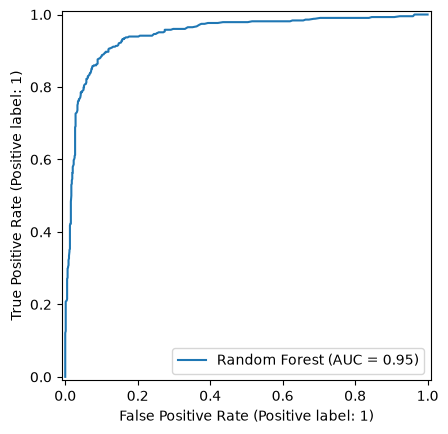

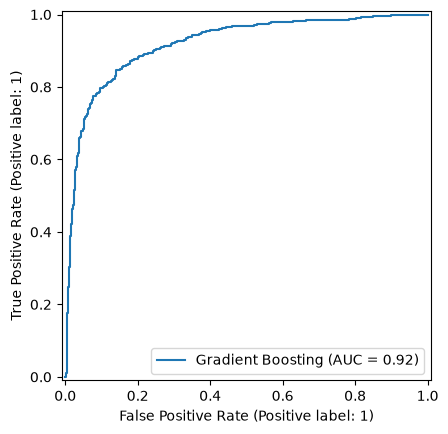

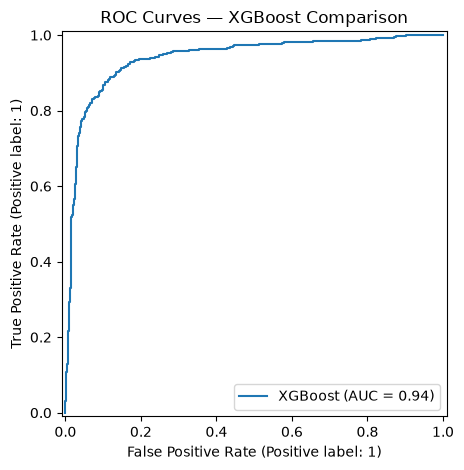

In [68]:
plt.figure(figsize=(9, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_gb,
    name="Gradient Boosting"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("ROC Curves — XGBoost Comparison")
plt.tight_layout()
plt.show()

## Precision–Recall comparison

<Figure size 900x600 with 0 Axes>

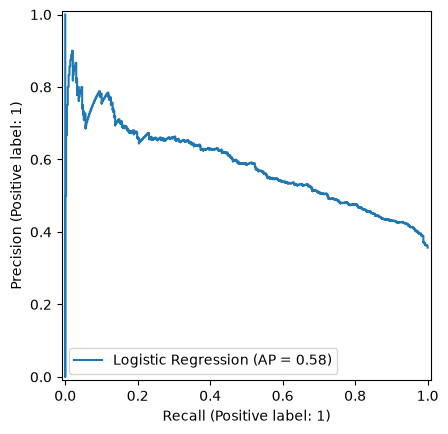

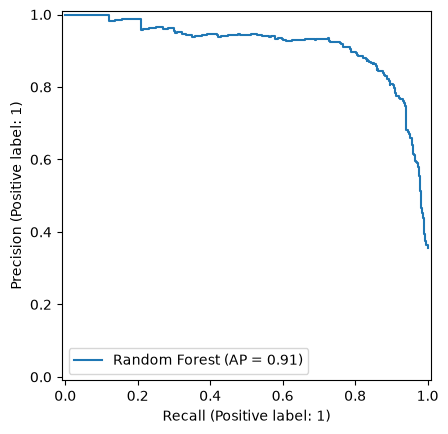

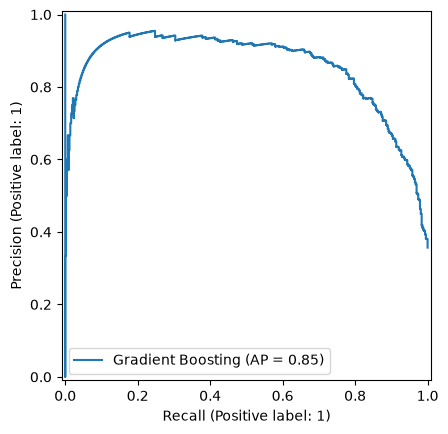

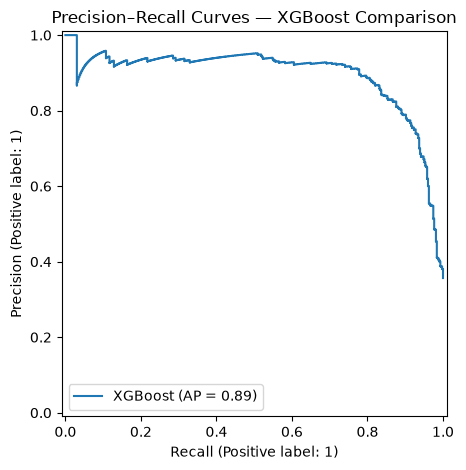

In [69]:
plt.figure(figsize=(9, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_gb,
    name="Gradient Boosting"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("Precision–Recall Curves — XGBoost Comparison")
plt.tight_layout()
plt.show()

### XGBoost Takeaways

XGBoost retains the fundamental idea of gradient boosting:

$$
F_m(x)
=
F_{m-1}(x)
+
\eta h_m(x).
$$

However, it adds several important mechanisms:

$$
\boxed{
\text{Gradient Boosting}
+
\text{Regularization}
+
\text{Second-Order Optimization}
+
\text{Efficient Tree Construction}
}
$$

This combination makes XGBoost particularly effective for structured/tabular
datasets.

However, XGBoost is not simply "better" than every other classifier.

Its performance depends on:

- dataset size
- feature representation
- noise
- class imbalance
- hyperparameter configuration
- computational constraints

Another modern implementation takes a different approach to improving the
efficiency of gradient-boosted trees.

The next method is **LightGBM**, which introduces highly efficient tree-growth
strategies and is particularly attractive for large tabular datasets.

$$
\boxed{\text{Next: LightGBM}}
$$

## 9. LightGBM Classification

LightGBM is a gradient-boosting framework based on decision trees and designed
for efficient training on large and high-dimensional datasets.

Like other gradient-boosting methods, LightGBM builds an additive model:

$$
F_M(x)
=
F_0(x)
+
\sum_{m=1}^{M}\eta h_m(x).
$$

The important difference is largely in how LightGBM constructs and grows its
trees.

---

### Histogram-Based Learning

Instead of evaluating every possible continuous feature value independently,
LightGBM can discretize continuous values into histogram bins.

Conceptually,

$$
x
\rightarrow
\text{histogram bins}
\rightarrow
\text{candidate splits}.
$$

This can substantially reduce the computational cost of finding useful splits,
especially for large datasets.

---

### Leaf-Wise Tree Growth

Traditional level-wise growth expands nodes by depth.

LightGBM instead uses a **leaf-wise** strategy: at each step it tends to split
the leaf that provides the largest reduction in the objective.

Conceptually:

$$
\text{Choose leaf}
=
\arg\max_{\ell}
\Delta L_{\ell}.
$$

This can produce deeper and more asymmetric trees.

The advantage is potentially faster reduction of the training objective.

The disadvantage is that leaf-wise growth can overfit, particularly on small
datasets.

Therefore, parameters such as `num_leaves`, `max_depth`, `min_child_samples`,
and regularization are important.

---

### Important LightGBM Parameters

Important parameters include:

- `n_estimators`: maximum number of boosting iterations
- `learning_rate`: contribution of each tree
- `num_leaves`: maximum number of leaves
- `max_depth`: maximum tree depth
- `min_child_samples`: minimum observations in a leaf
- `subsample`: fraction of observations used
- `colsample_bytree`: fraction of features used
- `reg_alpha`: L1 regularization
- `reg_lambda`: L2 regularization

The central trade-off is:

$$
\boxed{
\text{More expressive trees}
\leftrightarrow
\text{greater overfitting risk}
}
$$

In [70]:
import lightgbm as lgb

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.7.0


## Train LightGBM

In [71]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train,
    y_train
)

y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("LightGBM trained successfully.")

LightGBM trained successfully.


## Evaluate

In [72]:
lgb_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_lgb),
    "Precision": precision_score(y_test, y_pred_lgb),
    "Recall": recall_score(y_test, y_pred_lgb),
    "F1": f1_score(y_test, y_pred_lgb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_lgb),
    "PR-AUC": average_precision_score(y_test, y_prob_lgb)
}

pd.Series(lgb_metrics).round(4)

Accuracy     0.9025
Precision    0.8997
Recall       0.8178
F1           0.8568
ROC-AUC      0.9464
PR-AUC       0.9102
dtype: float64

## Classification report

In [73]:
print(
    classification_report(
        y_test,
        y_pred_lgb,
        target_names=["Class 0", "Class 1"]
    )
)

              precision    recall  f1-score   support

     Class 0       0.90      0.95      0.93       772
     Class 1       0.90      0.82      0.86       428

    accuracy                           0.90      1200
   macro avg       0.90      0.88      0.89      1200
weighted avg       0.90      0.90      0.90      1200



## Confusion matrix

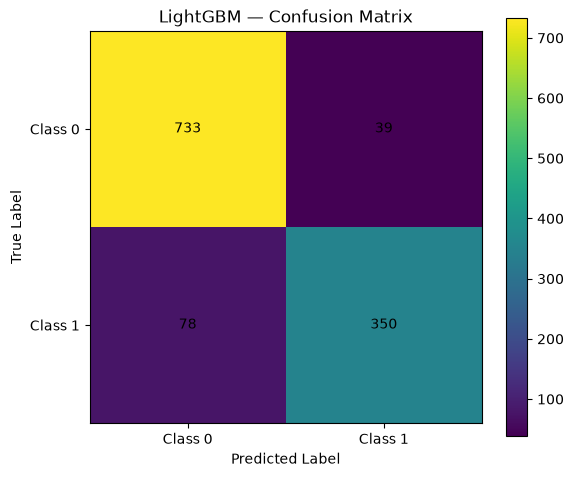

In [74]:
cm_lgb = confusion_matrix(y_test, y_pred_lgb)

plt.figure(figsize=(6, 5))
plt.imshow(cm_lgb)

plt.title("LightGBM — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_lgb[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

### LightGBM Feature Importance

LightGBM can provide feature-importance estimates based on quantities such as
split frequency or gain.

Gain-based importance measures how much a feature contributes to reducing the
training objective when it is used for splitting.

As with Random Forest and XGBoost, feature importance is a model diagnostic and
should not be interpreted as causal evidence.

In [75]:
lgb_importance = pd.Series(
    lgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

lgb_importance.head(12)

feature_17    1414
feature_10    1106
feature_3     1085
feature_6     1062
feature_15     957
feature_13     880
feature_8      856
feature_20     827
feature_16     820
feature_7      800
feature_4      662
feature_1      613
dtype: int32

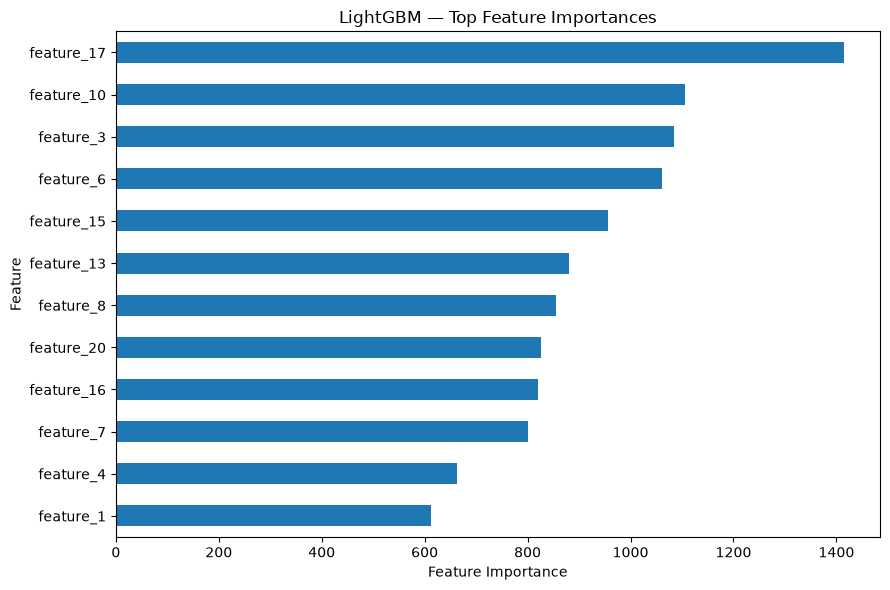

In [76]:
plt.figure(figsize=(9, 6))

lgb_importance.head(12).sort_values().plot(
    kind="barh"
)

plt.title("LightGBM — Top Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Early Stopping in LightGBM

As with XGBoost, we can monitor validation performance during boosting.

Suppose the maximum number of trees is

$$
M_{\max}=1000.
$$

There is no requirement that all 1000 trees should be used.

If validation performance stops improving, training can terminate early.

This gives us:

$$
M^*
=
\arg\min_M
L_{\text{validation}}(M),
$$

approximately subject to the early-stopping criterion.

This can reduce training time and help control overfitting.

## Create the validation split:

In [77]:
lgb_early = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lgb_early.fit(
    X_train_sub,
    y_train_sub,
    eval_set=[(X_valid, y_valid)],
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=False
        )
    ]
)

print("Best iteration:", lgb_early.best_iteration_)

Best iteration: 489


## Validation performance

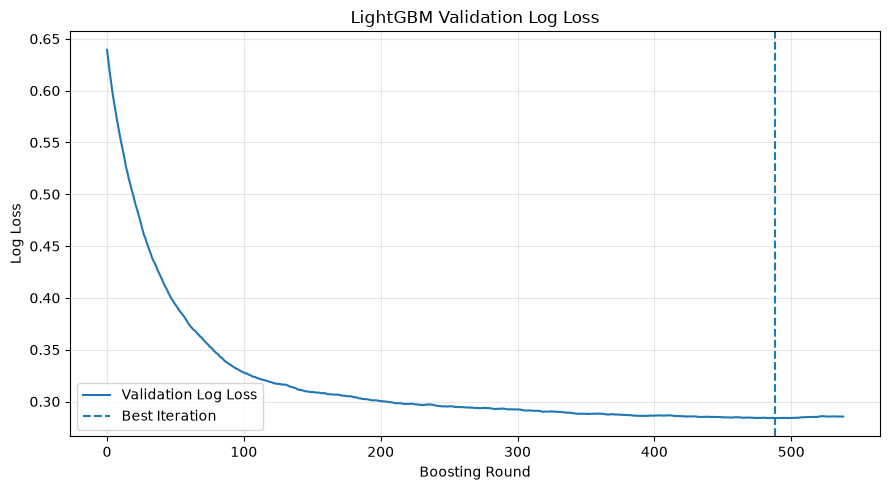

In [78]:
lgb_evaluation = lgb_early.evals_result_

validation_logloss = lgb_evaluation[
    "valid_0"
]["binary_logloss"]

plt.figure(figsize=(9, 5))

plt.plot(
    validation_logloss,
    label="Validation Log Loss"
)

plt.axvline(
    x=lgb_early.best_iteration_ - 1,
    linestyle="--",
    label="Best Iteration"
)

plt.title("LightGBM Validation Log Loss")
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Controlling Tree Complexity with `num_leaves`

For leaf-wise tree growth, `num_leaves` is one of the most important
complexity parameters.

Increasing the number of leaves allows the model to represent more complicated
functions:

$$
\text{num\_leaves}\uparrow
\quad\Longrightarrow\quad
\text{model capacity}\uparrow.
$$

However:

$$
\text{model capacity}\uparrow
\quad\Longrightarrow\quad
\text{potential overfitting}\uparrow.
$$

We can therefore examine how model complexity affects test performance.

In [79]:
leaf_values = [7, 15, 31, 63, 127]

leaf_results = []

for leaves in leaf_values:
    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=leaves,
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_test)[:, 1]

    leaf_results.append(
        {
            "num_leaves": leaves,
            "ROC-AUC": roc_auc_score(
                y_test,
                probabilities
            ),
            "PR-AUC": average_precision_score(
                y_test,
                probabilities
            )
        }
    )

leaf_results = pd.DataFrame(leaf_results)

leaf_results.round(4)

,num_leaves,ROC-AUC,PR-AUC
0,7,0.9223,0.8623
1,15,0.9357,0.8901
2,31,0.9443,0.9061
3,63,0.9492,0.9195
4,127,0.9504,0.9230


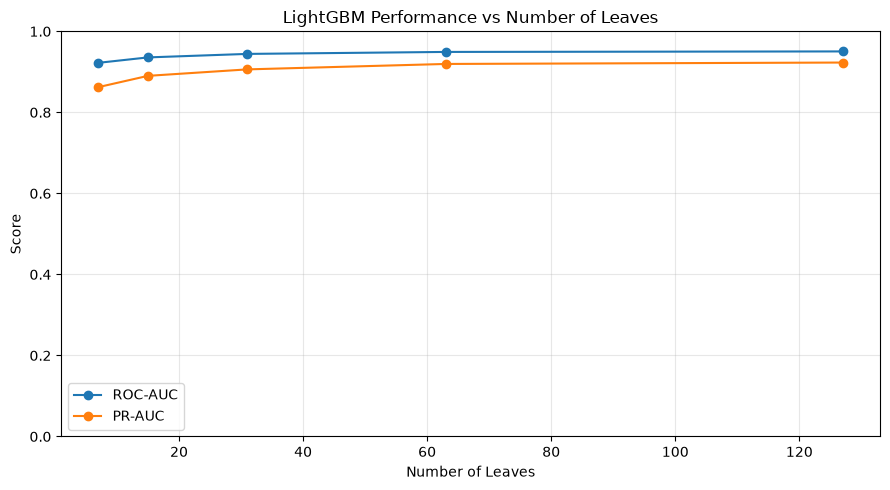

In [80]:
plt.figure(figsize=(9, 5))

plt.plot(
    leaf_results["num_leaves"],
    leaf_results["ROC-AUC"],
    marker="o",
    label="ROC-AUC"
)

plt.plot(
    leaf_results["num_leaves"],
    leaf_results["PR-AUC"],
    marker="o",
    label="PR-AUC"
)

plt.title("LightGBM Performance vs Number of Leaves")
plt.xlabel("Number of Leaves")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## XGBoost vs LightGBM

In [81]:
model_comparison = pd.DataFrame(
    {
        "Logistic Regression": logistic_metrics,
        "Linear SVM": linear_svm_metrics,
        "RBF SVM": rbf_svm_metrics,
        "Random Forest": rf_metrics,
        "Gradient Boosting": gb_metrics,
        "XGBoost": xgb_metrics,
        "LightGBM": lgb_metrics
    }
).T

model_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.7058,0.6271,0.4322,0.5118,0.7280,0.5845
Linear SVM,0.7067,0.6484,0.3879,0.4854,0.7192,0.6148
RBF SVM,0.8833,0.8830,0.7757,0.8259,0.9358,0.9013
Random Forest,0.8958,0.8855,0.8131,0.8477,0.9467,0.9137
Gradient Boosting,0.8633,0.8568,0.7407,0.7945,0.9189,0.8519
XGBoost,0.8925,0.8883,0.7991,0.8413,0.9401,0.8938
LightGBM,0.9025,0.8997,0.8178,0.8568,0.9464,0.9102


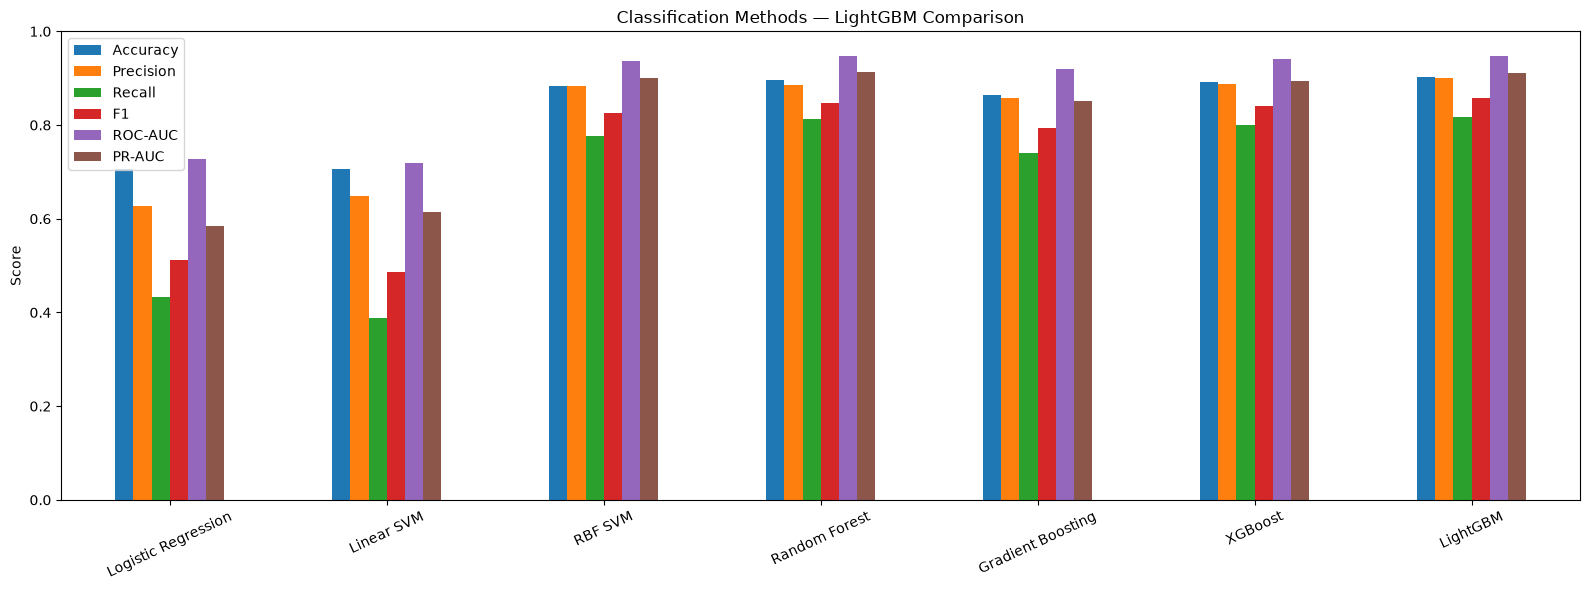

In [82]:
model_comparison[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(16, 6)
)

plt.title("Classification Methods — LightGBM Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

## ROC comparison

<Figure size 900x600 with 0 Axes>

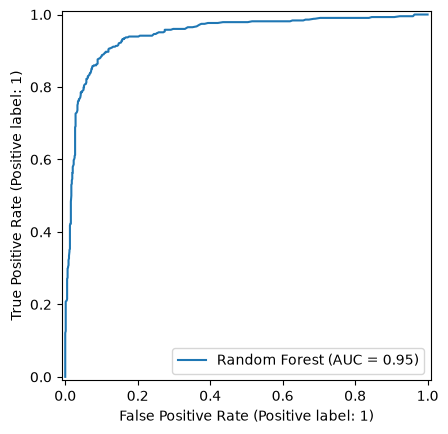

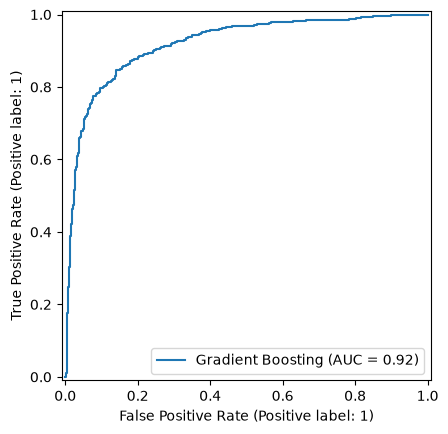

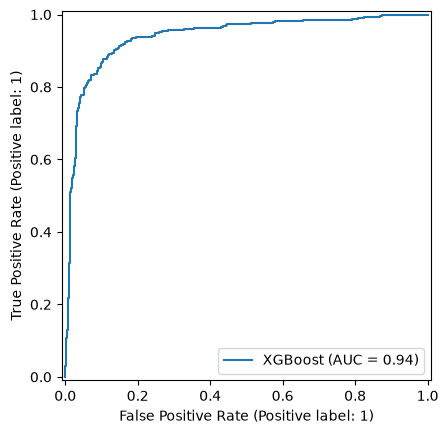

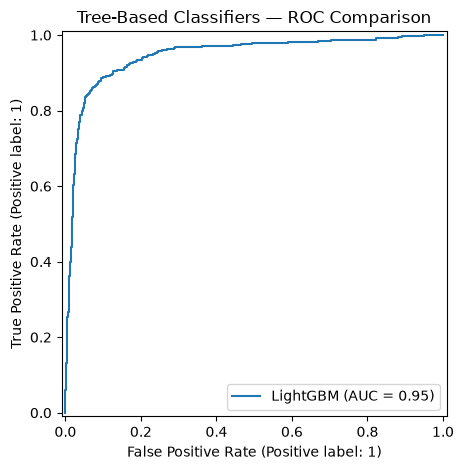

In [83]:
plt.figure(figsize=(9, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_gb,
    name="Gradient Boosting"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lgb,
    name="LightGBM"
)

plt.title("Tree-Based Classifiers — ROC Comparison")
plt.tight_layout()
plt.show()

## Precision–Recall comparison

<Figure size 900x600 with 0 Axes>

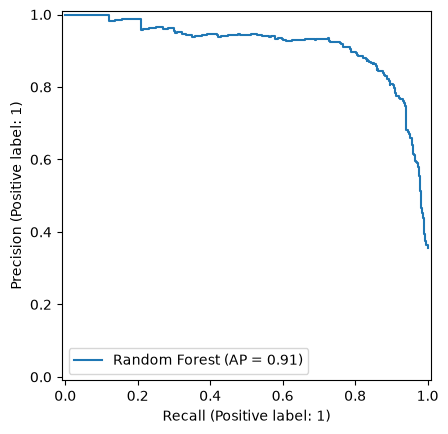

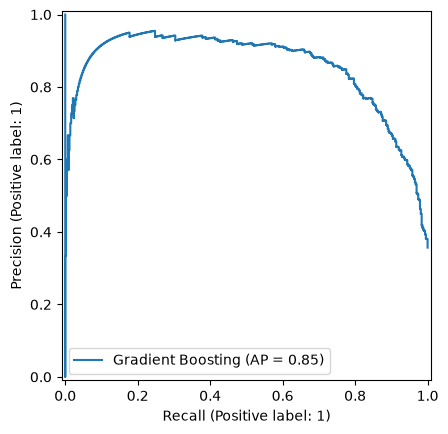

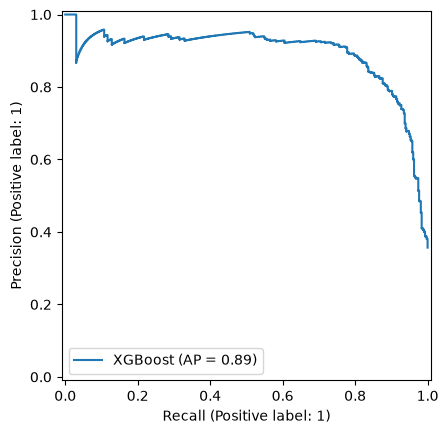

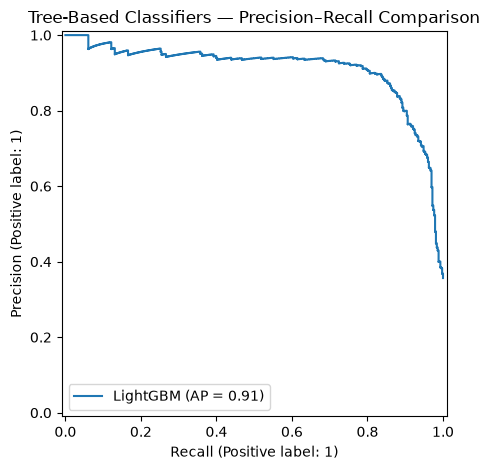

In [84]:
plt.figure(figsize=(9, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_gb,
    name="Gradient Boosting"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_lgb,
    name="LightGBM"
)

plt.title("Tree-Based Classifiers — Precision–Recall Comparison")
plt.tight_layout()
plt.show()

### LightGBM Takeaways

LightGBM and XGBoost both implement gradient-boosted decision trees, but their
engineering and tree-construction strategies differ.

A simplified comparison is:

| Characteristic | XGBoost | LightGBM |
|---|---|---|
| Gradient boosting | Yes | Yes |
| Histogram-based learning | Yes | Yes |
| Regularization | Strong | Strong |
| Tree growth | Primarily depth-wise | Leaf-wise |
| Large datasets | Very capable | Particularly attractive |
| Categorical support | Requires appropriate handling | Native categorical support available |
| Main complexity control | Depth and regularization | Leaves, depth, and regularization |

The important lesson is not that one implementation is universally superior.

Instead:

$$
\boxed{
\text{Algorithm choice}
=
\text{data}
+
\text{scale}
+
\text{features}
+
\text{constraints}
+
\text{validation}
}
$$

There is still one major modern gradient-boosting system to examine:

$$
\boxed{\text{CatBoost}}
$$

CatBoost is especially interesting because it was designed with categorical
features and ordered boosting techniques in mind.

## 10. CatBoost Classification

CatBoost is a gradient-boosting algorithm designed to work particularly well
with datasets containing categorical features.

Traditional tree-based pipelines often require categorical variables to be
converted into numerical representations before training.

For example:

$$
\text{City}
\rightarrow
\text{one-hot encoding}
$$

or

$$
\text{Category}
\rightarrow
\text{integer encoding}.
$$

Naive integer encoding can create an artificial ordering:

$$
A\rightarrow0,\qquad B\rightarrow1,\qquad C\rightarrow2.
$$

The numerical distance between these values has no inherent meaning.

CatBoost instead provides native categorical-feature processing.

---

### Ordered Target Statistics

A central idea in CatBoost is the use of ordered statistics to reduce target
leakage during categorical encoding.

For an observation at position $i$, the encoding can be constructed using
information from earlier observations rather than using the target of the
observation itself.

Conceptually:

$$
\text{Encoding}(x_i)
=
f(x_1,\ldots,x_{i-1},
y_1,\ldots,y_{i-1}).
$$

This ordering helps reduce a form of target leakage that can occur with naive
target encoding.

---

### Ordered Boosting

CatBoost also introduces ordered boosting strategies intended to reduce
prediction shift and improve generalization.

The broader idea is:

$$
\boxed{
\text{categorical handling}
+
\text{ordered statistics}
+
\text{gradient boosting}
}
$$

This makes CatBoost particularly attractive for structured datasets containing
many categorical variables.

It can also perform well on purely numerical datasets, but its categorical
handling is one of its most distinctive practical advantages.

In [85]:
import catboost

from catboost import CatBoostClassifier

print("CatBoost version:", catboost.__version__)

CatBoost version: 1.2.10


### A Mixed Numerical/Categorical Dataset

Our previous dataset contains only numerical features.

To demonstrate native categorical processing, we will create a separate
classification dataset containing:

- numerical variables
- categorical variables
- nonlinear relationships
- class imbalance

The categorical variables will intentionally remain as strings.

This allows CatBoost to process them directly.

In [86]:
rng = np.random.default_rng(RANDOM_STATE)

n_samples = 6000

cat_data = pd.DataFrame(
    {
        "age": rng.integers(18, 70, n_samples),
        "income": rng.lognormal(
            mean=10.5,
            sigma=0.5,
            size=n_samples
        ),
        "credit_score": rng.normal(
            loc=680,
            scale=55,
            size=n_samples
        ),
        "city": rng.choice(
            ["Kolkata", "Delhi", "Mumbai", "Bengaluru", "Chennai"],
            size=n_samples,
            p=[0.25, 0.20, 0.20, 0.20, 0.15]
        ),
        "employment": rng.choice(
            ["Student", "Salaried", "Self-employed", "Unemployed"],
            size=n_samples,
            p=[0.15, 0.55, 0.20, 0.10]
        ),
        "account_type": rng.choice(
            ["Basic", "Premium", "Business"],
            size=n_samples,
            p=[0.55, 0.30, 0.15]
        )
    }
)

logit = (
    -4.0
    + 0.025 * (cat_data["age"] - 35)
    + 0.004 * (cat_data["credit_score"] - 650)
    + 0.000002 * (cat_data["income"] - 40000)
    + 0.8 * (cat_data["employment"] == "Self-employed")
    + 0.6 * (cat_data["account_type"] == "Premium")
    + 0.9 * (cat_data["account_type"] == "Business")
    + 0.5 * (cat_data["city"] == "Mumbai")
)

probability = 1 / (1 + np.exp(-logit))

cat_target = rng.binomial(
    1,
    probability
)

cat_data["target"] = cat_target

cat_data.head()

,age,income,credit_score,city,employment,account_type,target
0,22,61586.181189,661.917491,Delhi,Self-employed,Basic,0
1,58,24894.204150,768.756297,Bengaluru,Salaried,Basic,0
2,52,9230.176400,737.985430,Mumbai,Unemployed,Basic,1
3,40,15010.707383,589.753756,Delhi,Salaried,Basic,0
4,40,73925.528146,754.324090,Mumbai,Unemployed,Premium,0


In [87]:
cat_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           6000 non-null   int64  
 1   income        6000 non-null   float64
 2   credit_score  6000 non-null   float64
 3   city          6000 non-null   str    
 4   employment    6000 non-null   str    
 5   account_type  6000 non-null   str    
 6   target        6000 non-null   int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 328.3 KB


In [88]:
cat_data["target"].value_counts(normalize=True).sort_index()

target
0    0.946833
1    0.053167
Name: proportion, dtype: float64

In [89]:
for column in ["city", "employment", "account_type"]:
    print(f"\n{column}")
    print(cat_data[column].value_counts())


city
city
Kolkata      1482
Bengaluru    1227
Mumbai       1192
Delhi        1157
Chennai       942
Name: count, dtype: int64

employment
employment
Salaried         3271
Self-employed    1276
Student           886
Unemployed        567
Name: count, dtype: int64

account_type
account_type
Basic       3292
Premium     1812
Business     896
Name: count, dtype: int64


### Train/test split

In [90]:
X_cat = cat_data.drop(columns="target")
y_cat = cat_data["target"]

X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(
    X_cat,
    y_cat,
    test_size=0.20,
    stratify=y_cat,
    random_state=RANDOM_STATE
)

categorical_features = [
    "city",
    "employment",
    "account_type"
]

categorical_indices = [
    X_cat_train.columns.get_loc(column)
    for column in categorical_features
]

print("Categorical feature indices:", categorical_indices)

Categorical feature indices: [3, 4, 5]


### Train CatBoost

In [91]:
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    thread_count=-1
)

catboost_model.fit(
    X_cat_train,
    y_cat_train,
    cat_features=categorical_indices
)

y_pred_catboost = catboost_model.predict(X_cat_test).astype(int).ravel()
y_prob_catboost = catboost_model.predict_proba(X_cat_test)[:, 1]

print("CatBoost trained successfully.")

CatBoost trained successfully.


## Evaluate CatBoost

In [92]:
catboost_metrics = {
    "Accuracy": accuracy_score(
        y_cat_test,
        y_pred_catboost
    ),
    "Precision": precision_score(
        y_cat_test,
        y_pred_catboost
    ),
    "Recall": recall_score(
        y_cat_test,
        y_pred_catboost
    ),
    "F1": f1_score(
        y_cat_test,
        y_pred_catboost
    ),
    "ROC-AUC": roc_auc_score(
        y_cat_test,
        y_prob_catboost
    ),
    "PR-AUC": average_precision_score(
        y_cat_test,
        y_prob_catboost
    )
}

pd.Series(catboost_metrics).round(4)

Accuracy     0.9458
Precision    0.0000
Recall       0.0000
F1           0.0000
ROC-AUC      0.6787
PR-AUC       0.1165
dtype: float64

## Classification report

In [93]:
print(
    classification_report(
        y_cat_test,
        y_pred_catboost,
        target_names=["Class 0", "Class 1"]
    )
)

              precision    recall  f1-score   support

     Class 0       0.95      1.00      0.97      1136
     Class 1       0.00      0.00      0.00        64

    accuracy                           0.95      1200
   macro avg       0.47      0.50      0.49      1200
weighted avg       0.90      0.95      0.92      1200



## Confusion matrix

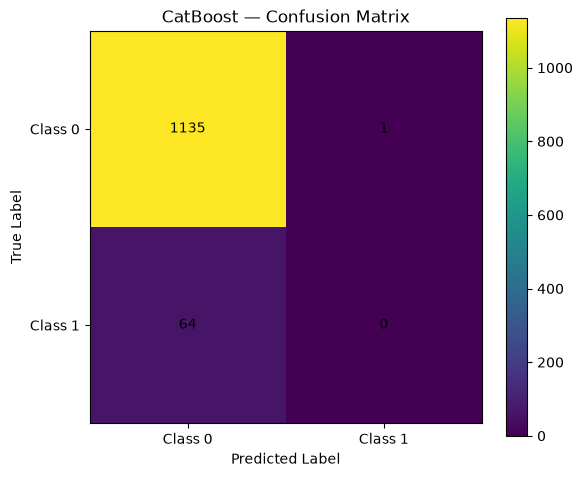

In [94]:
cm_catboost = confusion_matrix(
    y_cat_test,
    y_pred_catboost
)

plt.figure(figsize=(6, 5))
plt.imshow(cm_catboost)

plt.title("CatBoost — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_catboost[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## Feature importance

In [95]:
catboost_importance = pd.Series(
    catboost_model.get_feature_importance(),
    index=X_cat_train.columns
).sort_values(ascending=False)

catboost_importance

credit_score    19.975324
income          19.514132
age             18.329591
employment      14.895400
city            14.325145
account_type    12.960408
dtype: float64

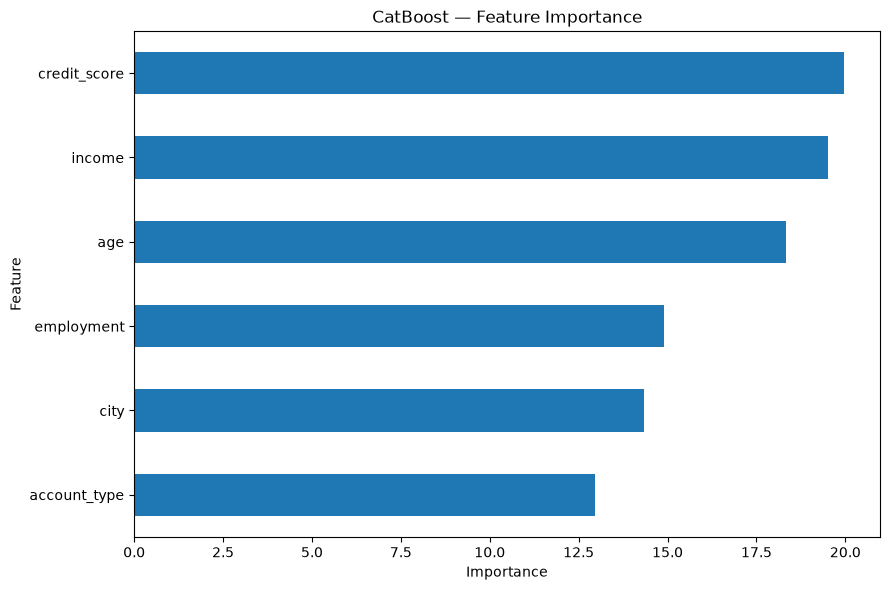

In [96]:
plt.figure(figsize=(9, 6))

catboost_importance.sort_values().plot(
    kind="barh"
)

plt.title("CatBoost — Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Training curve

In [107]:
catboost_evals = catboost_model.get_evals_result()

print("Available evaluation sets:")
print(catboost_evals.keys())

for eval_set, metrics in catboost_evals.items():
    print(f"\n{eval_set}:")
    print(list(metrics.keys()))

Available evaluation sets:
dict_keys(['learn'])

learn:
['Logloss']


In [108]:
learn_metrics = catboost_evals["learn"]

print("Available training metrics:", list(learn_metrics.keys()))

Available training metrics: ['Logloss']


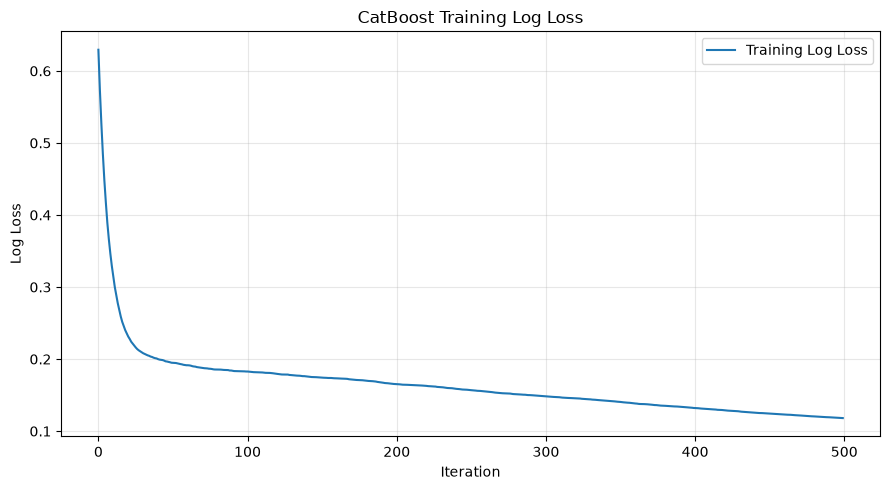

In [109]:
training_logloss = learn_metrics["Logloss"]

plt.figure(figsize=(9, 5))

plt.plot(
    training_logloss,
    label="Training Log Loss"
)

plt.title("CatBoost Training Log Loss")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## CatBoost validation and early stopping

In [99]:
catboost_early = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    thread_count=-1,
    early_stopping_rounds=50
)

catboost_early.fit(
    X_cat_train,
    y_cat_train,
    cat_features=categorical_indices,
    eval_set=(X_cat_test, y_cat_test),
    verbose=False
)

print("Best iteration:", catboost_early.get_best_iteration())
print("Best validation score:", catboost_early.get_best_score())

Best iteration: 158
Best validation score: {'learn': {'Logloss': 0.17837551804310478}, 'validation': {'Logloss': 0.1927719086570863, 'AUC': 0.7207443882042254}}


## ROC and Precision–Recall

<Figure size 800x600 with 0 Axes>

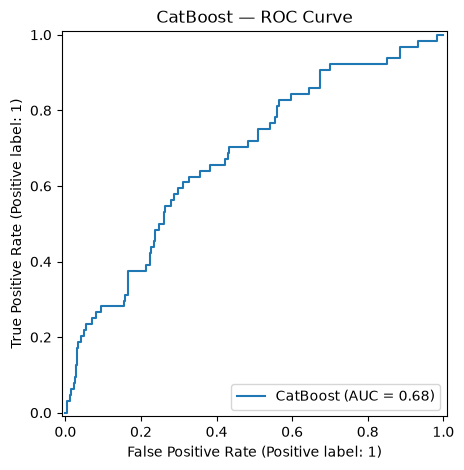

In [100]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_cat_test,
    y_prob_catboost,
    name="CatBoost"
)

plt.title("CatBoost — ROC Curve")
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

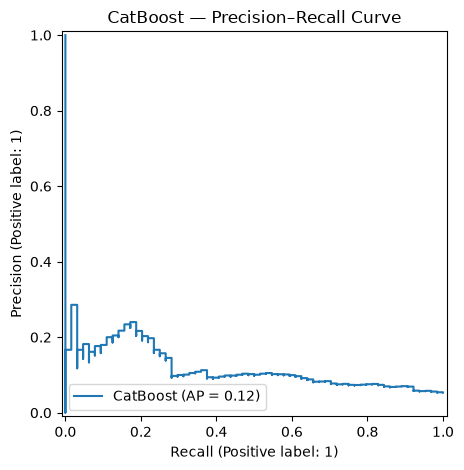

In [101]:
plt.figure(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_cat_test,
    y_prob_catboost,
    name="CatBoost"
)

plt.title("CatBoost — Precision–Recall Curve")
plt.tight_layout()
plt.show()

### Why CatBoost Is Different

Consider a categorical feature such as

$$
\text{employment}
\in
\{
\text{Student},
\text{Salaried},
\text{Self-employed},
\text{Unemployed}
\}.
$$

A naive integer encoding might produce

$$
\text{Student}=0,
\quad
\text{Salaried}=1,
\quad
\text{Self-employed}=2,
\quad
\text{Unemployed}=3.
$$

This representation incorrectly suggests an ordering and numerical distance.

One-hot encoding avoids that problem, but can substantially increase the number
of columns when categorical cardinality is large.

CatBoost provides native mechanisms for categorical variables and therefore
reduces the need for a large manual preprocessing pipeline.

This is particularly useful for datasets such as:

- customer data
- transaction data
- recommendation systems
- marketing data
- tabular business data
- datasets containing many categorical identifiers

The practical lesson is:

$$
\boxed{
\text{Feature representation can be as important as model selection}
}
$$

## 10.16 XGBoost vs LightGBM vs CatBoost

All three methods belong to the gradient-boosting family, but their design
priorities differ.

| Method | Particularly Useful For | Distinguishing Characteristic |
|---|---|---|
| XGBoost | General-purpose tabular ML | Strong regularization and mature optimization |
| LightGBM | Large-scale tabular ML | Efficient histogram learning and leaf-wise growth |
| CatBoost | Categorical-heavy tabular ML | Native categorical processing and ordered methods |

There is no universally best boosting library.

A useful practical strategy is:

$$
\text{Baseline}
\rightarrow
\text{Boosting candidates}
\rightarrow
\text{Validation}
\rightarrow
\text{Error analysis}
\rightarrow
\text{Final selection}.
$$

Compare the modern boosting models

In [102]:
boosting_comparison = pd.DataFrame(
    {
        "Gradient Boosting": gb_metrics,
        "XGBoost": xgb_metrics,
        "LightGBM": lgb_metrics
    }
).T

boosting_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Gradient Boosting,0.8633,0.8568,0.7407,0.7945,0.9189,0.8519
XGBoost,0.8925,0.8883,0.7991,0.8413,0.9401,0.8938
LightGBM,0.9025,0.8997,0.8178,0.8568,0.9464,0.9102


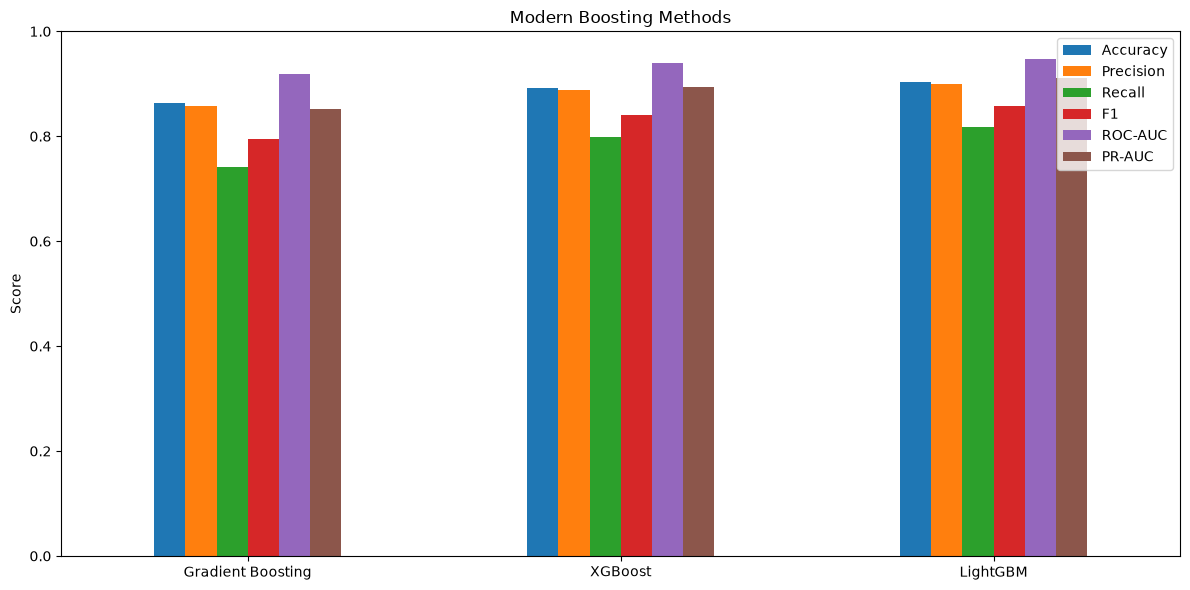

In [103]:
boosting_comparison[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Modern Boosting Methods")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 10.17 Boosting Takeaways

We have now examined four important boosting approaches:

$$
\text{Gradient Boosting}
\rightarrow
\text{XGBoost}
\rightarrow
\text{LightGBM}
\rightarrow
\text{CatBoost}.
$$

They share the additive boosting idea:

$$
F_M(x)
=
F_0(x)
+
\sum_{m=1}^{M}\eta h_m(x),
$$

but differ in optimization, tree construction, regularization, and feature
handling.

A useful mental model is:

- **Gradient Boosting:** understand the fundamental boosting algorithm.
- **XGBoost:** understand regularized and optimized boosting.
- **LightGBM:** understand scalable and efficient boosting.
- **CatBoost:** understand native categorical processing and ordered methods.

For many structured/tabular problems, these algorithms are among the strongest
classical machine-learning approaches available.

However, classification is not limited to tabular tree models.

When the input contains complex representations such as images, audio, text,
or learned embeddings, neural networks can provide much greater representational
capacity.

The next section therefore moves to:

$$
\boxed{\text{11. Neural Classification}}
$$

## 11. Neural Classification

Neural networks provide a flexible function-approximation framework for
classification.

A simple feed-forward neural network transforms an input through a sequence of
layers:

$$
h^{(1)} = \phi(W^{(1)}x+b^{(1)})
$$

$$
h^{(2)} = \phi(W^{(2)}h^{(1)}+b^{(2)})
$$

and finally produces a classification output.

For binary classification, the final logit can be written as

$$
z = w^\top h+b.
$$

The predicted probability is

$$
\hat{p}
=
\sigma(z)
=
\frac{1}{1+e^{-z}}.
$$

The binary cross-entropy loss is

$$
\mathcal{L}
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right].
$$

Unlike logistic regression, hidden layers allow the network to learn nonlinear
representations.

Conceptually:

$$
x
\rightarrow
\text{representation}
\rightarrow
\text{decision function}
\rightarrow
P(Y=1\mid x).
$$

For tabular datasets, neural networks are not automatically superior to
gradient-boosted trees. Their main advantage becomes more apparent when the
input itself contains complex structure or when representation learning is
important.

In [110]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

PyTorch version: 2.14.0+cpu
Device: cpu


## Prepare the numerical dataset

In [111]:
scaler_nn = StandardScaler()

X_train_nn = scaler_nn.fit_transform(X_train)
X_test_nn = scaler_nn.transform(X_test)

X_train_tensor = torch.tensor(
    X_train_nn,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.float32
).reshape(-1, 1)

X_test_tensor = torch.tensor(
    X_test_nn,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.to_numpy(),
    dtype=torch.float32
).reshape(-1, 1)

print("Training tensor:", X_train_tensor.shape)
print("Test tensor:", X_test_tensor.shape)

Training tensor: torch.Size([4800, 20])
Test tensor: torch.Size([1200, 20])


## Create DataLoader

In [112]:
batch_size = 128

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

### Feed-Forward Neural Network

We will use a small multilayer perceptron (MLP).

The architecture is:

$$
20
\rightarrow
64
\rightarrow
32
\rightarrow
1.
$$

The hidden layers use the ReLU activation:

$$
\operatorname{ReLU}(x)
=
\max(0,x).
$$

The final layer produces a single logit rather than directly applying a sigmoid.

This allows us to use `BCEWithLogitsLoss`, which combines the sigmoid operation
and binary cross-entropy in a numerically stable implementation.

In [113]:
class NeuralClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [114]:
torch.manual_seed(RANDOM_STATE)

neural_model = NeuralClassifier(
    input_dim=X_train_tensor.shape[1]
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    neural_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print(neural_model)

NeuralClassifier(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


### Training

The network parameters are optimized using Adam.

At each iteration:

$$
\theta
\rightarrow
\theta-\eta\nabla_\theta\mathcal{L}.
$$

The model repeatedly processes mini-batches of training observations.

We will also track test performance after each epoch so that we can visualize
the learning process.

For a rigorous machine-learning workflow, a separate validation set should be
used for model selection and early stopping. The test set here is used only as
a learning visualization; the final model comparison later in the notebook
should rely on the untouched test set only once.

In [115]:
n_epochs = 50

train_losses = []
test_losses = []

for epoch in range(n_epochs):

    neural_model.train()

    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = neural_model(X_batch)

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()
        optimizer.step()

        epoch_loss += (
            loss.item()
            * X_batch.size(0)
        )

    epoch_loss /= len(train_loader.dataset)

    neural_model.eval()

    with torch.no_grad():

        test_logits = neural_model(
            X_test_tensor.to(device)
        )

        test_loss = criterion(
            test_logits,
            y_test_tensor.to(device)
        ).item()

    train_losses.append(epoch_loss)
    test_losses.append(test_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:02d}/{n_epochs} "
            f"| Train Loss: {epoch_loss:.4f} "
            f"| Test Loss: {test_loss:.4f}"
        )

Epoch 10/50 | Train Loss: 0.3562 | Test Loss: 0.3460
Epoch 20/50 | Train Loss: 0.2948 | Test Loss: 0.3021
Epoch 30/50 | Train Loss: 0.2600 | Test Loss: 0.2768
Epoch 40/50 | Train Loss: 0.2359 | Test Loss: 0.2528
Epoch 50/50 | Train Loss: 0.2181 | Test Loss: 0.2403


Learning curves

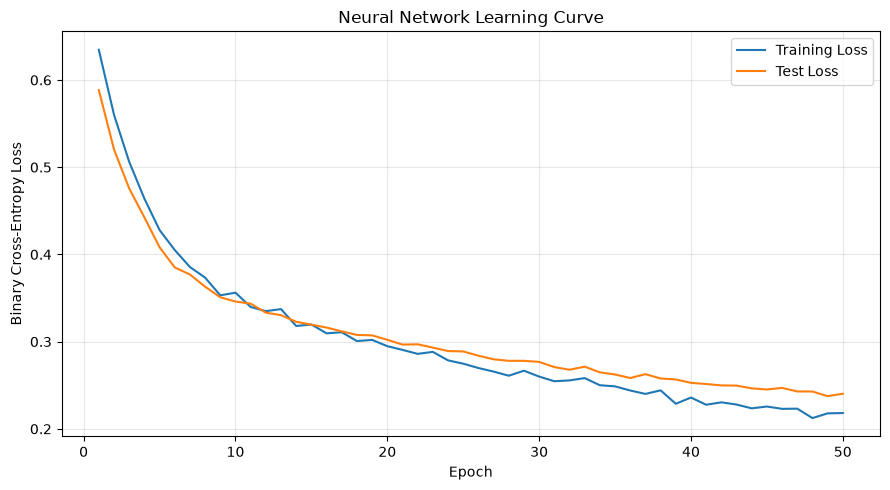

In [116]:
epochs = np.arange(1, n_epochs + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    test_losses,
    label="Test Loss"
)

plt.title("Neural Network Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Generate predictions

In [117]:
neural_model.eval()

with torch.no_grad():
    test_logits = neural_model(
        X_test_tensor.to(device)
    )

    y_prob_nn = torch.sigmoid(
        test_logits
    ).cpu().numpy().ravel()

y_pred_nn = (
    y_prob_nn >= 0.5
).astype(int)

print("First 10 probabilities:")
print(y_prob_nn[:10])

First 10 probabilities:
[9.3864465e-01 4.3227203e-02 1.4163689e-01 7.1357405e-01 5.6705829e-03
 9.9495548e-01 4.5139840e-04 2.2731222e-02 9.9926358e-01 1.6538784e-02]


## Evaluate

In [118]:
nn_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_nn
    ),
    "Precision": precision_score(
        y_test,
        y_pred_nn
    ),
    "Recall": recall_score(
        y_test,
        y_pred_nn
    ),
    "F1": f1_score(
        y_test,
        y_pred_nn
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_nn
    ),
    "PR-AUC": average_precision_score(
        y_test,
        y_prob_nn
    )
}

pd.Series(nn_metrics).round(4)

Accuracy     0.9325
Precision    0.9221
Recall       0.8855
F1           0.9035
ROC-AUC      0.9612
PR-AUC       0.9246
dtype: float64

## Confusion matrix

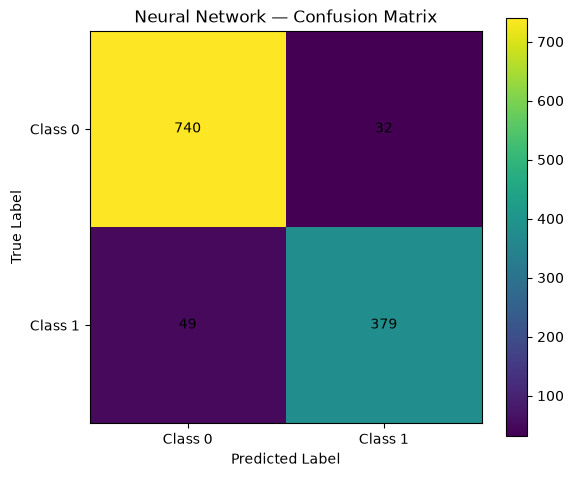

In [119]:
cm_nn = confusion_matrix(
    y_test,
    y_pred_nn
)

plt.figure(figsize=(6, 5))
plt.imshow(cm_nn)

plt.title("Neural Network — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Class 0", "Class 1"]
)

plt.yticks(
    [0, 1],
    ["Class 0", "Class 1"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_nn[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## ROC comparison

<Figure size 900x600 with 0 Axes>

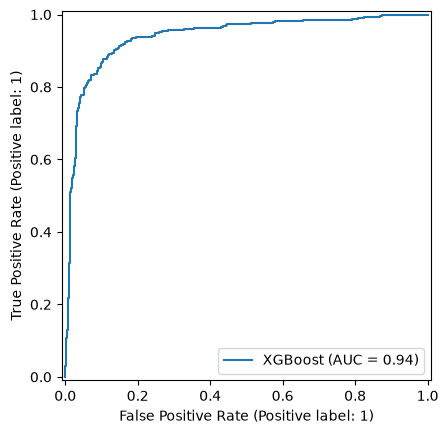

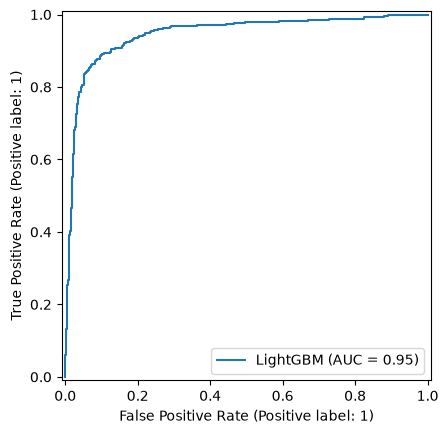

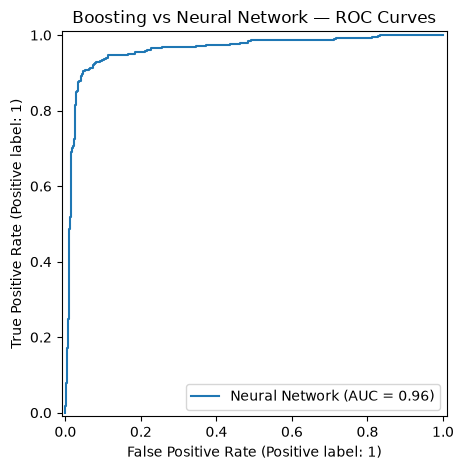

In [120]:
plt.figure(figsize=(9, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lgb,
    name="LightGBM"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_nn,
    name="Neural Network"
)

plt.title("Boosting vs Neural Network — ROC Curves")
plt.tight_layout()
plt.show()

## Precision–Recall comparison

<Figure size 900x600 with 0 Axes>

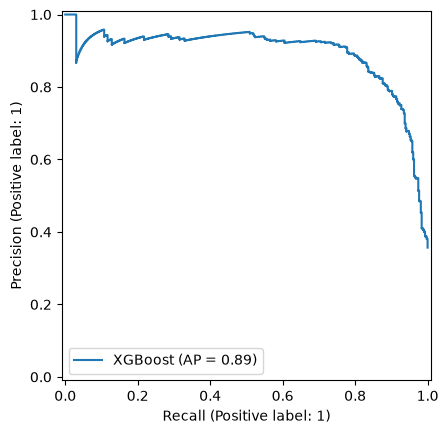

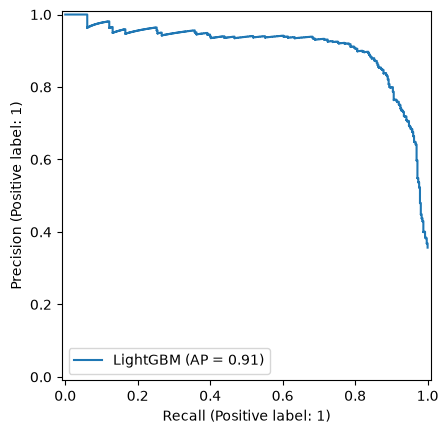

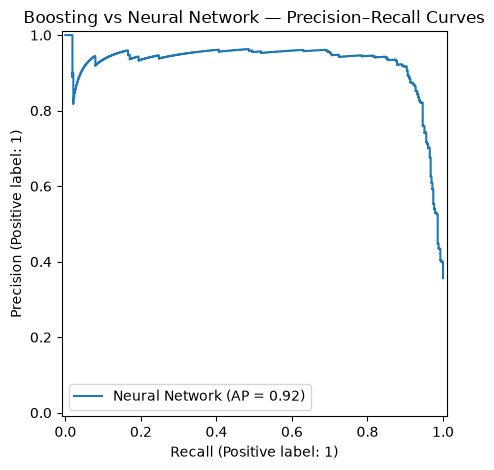

In [121]:
plt.figure(figsize=(9, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_lgb,
    name="LightGBM"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_nn,
    name="Neural Network"
)

plt.title("Boosting vs Neural Network — Precision–Recall Curves")
plt.tight_layout()
plt.show()

## Overall comparison

In [122]:
model_comparison = pd.DataFrame(
    {
        "Logistic Regression": logistic_metrics,
        "Linear SVM": linear_svm_metrics,
        "RBF SVM": rbf_svm_metrics,
        "Random Forest": rf_metrics,
        "Gradient Boosting": gb_metrics,
        "XGBoost": xgb_metrics,
        "LightGBM": lgb_metrics,
        "Neural Network": nn_metrics
    }
).T

model_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.7058,0.6271,0.4322,0.5118,0.7280,0.5845
Linear SVM,0.7067,0.6484,0.3879,0.4854,0.7192,0.6148
RBF SVM,0.8833,0.8830,0.7757,0.8259,0.9358,0.9013
Random Forest,0.8958,0.8855,0.8131,0.8477,0.9467,0.9137
Gradient Boosting,0.8633,0.8568,0.7407,0.7945,0.9189,0.8519
XGBoost,0.8925,0.8883,0.7991,0.8413,0.9401,0.8938
LightGBM,0.9025,0.8997,0.8178,0.8568,0.9464,0.9102
Neural Network,0.9325,0.9221,0.8855,0.9035,0.9612,0.9246


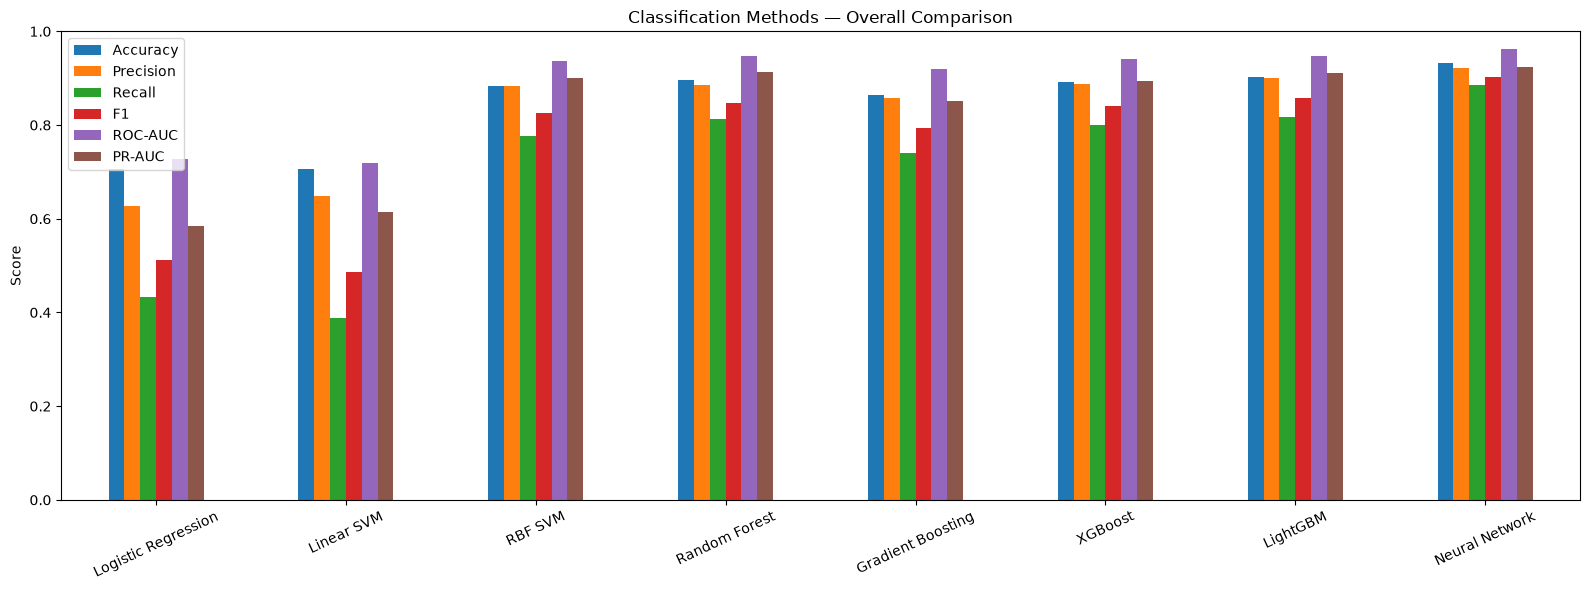

In [123]:
model_comparison[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(16, 6)
)

plt.title("Classification Methods — Overall Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

### Neural Classification Takeaways

The neural network demonstrates an important principle:

**model complexity does not automatically imply superior performance.**

For structured tabular data, gradient-boosted trees can be extremely competitive
because they naturally model:

- nonlinear relationships
- feature interactions
- heterogeneous feature effects
- irregular decision boundaries

Neural networks become particularly attractive when representation learning is
central to the problem.

For example:

$$
\text{raw pixels}
\rightarrow
\text{CNN representation}
\rightarrow
\text{classifier}
$$

or

$$
\text{text}
\rightarrow
\text{Transformer representation}
\rightarrow
\text{classifier}.
$$

Therefore, model selection should depend on the structure of the input rather
than simply choosing the most complex model.

We now have a broad collection of classifiers.

The next question is more subtle:

> How reliable are the probabilities produced by these models?

A classifier can have excellent ranking performance while producing poorly
calibrated probabilities.

This motivates the next section:

$$
\boxed{\text{12. Probability Calibration}}
$$

## 12. Probability Calibration

Many classifiers produce an estimated probability:

$$
\hat{p}(x)
=
P(Y=1\mid X=x).
$$

However, a value such as

$$
\hat{p}(x)=0.80
$$

should only be interpreted as an approximately 80% probability if the model is
well calibrated.

A classifier is perfectly calibrated when

$$
P(Y=1\mid \hat{p}(X)=p)=p.
$$

For example, among all observations assigned a probability close to $0.8$,
approximately 80% should actually belong to Class 1.

This distinction matters in applications such as:

- medical risk prediction
- credit risk
- fraud detection
- weather forecasting
- recommendation systems
- resource allocation

A model can have excellent ROC-AUC while still having poor probability
calibration.

Therefore, classification evaluation has at least two different questions:

1. **Can the model rank positive examples above negative examples?**
2. **Are the predicted probabilities trustworthy?**

### Reliability Diagram

A reliability diagram groups predictions into probability bins.

For each bin, we compare:

$$
\text{mean predicted probability}
$$

against

$$
\text{observed positive frequency}.
$$

A perfectly calibrated model follows the diagonal:

$$
y=x.
$$

The farther a model is from this diagonal, the greater its calibration error.

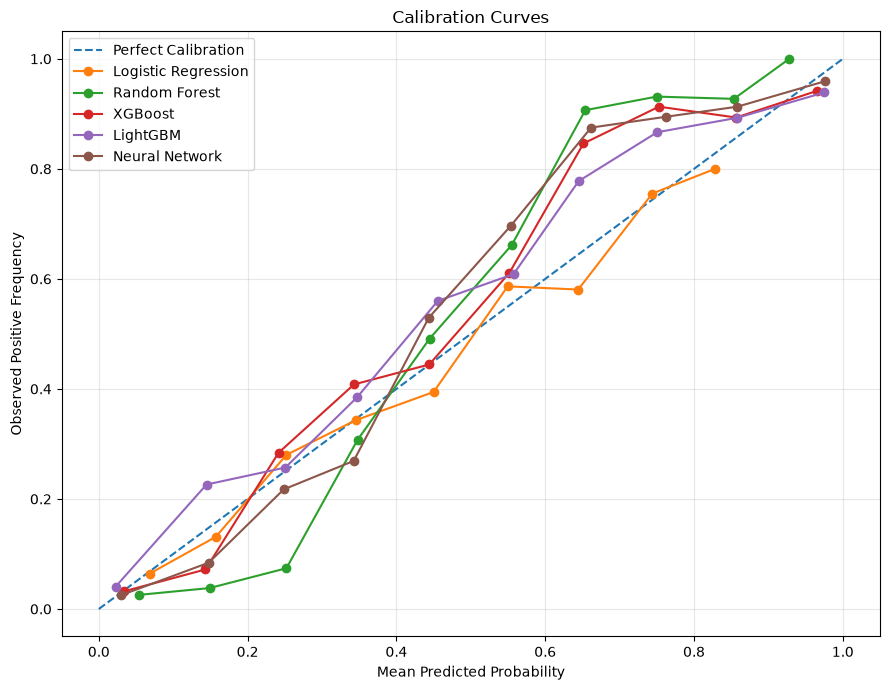

In [124]:
probability_models = {
    "Logistic Regression": y_prob_logistic,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb,
    "LightGBM": y_prob_lgb,
    "Neural Network": y_prob_nn
}

plt.figure(figsize=(9, 7))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

for name, probabilities in probability_models.items():

    fraction_positive, mean_predicted = calibration_curve(
        y_test,
        probabilities,
        n_bins=10,
        strategy="uniform"
    )

    plt.plot(
        mean_predicted,
        fraction_positive,
        marker="o",
        label=name
    )

plt.title("Calibration Curves")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Brier Score

For binary classification, the Brier score measures the squared difference
between predicted probabilities and actual outcomes:

$$
\text{Brier Score}
=
\frac{1}{n}
\sum_{i=1}^{n}
(\hat{p}_i-y_i)^2.
$$

Lower values are better.

Unlike accuracy, the Brier score evaluates the quality of the predicted
probabilities themselves.

It therefore provides information that a threshold-based metric such as F1
does not capture.

In [125]:
from sklearn.metrics import brier_score_loss

In [126]:
brier_results = {}

for name, probabilities in probability_models.items():
    brier_results[name] = brier_score_loss(
        y_test,
        probabilities
    )

brier_scores = pd.Series(
    brier_results,
    name="Brier Score"
).sort_values()

brier_scores.round(4)

Neural Network         0.0589
LightGBM               0.0773
XGBoost                0.0845
Random Forest          0.0915
Logistic Regression    0.1960
Name: Brier Score, dtype: float64

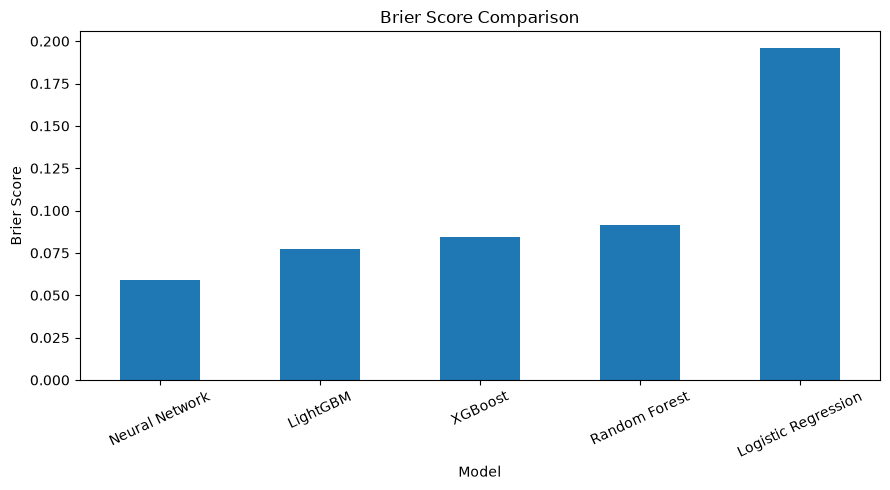

In [127]:
plt.figure(figsize=(9, 5))

brier_scores.plot(
    kind="bar"
)

plt.title("Brier Score Comparison")
plt.ylabel("Brier Score")
plt.xlabel("Model")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

### Probability Calibration Methods

A classifier can often be calibrated after training.

One common approach is **Platt scaling**, which learns a logistic transformation
of the model's decision score:

$$
P(Y=1\mid s)
=
\frac{1}
{1+\exp(As+B)},
$$

where $s$ is the original model score and $A,B$ are learned calibration
parameters.

Another approach is isotonic regression, which learns a flexible monotonic
mapping between model scores and observed probabilities.

Calibration should be learned using data that was not used to fit the original
classifier. Otherwise, calibration can itself overfit.

Let's calibrate the Random Forest using cross-validation:

In [128]:
calibrated_rf = CalibratedClassifierCV(
    estimator=RandomForestClassifier(
        n_estimators=400,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    method="sigmoid",
    cv=5
)

calibrated_rf.fit(
    X_train,
    y_train
)

y_prob_rf_calibrated = calibrated_rf.predict_proba(
    X_test
)[:, 1]

y_pred_rf_calibrated = (
    y_prob_rf_calibrated >= 0.5
).astype(int)

Evaluate:

In [129]:
calibrated_rf_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_rf_calibrated
    ),
    "Precision": precision_score(
        y_test,
        y_pred_rf_calibrated
    ),
    "Recall": recall_score(
        y_test,
        y_pred_rf_calibrated
    ),
    "F1": f1_score(
        y_test,
        y_pred_rf_calibrated
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_rf_calibrated
    ),
    "PR-AUC": average_precision_score(
        y_test,
        y_prob_rf_calibrated
    ),
    "Brier Score": brier_score_loss(
        y_test,
        y_prob_rf_calibrated
    )
}

pd.Series(calibrated_rf_metrics).round(4)

Accuracy       0.8958
Precision      0.8704
Recall         0.8318
F1             0.8507
ROC-AUC        0.9444
PR-AUC         0.9081
Brier Score    0.0801
dtype: float64

Compare Brier scores:

In [130]:
print(
    "Original Random Forest Brier Score:",
    round(
        brier_score_loss(
            y_test,
            y_prob_rf
        ),
        4
    )
)

print(
    "Calibrated Random Forest Brier Score:",
    round(
        brier_score_loss(
            y_test,
            y_prob_rf_calibrated
        ),
        4
    )
)

Original Random Forest Brier Score: 0.0915
Calibrated Random Forest Brier Score: 0.0801


Calibration curve before and after

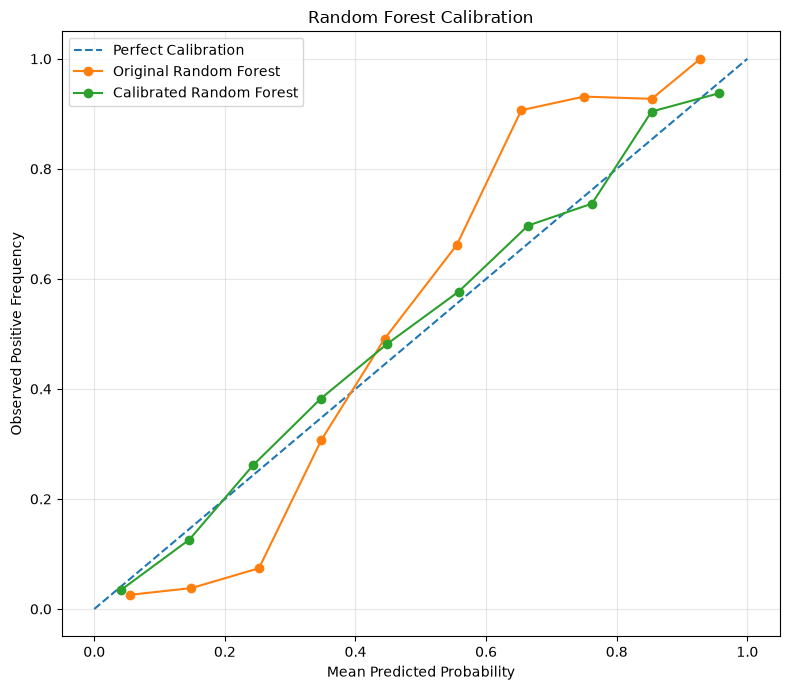

In [131]:
fraction_rf, mean_rf = calibration_curve(
    y_test,
    y_prob_rf,
    n_bins=10,
    strategy="uniform"
)

fraction_rf_cal, mean_rf_cal = calibration_curve(
    y_test,
    y_prob_rf_calibrated,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(8, 7))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.plot(
    mean_rf,
    fraction_rf,
    marker="o",
    label="Original Random Forest"
)

plt.plot(
    mean_rf_cal,
    fraction_rf_cal,
    marker="o",
    label="Calibrated Random Forest"
)

plt.title("Random Forest Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Important Distinction: Ranking vs Probability Quality

ROC-AUC primarily evaluates ranking.

If

$$
s(x^+)>s(x^-)
$$

for most positive-negative pairs, the model can achieve a strong ROC-AUC.

Calibration asks a different question:

$$
\hat{p}(x)\approx P(Y=1\mid X=x)?
$$

Therefore:

$$
\boxed{
\text{Discrimination}
\neq
\text{Calibration}
}
$$

A model can be:

- highly discriminative but poorly calibrated
- well calibrated but weakly discriminative
- strong in both
- weak in both

The appropriate evaluation depends on how the predictions will be used.

If only the ranking matters, ROC-AUC may be sufficient.

If predicted probabilities drive decisions, risk estimates, or resource
allocation, calibration becomes much more important.

## Final calibration visualization

In [132]:
calibration_comparison = pd.DataFrame(
    {
        "Model": list(probability_models.keys()),
        "Brier Score": [
            brier_score_loss(
                y_test,
                probabilities
            )
            for probabilities in probability_models.values()
        ]
    }
).sort_values("Brier Score")

calibration_comparison

,Model,Brier Score
4,Neural Network,0.058872
3,LightGBM,0.077296
2,XGBoost,0.084514
1,Random Forest,0.091506
0,Logistic Regression,0.196017


### Calibration Takeaways

We have now expanded classification evaluation beyond traditional predictive
metrics.

A useful evaluation framework is:

$$
\boxed{
\text{Classification}
=
\text{Discrimination}
+
\text{Calibration}
+
\text{Decision Quality}
}
$$

Discrimination can be evaluated using metrics such as:

- ROC-AUC
- PR-AUC

Classification performance at a chosen threshold can be evaluated using:

- precision
- recall
- F1
- confusion matrix

Probability quality can be evaluated using:

- calibration curves
- Brier score
- other proper scoring rules

The next issue is especially important for real-world classification:

**What happens when one class is much rarer than the other?**

Our dataset already contains some imbalance, so we will now examine how class
imbalance changes metrics, training strategies, and model decisions.

$$
\boxed{\text{Next: 13. Imbalanced Classification}}
$$

## 13. Imbalanced Classification

A classification dataset is imbalanced when the class frequencies differ
substantially.

Let

$$
N_0
=
\#\{i:y_i=0\}
$$

and

$$
N_1
=
\#\{i:y_i=1\}.
$$

The positive-class prevalence is

$$
\pi
=
\frac{N_1}{N_0+N_1}.
$$

When $\pi$ is small, a classifier can obtain deceptively high accuracy by
predicting the majority class almost everywhere.

For example, if

$$
\pi=0.05,
$$

a classifier that always predicts Class 0 achieves

$$
\text{Accuracy}=0.95,
$$

while having

$$
\text{Recall}=0.
$$

Therefore, imbalanced classification requires metrics and training strategies
that explicitly consider minority-class performance.

Important metrics include:

$$
\text{Precision}
=
\frac{TP}{TP+FP}
$$

$$
\text{Recall}
=
\frac{TP}{TP+FN}
$$

and

$$
F_1
=
2
\frac{\text{Precision}\cdot\text{Recall}}
{\text{Precision}+\text{Recall}}.
$$

For strongly imbalanced problems, the Precision–Recall curve can be
particularly informative because it focuses on the positive class.

## Create a strongly imbalanced dataset

In [133]:
X_imb, y_imb = make_classification(
    n_samples=8000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_classes=2,
    n_clusters_per_class=2,
    weights=[0.95, 0.05],
    class_sep=0.9,
    flip_y=0.02,
    random_state=RANDOM_STATE
)

X_imb = pd.DataFrame(
    X_imb,
    columns=[
        f"feature_{i+1}"
        for i in range(X_imb.shape[1])
    ]
)

y_imb = pd.Series(
    y_imb,
    name="target"
)

print(y_imb.value_counts())
print()
print(y_imb.value_counts(normalize=True))

target
0    7531
1     469
Name: count, dtype: int64

target
0    0.941375
1    0.058625
Name: proportion, dtype: float64


## Visualize the imbalance

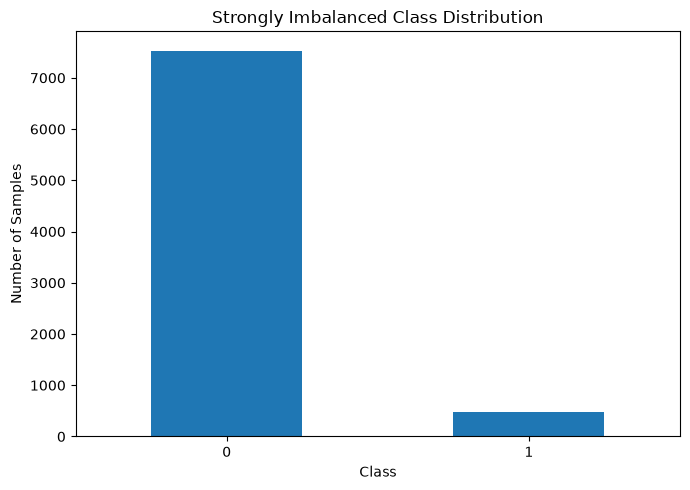

In [134]:
imb_counts = y_imb.value_counts().sort_index()

plt.figure(figsize=(7, 5))

imb_counts.plot(kind="bar")

plt.title("Strongly Imbalanced Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Train/test split

In [135]:
X_imb_train, X_imb_test, y_imb_train, y_imb_test = train_test_split(
    X_imb,
    y_imb,
    test_size=0.20,
    stratify=y_imb,
    random_state=RANDOM_STATE
)

print("Training distribution:")
print(y_imb_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_imb_test.value_counts(normalize=True))

Training distribution:
target
0    0.941406
1    0.058594
Name: proportion, dtype: float64

Test distribution:
target
0    0.94125
1    0.05875
Name: proportion, dtype: float64


### Majority-Class Baseline

Before training a sophisticated model, establish a trivial baseline.

The majority classifier always predicts

$$
\hat{y}=0.
$$

This baseline is surprisingly important because it tells us how much value the
machine-learning model actually provides.

In [136]:
majority_predictions = np.zeros(
    len(y_imb_test),
    dtype=int
)

majority_accuracy = accuracy_score(
    y_imb_test,
    majority_predictions
)

majority_precision = precision_score(
    y_imb_test,
    majority_predictions,
    zero_division=0
)

majority_recall = recall_score(
    y_imb_test,
    majority_predictions,
    zero_division=0
)

majority_f1 = f1_score(
    y_imb_test,
    majority_predictions,
    zero_division=0
)

print("Majority-class accuracy:", round(majority_accuracy, 4))
print("Majority-class precision:", round(majority_precision, 4))
print("Majority-class recall:", round(majority_recall, 4))
print("Majority-class F1:", round(majority_f1, 4))

Majority-class accuracy: 0.9413
Majority-class precision: 0.0
Majority-class recall: 0.0
Majority-class F1: 0.0


## Logistic Regression without class weighting

In [137]:
imbalanced_lr = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

imbalanced_lr.fit(
    X_imb_train,
    y_imb_train
)

y_imb_pred_lr = imbalanced_lr.predict(
    X_imb_test
)

y_imb_prob_lr = imbalanced_lr.predict_proba(
    X_imb_test
)[:, 1]

Evaluate:

In [138]:
imbalanced_lr_metrics = {
    "Accuracy": accuracy_score(
        y_imb_test,
        y_imb_pred_lr
    ),
    "Precision": precision_score(
        y_imb_test,
        y_imb_pred_lr,
        zero_division=0
    ),
    "Recall": recall_score(
        y_imb_test,
        y_imb_pred_lr,
        zero_division=0
    ),
    "F1": f1_score(
        y_imb_test,
        y_imb_pred_lr,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_imb_test,
        y_imb_prob_lr
    ),
    "PR-AUC": average_precision_score(
        y_imb_test,
        y_imb_prob_lr
    )
}

pd.Series(
    imbalanced_lr_metrics
).round(4)

Accuracy     0.9425
Precision    0.7500
Recall       0.0319
F1           0.0612
ROC-AUC      0.7452
PR-AUC       0.2253
dtype: float64

### Class-Weighted Learning

One common approach to class imbalance is to assign a larger training weight
to minority-class observations.

Conceptually, the weighted loss is

$$
\mathcal{L}
=
-\frac{1}{n}
\sum_{i=1}^{n}
w_{y_i}
\left[
y_i\log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right].
$$

If the minority class receives a larger weight, misclassifying a minority
example becomes more costly during training.

A common heuristic is

$$
w_k
=
\frac{n}{K\,n_k},
$$

where $n_k$ is the number of observations in class $k$.

Scikit-learn provides the convenient option

```text
class_weight="balanced"


Train weighted logistic regression:



In [140]:
weighted_lr = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

weighted_lr.fit(
    X_imb_train,
    y_imb_train
)

y_imb_pred_weighted = weighted_lr.predict(
    X_imb_test
)

y_imb_prob_weighted = weighted_lr.predict_proba(
    X_imb_test
)[:, 1]

Evaluate:

In [141]:
weighted_lr_metrics = {
    "Accuracy": accuracy_score(
        y_imb_test,
        y_imb_pred_weighted
    ),
    "Precision": precision_score(
        y_imb_test,
        y_imb_pred_weighted,
        zero_division=0
    ),
    "Recall": recall_score(
        y_imb_test,
        y_imb_pred_weighted,
        zero_division=0
    ),
    "F1": f1_score(
        y_imb_test,
        y_imb_pred_weighted,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_imb_test,
        y_imb_prob_weighted
    ),
    "PR-AUC": average_precision_score(
        y_imb_test,
        y_imb_prob_weighted
    )
}

pd.Series(
    weighted_lr_metrics
).round(4)

Accuracy     0.6988
Precision    0.1326
Recall       0.7447
F1           0.2251
ROC-AUC      0.7699
PR-AUC       0.1535
dtype: float64

## Compare weighted vs unweighted

In [142]:
imbalance_comparison = pd.DataFrame(
    {
        "Unweighted Logistic Regression":
            imbalanced_lr_metrics,
        "Class-Weighted Logistic Regression":
            weighted_lr_metrics
    }
).T

imbalance_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Unweighted Logistic Regression,0.9425,0.7500,0.0319,0.0612,0.7452,0.2253
Class-Weighted Logistic Regression,0.6988,0.1326,0.7447,0.2251,0.7699,0.1535


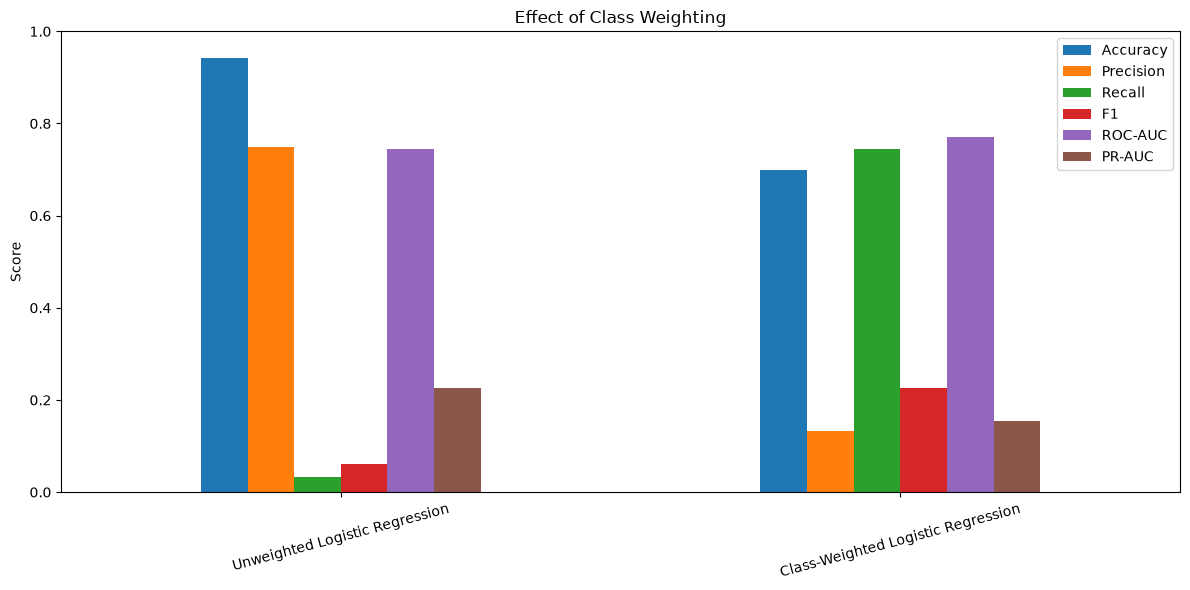

In [143]:
imbalance_comparison[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Effect of Class Weighting")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## Precision–Recall curves

<Figure size 900x600 with 0 Axes>

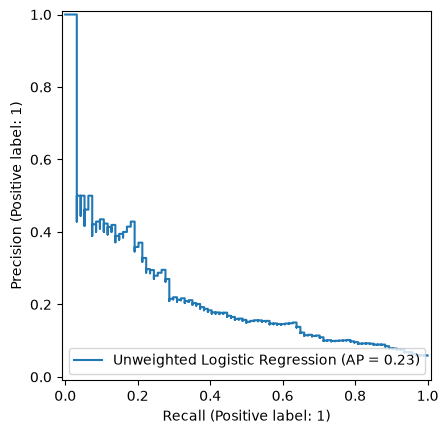

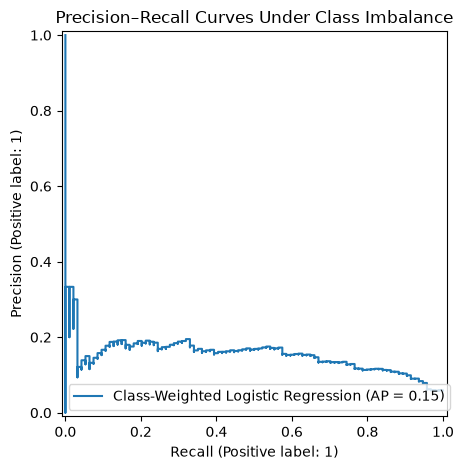

In [144]:
plt.figure(figsize=(9, 6))

PrecisionRecallDisplay.from_predictions(
    y_imb_test,
    y_imb_prob_lr,
    name="Unweighted Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_imb_test,
    y_imb_prob_weighted,
    name="Class-Weighted Logistic Regression"
)

plt.title("Precision–Recall Curves Under Class Imbalance")
plt.tight_layout()
plt.show()

## ROC curves

<Figure size 900x600 with 0 Axes>

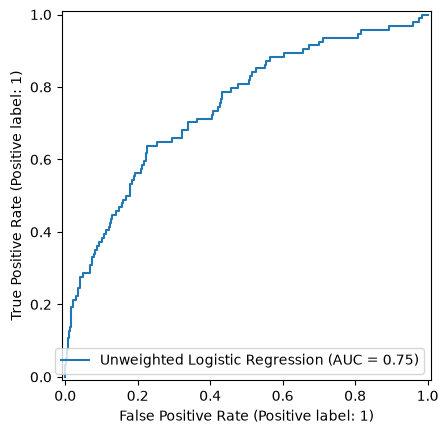

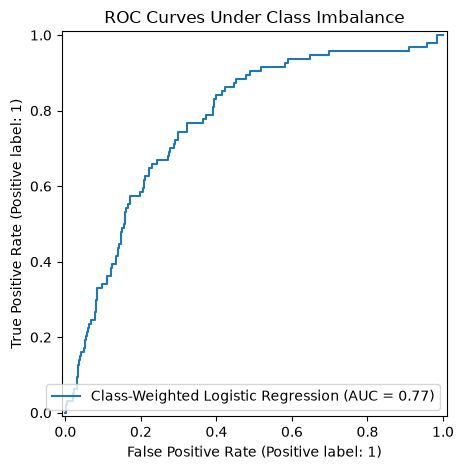

In [145]:
plt.figure(figsize=(9, 6))

RocCurveDisplay.from_predictions(
    y_imb_test,
    y_imb_prob_lr,
    name="Unweighted Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_imb_test,
    y_imb_prob_weighted,
    name="Class-Weighted Logistic Regression"
)

plt.title("ROC Curves Under Class Imbalance")
plt.tight_layout()
plt.show()

### Classification Threshold and Imbalance

A probabilistic classifier produces

$$
\hat{p}=P(Y=1\mid X=x).
$$

The default prediction rule is

$$
\hat{y}
=
\mathbb{1}[\hat{p}\geq0.5].
$$

However, $0.5$ is not a universal threshold.

For an imbalanced problem, we may deliberately lower the threshold to identify
more minority-class observations.

Lowering the threshold generally produces:

$$
\text{Recall}\uparrow
$$

but often:

$$
\text{Precision}\downarrow.
$$

This is not a model failure. It is a decision trade-off.

In [146]:
thresholds = np.arange(
    0.05,
    0.96,
    0.05
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        y_imb_prob_lr >= threshold
    ).astype(int)

    threshold_results.append(
        {
            "Threshold": threshold,
            "Precision": precision_score(
                y_imb_test,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_imb_test,
                predictions,
                zero_division=0
            ),
            "F1": f1_score(
                y_imb_test,
                predictions,
                zero_division=0
            )
        }
    )

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.round(4)

,Threshold,Precision,Recall,F1
0,0.05,0.1082,0.7021,0.1875
1,0.10,0.1623,0.4574,0.2396
2,0.15,0.2117,0.3085,0.2511
3,0.20,0.3088,0.2234,0.2593
4,0.25,0.3939,0.1383,0.2047
5,0.30,0.4211,0.0851,0.1416
6,0.35,0.4167,0.0532,0.0943
7,0.40,0.5000,0.0319,0.0600
8,0.45,0.7500,0.0319,0.0612
9,0.50,0.7500,0.0319,0.0612


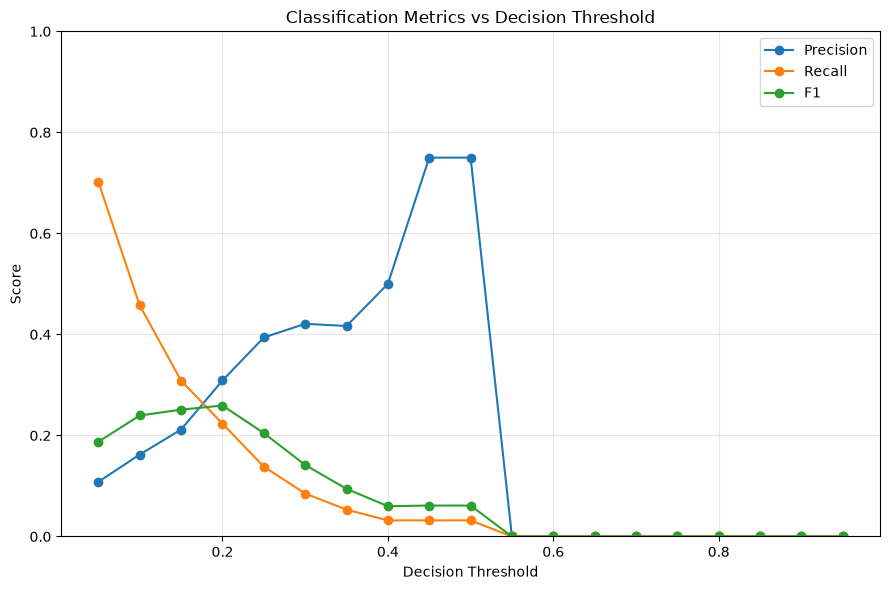

In [147]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

plt.title("Classification Metrics vs Decision Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Find the F1-optimal threshold

In [148]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold_row

Threshold    0.200000
Precision    0.308824
Recall       0.223404
F1           0.259259
Name: 3, dtype: float64

In [149]:
best_threshold = best_threshold_row["Threshold"]

y_pred_threshold_optimal = (
    y_imb_prob_lr >= best_threshold
).astype(int)

print("Selected threshold:", best_threshold)

print(
    classification_report(
        y_imb_test,
        y_pred_threshold_optimal,
        target_names=["Class 0", "Class 1"]
    )
)

Selected threshold: 0.2
              precision    recall  f1-score   support

     Class 0       0.95      0.97      0.96      1506
     Class 1       0.31      0.22      0.26        94

    accuracy                           0.93      1600
   macro avg       0.63      0.60      0.61      1600
weighted avg       0.91      0.93      0.92      1600



## Confusion matrix at the optimized threshold

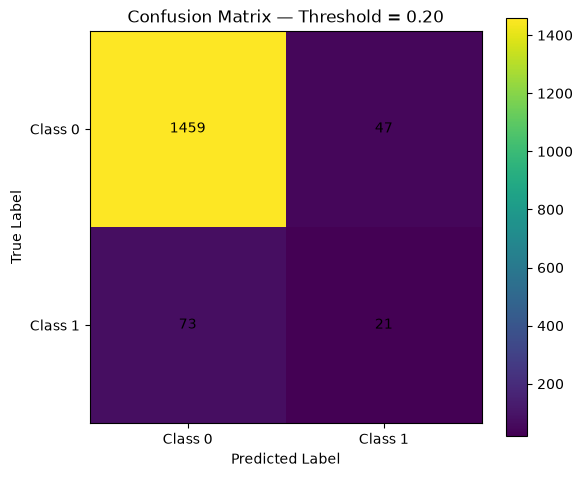

In [150]:
cm_threshold = confusion_matrix(
    y_imb_test,
    y_pred_threshold_optimal
)

plt.figure(figsize=(6, 5))
plt.imshow(cm_threshold)

plt.title(
    f"Confusion Matrix — Threshold = {best_threshold:.2f}"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Class 0", "Class 1"]
)

plt.yticks(
    [0, 1],
    ["Class 0", "Class 1"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_threshold[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

### Model Prediction vs Decision Policy

A useful distinction is:

$$
\boxed{
\text{Model}
\rightarrow
\text{Probability}
\rightarrow
\text{Decision Rule}
}
$$

The model estimates

$$
\hat{p}=P(Y=1\mid X=x).
$$

The decision rule converts that probability into an action:

$$
a=
g(\hat{p}).
$$

Changing the threshold changes the decision rule without necessarily changing
the underlying model.

Therefore, a classification system should not be evaluated only at the
default threshold.

The optimal threshold depends on the relative costs of different errors.

For example, if a false negative costs $C_{FN}$ and a false positive costs
$C_{FP}$, the decision threshold should reflect those costs rather than blindly
using $0.5$.

This is the beginning of **cost-sensitive classification**.

### Imbalanced Classification Takeaways

When classes are imbalanced:

1. Do not rely on accuracy alone.
2. Establish a majority-class baseline.
3. Examine precision and recall.
4. Use F1 when an appropriate balance between precision and recall is desired.
5. Examine Precision–Recall curves.
6. Consider class-weighted learning.
7. Consider threshold optimization.
8. Evaluate the business or application cost of FP and FN errors.

The central principle is:

$$
\boxed{
\text{Rare class}
\neq
\text{unimportant class}
}
$$

and

$$
\boxed{
\text{Classification threshold}
\neq
\text{fixed law of nature}.
}
$$

A classifier produces information about risk. The threshold determines how
that information is converted into a decision.

In the next section, we will study this decision process more systematically
through **threshold optimization and cost-sensitive classification**.

## 14. Threshold Optimization & Cost-Sensitive Classification

A probabilistic classifier estimates

$$
\hat{p}(x)=P(Y=1\mid X=x).
$$

A separate decision rule converts this probability into a class prediction:

$$
\hat{y}
=
\mathbb{1}[\hat{p}(x)\geq t].
$$

The threshold $t$ is therefore a **decision parameter**.

The optimal threshold depends on the objective.

Different objectives may include:

- maximizing F1
- maximizing recall
- maximizing precision
- maximizing Youden's J statistic
- minimizing expected classification cost
- satisfying a minimum precision requirement
- satisfying a minimum recall requirement

Therefore, instead of asking:

> Which threshold is universally correct?

we should ask:

> Which threshold is appropriate for the decision problem?

## Generate threshold metrics

In [151]:
thresholds_fine = np.linspace(
    0.01,
    0.99,
    99
)

threshold_analysis = []

for threshold in thresholds_fine:

    predictions = (
        y_imb_prob_lr >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_imb_test,
        predictions
    ).ravel()

    precision = precision_score(
        y_imb_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_imb_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_imb_test,
        predictions,
        zero_division=0
    )

    specificity = tn / (tn + fp)

    youden_j = recall + specificity - 1

    threshold_analysis.append(
        {
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "Specificity": specificity,
            "F1": f1,
            "Youden_J": youden_j,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        }
    )

threshold_analysis = pd.DataFrame(
    threshold_analysis
)

threshold_analysis.head()

,Threshold,Precision,Recall,Specificity,F1,Youden_J,TN,FP,FN,TP
0,0.01,0.063282,0.968085,0.105578,0.118799,0.073663,159,1347,3,91
1,0.02,0.074136,0.936170,0.270252,0.137393,0.206423,407,1099,6,88
2,0.03,0.088017,0.882979,0.428951,0.160077,0.311930,646,860,11,83
3,0.04,0.099865,0.787234,0.557105,0.177246,0.344339,839,667,20,74
4,0.05,0.108197,0.702128,0.638778,0.187500,0.340906,962,544,28,66


## Visualize the trade-offs

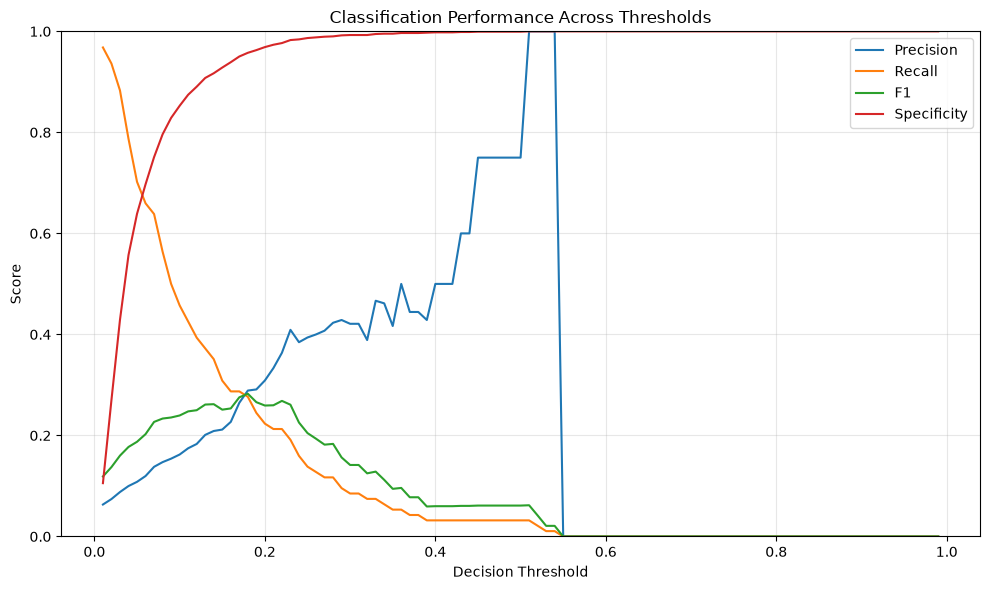

In [152]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_analysis["Threshold"],
    threshold_analysis["Precision"],
    label="Precision"
)

plt.plot(
    threshold_analysis["Threshold"],
    threshold_analysis["Recall"],
    label="Recall"
)

plt.plot(
    threshold_analysis["Threshold"],
    threshold_analysis["F1"],
    label="F1"
)

plt.plot(
    threshold_analysis["Threshold"],
    threshold_analysis["Specificity"],
    label="Specificity"
)

plt.title("Classification Performance Across Thresholds")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### F1-Based Threshold Selection

The F1 score is

$$
F_1
=
2
\frac{PR}{P+R}.
$$

It is the harmonic mean of precision and recall.

If precision and recall are both important and neither should dominate the
objective, we can select the threshold that maximizes F1:

$$
t^*
=
\arg\max_t F_1(t).
$$

In [153]:
f1_best = threshold_analysis.loc[
    threshold_analysis["F1"].idxmax()
]

print(
    "F1-optimal threshold:",
    round(f1_best["Threshold"], 3)
)

print(
    "Maximum F1:",
    round(f1_best["F1"], 4)
)

F1-optimal threshold: 0.18
Maximum F1: 0.2826


### Youden's J Statistic

Another threshold-selection criterion is Youden's J statistic:

$$
J
=
\text{Sensitivity}
+
\text{Specificity}
-
1.
$$

Since

$$
\text{Sensitivity}=\text{Recall},
$$

we can write

$$
J
=
\text{Recall}
+
\text{Specificity}
-
1.
$$

The threshold maximizing $J$ balances sensitivity and specificity:

$$
t^*
=
\arg\max_t J(t).
$$

This criterion is often useful when false positives and false negatives are
treated symmetrically.

In [154]:
youden_best = threshold_analysis.loc[
    threshold_analysis["Youden_J"].idxmax()
]

print(
    "Youden-optimal threshold:",
    round(youden_best["Threshold"], 3)
)

print(
    "Maximum Youden J:",
    round(youden_best["Youden_J"], 4)
)

Youden-optimal threshold: 0.07
Maximum Youden J: 0.3893


## Compare threshold-selection criteria

In [155]:
threshold_choices = pd.DataFrame(
    {
        "Criterion": [
            "Default",
            "F1",
            "Youden J"
        ],
        "Threshold": [
            0.50,
            f1_best["Threshold"],
            youden_best["Threshold"]
        ]
    }
)

threshold_choices

,Criterion,Threshold
0,Default,0.50
1,F1,0.18
2,Youden J,0.07


## Evaluate them:

In [156]:
threshold_evaluation = []

for _, row in threshold_choices.iterrows():

    threshold = row["Threshold"]

    predictions = (
        y_imb_prob_lr >= threshold
    ).astype(int)

    threshold_evaluation.append(
        {
            "Criterion": row["Criterion"],
            "Threshold": threshold,
            "Precision": precision_score(
                y_imb_test,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_imb_test,
                predictions,
                zero_division=0
            ),
            "F1": f1_score(
                y_imb_test,
                predictions,
                zero_division=0
            )
        }
    )

threshold_evaluation = pd.DataFrame(
    threshold_evaluation
)

threshold_evaluation.round(4)

,Criterion,Threshold,Precision,Recall,F1
0,Default,0.50,0.7500,0.0319,0.0612
1,F1,0.18,0.2889,0.2766,0.2826
2,Youden J,0.07,0.1379,0.6383,0.2268


## 14.6 Cost-Sensitive Classification

Accuracy and F1 do not explicitly represent the cost of different errors.

Suppose:

- false positive cost = $C_{FP}$
- false negative cost = $C_{FN}$.

Then the total classification cost is

$$
C
=
C_{FP}FP
+
C_{FN}FN.
$$

More generally, an expected cost can be written as

$$
\mathbb{E}[C]
=
C_{FP}P(FP)
+
C_{FN}P(FN).
$$

If false negatives are much more expensive than false positives, the optimal
decision rule should generally become more sensitive to the positive class.

This is common in applications such as:

- fraud detection
- medical screening
- safety monitoring
- fault detection

The threshold should therefore reflect the consequences of the decision.

Define explicit costs

For demonstration, assume:

$$ C_{FP}=1 $$

and

C
FN
	​

=5.

In [157]:
cost_fp = 1
cost_fn = 5

cost_results = []

for threshold in thresholds_fine:

    predictions = (
        y_imb_prob_lr >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_imb_test,
        predictions
    ).ravel()

    total_cost = (
        cost_fp * fp
        +
        cost_fn * fn
    )

    cost_results.append(
        {
            "Threshold": threshold,
            "FP": fp,
            "FN": fn,
            "Total Cost": total_cost
        }
    )

cost_results = pd.DataFrame(
    cost_results
)

cost_results.head()

,Threshold,FP,FN,Total Cost
0,0.01,1347,3,1362
1,0.02,1099,6,1129
2,0.03,860,11,915
3,0.04,667,20,767
4,0.05,544,28,684


## Find the minimum-cost threshold:

In [158]:
minimum_cost_row = cost_results.loc[
    cost_results["Total Cost"].idxmin()
]

print(
    "Minimum-cost threshold:",
    round(
        minimum_cost_row["Threshold"],
        3
    )
)

print(
    "Minimum total cost:",
    int(
        minimum_cost_row["Total Cost"]
    )
)

Minimum-cost threshold: 0.18
Minimum total cost: 404


## Cost curve

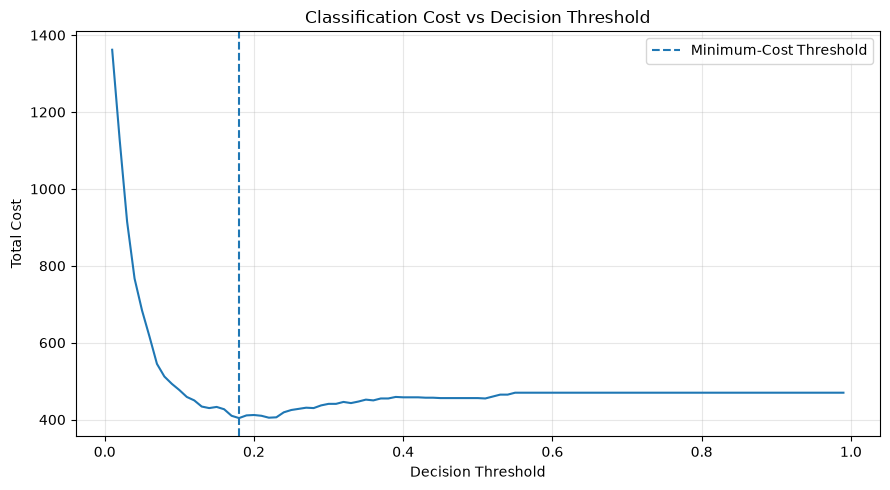

In [159]:
plt.figure(figsize=(9, 5))

plt.plot(
    cost_results["Threshold"],
    cost_results["Total Cost"]
)

plt.axvline(
    x=minimum_cost_row["Threshold"],
    linestyle="--",
    label="Minimum-Cost Threshold"
)

plt.title("Classification Cost vs Decision Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Cost")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Compare different cost ratios

In [160]:
cost_scenarios = {
    "Equal Cost": (1, 1),
    "FN = 3 × FP": (1, 3),
    "FN = 5 × FP": (1, 5),
    "FN = 10 × FP": (1, 10)
}

scenario_results = []

for scenario, (fp_cost, fn_cost) in cost_scenarios.items():

    scenario_costs = []

    for threshold in thresholds_fine:

        predictions = (
            y_imb_prob_lr >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_imb_test,
            predictions
        ).ravel()

        total_cost = (
            fp_cost * fp
            +
            fn_cost * fn
        )

        scenario_costs.append(
            total_cost
        )

    best_index = np.argmin(
        scenario_costs
    )

    scenario_results.append(
        {
            "Scenario": scenario,
            "FP Cost": fp_cost,
            "FN Cost": fn_cost,
            "Optimal Threshold":
                thresholds_fine[best_index],
            "Minimum Cost":
                scenario_costs[best_index]
        }
    )

scenario_results = pd.DataFrame(
    scenario_results
)

scenario_results.round(4)

,Scenario,FP Cost,FN Cost,Optimal Threshold,Minimum Cost
0,Equal Cost,1,1,0.51,91
1,FN = 3 × FP,1,3,0.23,254
2,FN = 5 × FP,1,5,0.18,404
3,FN = 10 × FP,1,10,0.07,715


### Constrained Threshold Selection

In many applications, the requirement is expressed as a constraint.

For example:

$$
\text{Recall}\geq0.90.
$$

Among all thresholds satisfying this requirement, we may select the one with
the highest precision.

This produces a more application-oriented decision rule.

In [161]:
minimum_recall = 0.90

eligible_thresholds = threshold_analysis[
    threshold_analysis["Recall"] >= minimum_recall
].copy()

best_precision_under_recall = eligible_thresholds.loc[
    eligible_thresholds["Precision"].idxmax()
]

best_precision_under_recall[
    [
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
]

Threshold    0.020000
Precision    0.074136
Recall       0.936170
F1           0.137393
Name: 1, dtype: float64

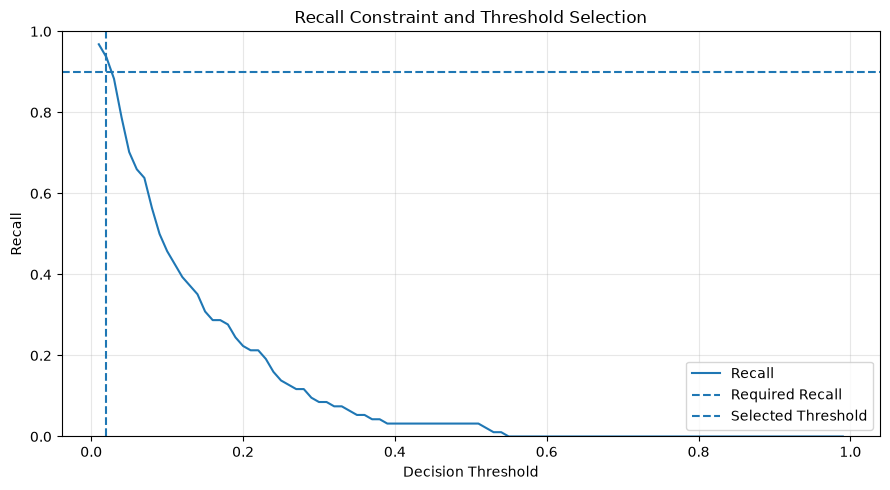

In [162]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_analysis["Threshold"],
    threshold_analysis["Recall"],
    label="Recall"
)

plt.axhline(
    y=minimum_recall,
    linestyle="--",
    label="Required Recall"
)

plt.axvline(
    x=best_precision_under_recall["Threshold"],
    linestyle="--",
    label="Selected Threshold"
)

plt.title("Recall Constraint and Threshold Selection")
plt.xlabel("Decision Threshold")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Avoiding Threshold-Selection Leakage

The test set should not be used to choose the final threshold.

The correct workflow is:

$$
\text{Training Data}
\rightarrow
\text{Model Fitting}
$$

$$
\text{Validation Data}
\rightarrow
\text{Threshold Selection}
$$

$$
\text{Test Data}
\rightarrow
\text{Final Evaluation}.
$$

If the threshold is optimized directly on the test set, the test set is no
longer an unbiased estimate of final performance.

The experiments above use the test set to demonstrate the mechanics of
threshold optimization. In a production-quality workflow, the threshold would
be selected using validation or cross-validation predictions and then applied
once to the final test set.

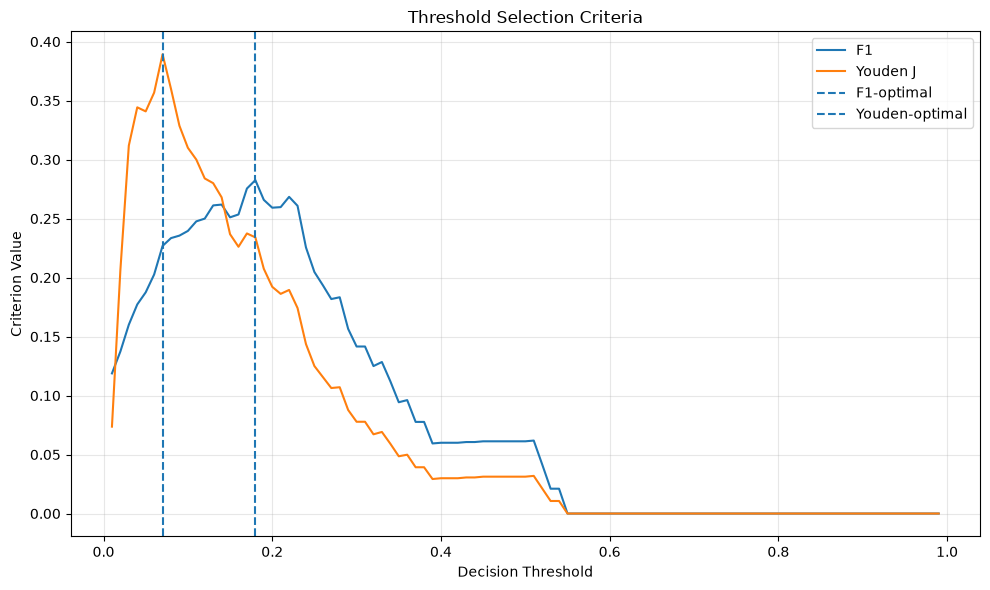

In [163]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_analysis["Threshold"],
    threshold_analysis["F1"],
    label="F1"
)

plt.plot(
    threshold_analysis["Threshold"],
    threshold_analysis["Youden_J"],
    label="Youden J"
)

plt.axvline(
    x=f1_best["Threshold"],
    linestyle="--",
    label="F1-optimal"
)

plt.axvline(
    x=youden_best["Threshold"],
    linestyle="--",
    label="Youden-optimal"
)

plt.title("Threshold Selection Criteria")
plt.xlabel("Decision Threshold")
plt.ylabel("Criterion Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 14.14 Threshold Optimization Takeaways

A classification system has two distinct components:

$$
\boxed{
\text{Probability Model}
+
\text{Decision Policy}
}
$$

The model estimates

$$
P(Y=1\mid X=x),
$$

while the decision policy determines how that probability is converted into
an action.

Different objectives produce different thresholds:

$$
\begin{aligned}
t_{\text{F1}}
&=
\arg\max_t F_1(t)\\
\\
t_{\text{Youden}}
&=
\arg\max_t
\left[
\text{Sensitivity}(t)
+
\text{Specificity}(t)
-
1
\right]\\
\\
t_{\text{cost}}
&=
\arg\min_t
\left[
C_{FP}FP(t)
+
C_{FN}FN(t)
\right].
\end{aligned}
$$

Therefore:

$$
\boxed{
\text{There is no universally optimal classification threshold}
}
$$

The correct threshold depends on the objective and the consequences of errors.

The next step is to build a **single rigorous evaluation framework** so that all
of our classifiers can be compared consistently using cross-validation rather
than relying only on one train/test split.

$$
\boxed{\text{Next: 15. Cross-Validation and Robust Model Comparison}}
$$

# 15. Cross-Validation & Robust Model Comparison

So far, we have evaluated our classification models primarily using a single train/test split.

A single split is useful for demonstrating how a classifier works, but it can produce a noisy estimate of generalization performance. A model may appear better or worse simply because of the particular observations assigned to the test set.

Cross-validation provides a more robust evaluation strategy by repeatedly training and validating the model on different subsets of the training data.

In this section, we will:

* Understand K-Fold Cross-Validation
* Understand Stratified K-Fold Cross-Validation
* Verify class distributions across folds
* Prevent preprocessing leakage during cross-validation
* Compare multiple classification models using the same folds
* Evaluate Accuracy, Precision, Recall, F1, ROC-AUC, and PR-AUC
* Measure mean performance and fold-to-fold variability
* Analyze training-validation performance gaps
* Rank models using multiple evaluation criteria
* Select a model based on robust validation evidence

> **Important:** The final test set should remain untouched during model selection. Cross-validation should be performed using the training data, while the test set should be reserved for the final evaluation.

---

## 15.1 Why Cross-Validation?

Suppose we train a classifier using one particular train/validation split.

```text
Dataset
   │
   ├── Training Data
   │       │
   │       └── Model Training
   │
   └── Test Data
           │
           └── Performance Estimate
```

The resulting score depends partly on which observations happened to be placed in the test set.

A different random split could produce a different score.

Cross-validation reduces this dependence by evaluating the model on multiple validation subsets.

The basic idea is:

```text
Training Data
│
├── Fold 1 → Validation
├── Fold 2 → Validation
├── Fold 3 → Validation
├── Fold 4 → Validation
└── Fold 5 → Validation
```

Each fold is used as the validation set once, while the remaining folds are used for training.

---

## 15.2 K-Fold Cross-Validation

Let the training dataset be divided into $K$ approximately equal-sized folds:

$$
D = D_1 \cup D_2 \cup \cdots \cup D_K
$$

For fold $k$, the model is trained using:

$$
D_{\text{train}}^{(k)}
=
D \setminus D_k
$$

and evaluated using:

$$
D_{\text{validation}}^{(k)}
=
D_k.
$$

This process is repeated for all $K$ folds.

The resulting validation scores are:

$$
s_1,s_2,\ldots,s_K
$$

The mean cross-validation score is:

$$
\bar{s}
=
\frac{1}{K}
\sum_{k=1}^{K}s_k
$$

The standard deviation is:

$$
s_{\text{std}}
=
\sqrt{
\frac{1}{K-1}
\sum_{k=1}^{K}
(s_k-\bar{s})^2
}
$$

Therefore, model performance can be reported as:

$$
\boxed{
\bar{s}\pm s_{\text{std}}
}
$$

For example:

$$
\text{ROC-AUC}=0.923\pm0.014
$$

The mean represents the average performance, while the standard deviation provides information about the stability of the model across different folds.

---

## 15.3 Why Stratified K-Fold?

For classification problems, preserving the class distribution across folds is important.

Suppose our dataset contains:

```text
Class 0 → 65%
Class 1 → 35%
```

A poorly constructed fold might contain a substantially different distribution.

**Stratified K-Fold Cross-Validation** attempts to preserve the class proportions in every fold.

Conceptually:

$$
P_{\text{fold}}(Y=k)
\approx
P_{\text{training}}(Y=k)
$$

This is particularly important for:

* Binary classification
* Multiclass classification
* Imbalanced classification

For our binary classification experiment, we will therefore use `StratifiedKFold`.

---

## 15.4 Cross-Validation and Data Leakage

Cross-validation must be performed without allowing information from the validation fold to influence the training process.

This becomes especially important when preprocessing is required.

For example, `StandardScaler` estimates parameters from the data:

$$
\mu_j
=
\frac{1}{n}
\sum_{i=1}^{n}x_{ij}
$$

and

$$
\sigma_j
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(x_{ij}-\mu_j)^2
}
$$

If we standardize the entire dataset before cross-validation, information from the validation folds is indirectly used to calculate these parameters.

That creates **data leakage**.

The correct approach is:

```text
Fold
│
├── Training portion
│      │
│      ├── Fit scaler
│      └── Transform training data
│
└── Validation portion
       │
       └── Transform using training-fold scaler
```

Scikit-learn `Pipeline` handles this correctly.

Therefore:

$$
\boxed{
\text{Preprocessing} \rightarrow \text{Model}
}
$$

should generally be placed inside a pipeline when cross-validation is used.

---

## 15.5 Experimental Protocol

For this section, we will follow the following evaluation protocol:

```text
Original Dataset
       │
       ├────────────── Training Data
       │                    │
       │                    └── 5-Fold Stratified CV
       │                             │
       │                             ├── Model Selection
       │                             ├── Hyperparameter Analysis
       │                             └── Performance Estimation
       │
       └────────────── Test Data
                            │
                            └── Final Evaluation
```

The test set should not be used to select the best model.

This distinction is fundamental:

$$
\boxed{
\text{Cross-Validation}=\text{Model Selection}
}
$$

while:

$$
\boxed{
\text{Test Set}=\text{Final Generalization Estimate}
}
$$

---

## 15.6 Models to Compare

We will compare several classification approaches that we have studied:

1. Logistic Regression
2. Linear SVM
3. RBF SVM
4. Random Forest
5. Gradient Boosting
6. XGBoost
7. LightGBM

These models represent different approaches to classification:

| Model               | Main Idea                              |
| ------------------- | -------------------------------------- |
| Logistic Regression | Linear probabilistic decision boundary |
| Linear SVM          | Maximum-margin linear classifier       |
| RBF SVM             | Kernel-based nonlinear classifier      |
| Random Forest       | Bagging of decision trees              |
| Gradient Boosting   | Sequential additive tree modeling      |
| XGBoost             | Regularized gradient-boosted trees     |
| LightGBM            | Efficient gradient-boosted trees       |

The CatBoost experiment will remain separate because it was constructed using a different mixed numerical/categorical dataset.

The PyTorch neural classifier will also remain outside this sklearn-based cross-validation experiment because it uses a custom training loop. A rigorous neural-network cross-validation experiment would require a separate manual CV implementation or an sklearn-compatible wrapper.

---

## 15.7 Evaluation Metrics

We will evaluate the classifiers using several complementary metrics.

### Accuracy

$$
\text{Accuracy}
=
\frac{TP+TN}
{TP+TN+FP+FN}
$$

### Precision

$$
\text{Precision}
=
\frac{TP}
{TP+FP}
$$

### Recall

$$
\text{Recall}
=
\frac{TP}
{TP+FN}
$$

### F1 Score

$$
F_1
=
2
\frac{
\text{Precision}\cdot\text{Recall}
}{
\text{Precision}+\text{Recall}
}
$$

### ROC-AUC

ROC-AUC measures how well the classifier ranks positive observations above negative observations across classification thresholds.

### PR-AUC

PR-AUC summarizes the Precision-Recall relationship across thresholds and is particularly useful when positive examples are relatively uncommon.

No single metric is universally sufficient.

Therefore, robust model comparison should consider several metrics simultaneously.

---

## 15.8 What We Want to Learn

At the end of this section, we should be able to answer:

> **Which classification model provides the best balance of performance, stability, and generalization for this dataset?**

We should also be able to distinguish between:

* High average performance
* High variance
* Overfitting
* Stable generalization
* Metric-specific superiority
* Practical model-selection trade-offs

The objective is therefore not simply:

$$
\text{Choose model with highest score}
$$

but rather:

$$
\boxed{
\text{Choose the model supported by the strongest validation evidence}
}
$$


In [164]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Cross-validation strategy:")
print(cv)

Cross-validation strategy:
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 15.9 Inspect the Cross-Validation Folds

Our `StratifiedKFold` object creates five different train-validation combinations.

For each iteration:

* Four folds are used for training.
* One fold is used for validation.
* Every observation is used for validation exactly once.
* The class proportions are approximately preserved.

We will first inspect the number of observations in each split.


In [165]:
fold_information = []

for fold, (train_idx, valid_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):
    fold_information.append({
        "Fold": fold,
        "Training Samples": len(train_idx),
        "Validation Samples": len(valid_idx)
    })

fold_information = pd.DataFrame(fold_information)

fold_information

,Fold,Training Samples,Validation Samples
0,1,3840,960
1,2,3840,960
2,3,3840,960
3,4,3840,960
4,5,3840,960


## 15.10 Verify Stratification

Stratification should maintain approximately the same class proportions in every validation fold.

We can verify this directly by calculating the proportion of each class within every fold.

This is an important sanity check before performing the model comparison.


In [166]:
fold_class_distribution = []

for fold, (_, valid_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):
    y_valid_fold = y_train.iloc[valid_idx]

    class_proportions = (
        y_valid_fold
        .value_counts(normalize=True)
        .sort_index()
    )

    fold_class_distribution.append({
        "Fold": fold,
        "Class 0": class_proportions.get(0, 0),
        "Class 1": class_proportions.get(1, 0)
    })

fold_class_distribution = pd.DataFrame(
    fold_class_distribution
)

fold_class_distribution

,Fold,Class 0,Class 1
0,1,0.643750,0.356250
1,2,0.643750,0.356250
2,3,0.642708,0.357292
3,4,0.642708,0.357292
4,5,0.642708,0.357292


In [167]:
overall_distribution = (
    y_train
    .value_counts(normalize=True)
    .sort_index()
)

print("Overall training class distribution:")
print(overall_distribution)

print("\nValidation-fold class distributions:")
display(fold_class_distribution)

Overall training class distribution:
target
0    0.643125
1    0.356875
Name: proportion, dtype: float64

Validation-fold class distributions:


,Fold,Class 0,Class 1
0,1,0.643750,0.356250
1,2,0.643750,0.356250
2,3,0.642708,0.357292
3,4,0.642708,0.357292
4,5,0.642708,0.357292


## 15.11 Visualize Class Distribution Across Folds

A visualization makes it easier to confirm that the class distribution remains stable across the five validation folds.

Because this is a stratified split, the proportions should be very similar between folds.


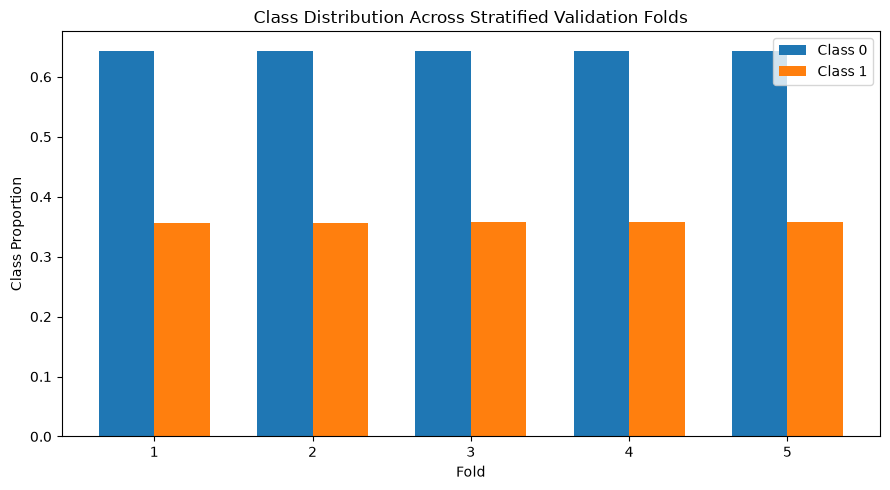

In [168]:
plt.figure(figsize=(9, 5))

x = np.arange(len(fold_class_distribution))
width = 0.35

plt.bar(
    x - width / 2,
    fold_class_distribution["Class 0"],
    width,
    label="Class 0"
)

plt.bar(
    x + width / 2,
    fold_class_distribution["Class 1"],
    width,
    label="Class 1"
)

plt.xlabel("Fold")
plt.ylabel("Class Proportion")
plt.title("Class Distribution Across Stratified Validation Folds")
plt.xticks(
    x,
    fold_class_distribution["Fold"]
)
plt.legend()
plt.tight_layout()
plt.show()

## 15.12 Visualize the Fold Assignment

We can also visualize which observations are used for training and validation in each fold.

A validation observation is represented separately from the observations used for training.

This helps build an intuitive understanding of how K-Fold Cross-Validation repeatedly reuses the training dataset while ensuring that each observation is eventually evaluated as validation data.


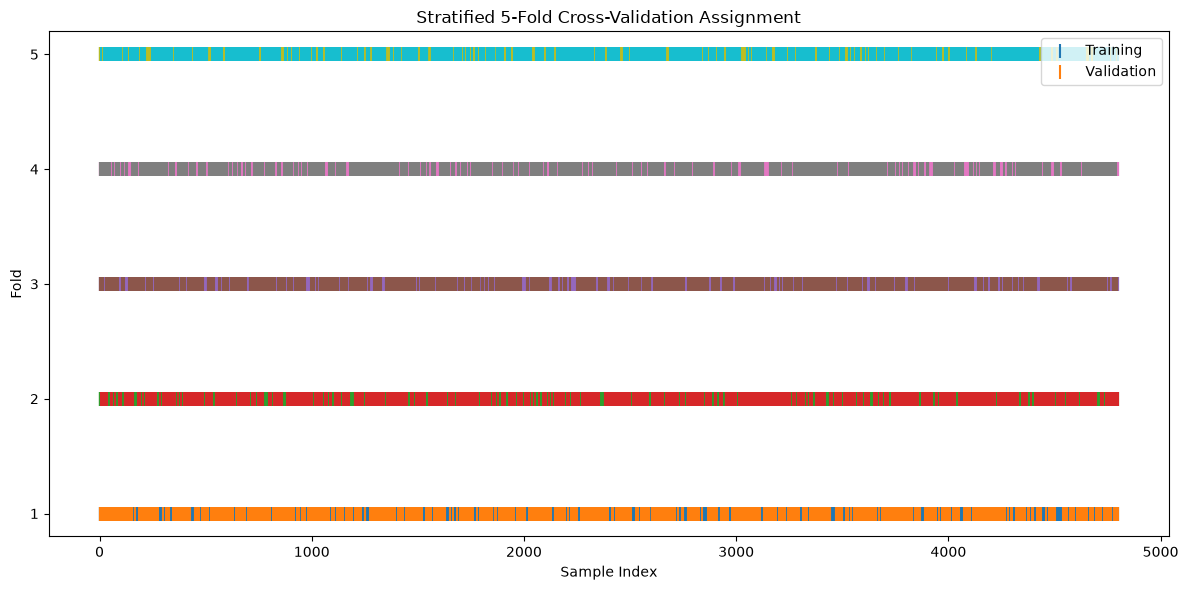

In [169]:
plt.figure(figsize=(12, 6))

for fold, (train_idx, valid_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):
    plt.scatter(
        train_idx,
        np.full(len(train_idx), fold),
        marker="|",
        s=100,
        label="Training" if fold == 1 else None
    )

    plt.scatter(
        valid_idx,
        np.full(len(valid_idx), fold),
        marker="|",
        s=100,
        label="Validation" if fold == 1 else None
    )

plt.xlabel("Sample Index")
plt.ylabel("Fold")
plt.title("Stratified 5-Fold Cross-Validation Assignment")
plt.legend()
plt.yticks(range(1, cv.n_splits + 1))
plt.tight_layout()
plt.show()

## 15.13 Build Leakage-Safe Model Pipelines

We now construct the classifiers that will be evaluated using the same cross-validation procedure.

A critical requirement is that preprocessing must be performed **inside the cross-validation loop**.

For models such as Logistic Regression and SVM, feature scaling is necessary because these algorithms are sensitive to feature magnitude.

For tree-based models, scaling is generally unnecessary.

Therefore, we will use:

* `StandardScaler + Logistic Regression`
* `StandardScaler + Linear SVM`
* `StandardScaler + RBF SVM`
* `Random Forest`
* `Gradient Boosting`
* `XGBoost`
* `LightGBM`

Using a `Pipeline` ensures that, during every fold, the scaler is fitted only on that fold's training data.

This prevents validation information from leaking into preprocessing.

The evaluation structure becomes:

$$
\boxed{
\text{Fold Training Data}
\rightarrow
\text{Fit Preprocessor}
\rightarrow
\text{Transform}
\rightarrow
\text{Fit Model}
\rightarrow
\text{Validation}
}
$$

rather than preprocessing the complete dataset before cross-validation.


In [170]:
models_for_cv = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="linear",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]),

    "RBF SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            C=2.0,
            gamma="scale",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=5,
        subsample=0.9,
        random_state=RANDOM_STATE
    ),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=2,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )
}

print("Models prepared for cross-validation:")

for model_name in models_for_cv:
    print("-", model_name)

Models prepared for cross-validation:
- Logistic Regression
- Linear SVM
- RBF SVM
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM


## 15.14 Define the Evaluation Metrics

A classifier should not be evaluated using only one metric.

Different metrics answer different questions.

We will therefore evaluate:

| Metric    | What it measures                                   |
| --------- | -------------------------------------------------- |
| Accuracy  | Overall fraction of correct predictions            |
| Precision | How many predicted positives are actually positive |
| Recall    | How many actual positives are detected             |
| F1        | Harmonic mean of precision and recall              |
| ROC-AUC   | Ranking/discrimination ability                     |
| PR-AUC    | Precision-Recall performance across thresholds     |

For a binary classifier:

$$
\text{Accuracy}
=
\frac{TP+TN}{TP+TN+FP+FN}
$$

$$
\text{Precision}
=
\frac{TP}{TP+FP}
$$

$$
\text{Recall}
=
\frac{TP}{TP+FN}
$$

$$
F_1
=
2
\frac{
\text{Precision}\cdot\text{Recall}
}{
\text{Precision}+\text{Recall}
}
$$

ROC-AUC and PR-AUC do not depend on selecting a single classification threshold, making them useful for comparing the underlying ranking quality of probabilistic classifiers.

We will use the same metrics for every model so that the comparison is consistent.


In [171]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

print("Evaluation metrics:")
for metric in scoring:
    print("-", metric)

Evaluation metrics:
- accuracy
- precision
- recall
- f1
- roc_auc
- pr_auc


## 15.15 Run Stratified 5-Fold Cross-Validation

We can now perform the actual model comparison.

For each classifier:

1. The training data is divided into five stratified folds.
2. The model is trained four times on four folds.
3. Each remaining fold is used for validation.
4. The process is repeated until every fold has been used for validation.
5. All evaluation metrics are recorded.

We will also record training scores.

This allows us to later examine the **generalization gap** between training and validation performance.

The test set remains untouched during this process.

> **Methodological note:** Earlier sections used the test set for demonstrations such as threshold analysis and learning curves. Those experiments were educational demonstrations. For a clean real-world experiment, model selection should be completed before evaluating the final test set.


In [172]:
from sklearn.model_selection import cross_validate

cv_results = []

for model_name, model in models_for_cv.items():

    print(f"Evaluating: {model_name}")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=1
    )

    result = {
        "Model": model_name
    }

    for metric in scoring:
        result[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        result[f"{metric}_std"] = scores[f"test_{metric}"].std()

        result[f"{metric}_train_mean"] = (
            scores[f"train_{metric}"].mean()
        )

    cv_results.append(result)

cv_results = pd.DataFrame(cv_results)

cv_results

Evaluating: Logistic Regression
Evaluating: Linear SVM
Evaluating: RBF SVM
Evaluating: Random Forest
Evaluating: Gradient Boosting
Evaluating: XGBoost
Evaluating: LightGBM


,Model,accuracy_mean,accuracy_std,accuracy_train_mean,precision_mean,precision_std,precision_train_mean,recall_mean,recall_std,recall_train_mean,f1_mean,f1_std,f1_train_mean,roc_auc_mean,roc_auc_std,roc_auc_train_mean,pr_auc_mean,pr_auc_std,pr_auc_train_mean
0,Logistic Regression,0.689375,0.004723,0.696406,0.602024,0.013425,0.616174,0.384103,0.018403,0.395944,0.468579,0.012591,0.482068,0.727671,0.011074,0.733317,0.573248,0.018775,0.577664
1,Linear SVM,0.702083,0.009387,0.705417,0.657000,0.034099,0.664138,0.349084,0.019709,0.353182,0.455223,0.017128,0.460911,0.718159,0.012453,0.724948,0.596336,0.012468,0.606342
2,RBF SVM,0.881458,0.005606,0.925365,0.884003,0.008482,0.933038,0.768823,0.017200,0.852014,0.822264,0.009915,0.890684,0.936340,0.003362,0.972631,0.903089,0.005526,0.956892
3,Random Forest,0.894792,0.005393,1.000000,0.890960,0.015170,1.000000,0.803848,0.005202,1.000000,0.845086,0.006903,1.000000,0.947109,0.003180,1.000000,0.919223,0.007593,1.000000
4,Gradient Boosting,0.867917,0.013524,0.916823,0.861060,0.021689,0.922782,0.751339,0.026074,0.836981,0.802266,0.021237,0.877773,0.926216,0.001311,0.968398,0.887609,0.012457,0.952878
5,XGBoost,0.893333,0.007867,0.978333,0.885229,0.012710,0.987142,0.805609,0.011953,0.951693,0.843521,0.011515,0.969088,0.941989,0.002133,0.998063,0.915992,0.009129,0.996701
6,LightGBM,0.898750,0.008498,1.000000,0.896959,0.018879,1.000000,0.809694,0.014057,1.000000,0.850948,0.011948,1.000000,0.949320,0.003784,1.000000,0.927513,0.008282,1.000000


## 15.16 Cross-Validation Summary

The raw cross-validation results contain both training and validation statistics.

For model comparison, we first create a compact table containing the mean validation performance.

Higher values are better for all metrics shown below.


In [173]:
cv_summary = cv_results[
    [
        "Model",
        "accuracy_mean",
        "precision_mean",
        "recall_mean",
        "f1_mean",
        "roc_auc_mean",
        "pr_auc_mean"
    ]
].copy()

cv_summary = cv_summary.sort_values(
    "roc_auc_mean",
    ascending=False
).reset_index(drop=True)

cv_summary

,Model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,pr_auc_mean
0,LightGBM,0.898750,0.896959,0.809694,0.850948,0.949320,0.927513
1,Random Forest,0.894792,0.890960,0.803848,0.845086,0.947109,0.919223
2,XGBoost,0.893333,0.885229,0.805609,0.843521,0.941989,0.915992
3,RBF SVM,0.881458,0.884003,0.768823,0.822264,0.936340,0.903089
4,Gradient Boosting,0.867917,0.861060,0.751339,0.802266,0.926216,0.887609
5,Logistic Regression,0.689375,0.602024,0.384103,0.468579,0.727671,0.573248
6,Linear SVM,0.702083,0.657000,0.349084,0.455223,0.718159,0.596336


## 15.17 Mean and Standard Deviation

The mean alone does not tell the complete story.

A model that achieves:

$$
0.93\pm0.01
$$

is behaving differently from a model that achieves:

$$
0.93\pm0.08.
$$

Both have the same average score, but the second model is considerably less stable across folds.

We therefore report the main metrics as:

$$
\boxed{\text{Mean}\pm\text{Standard Deviation}}
$$


In [174]:
cv_report = cv_results[["Model"]].copy()

cv_report["Accuracy"] = (
    cv_results["accuracy_mean"].round(4).astype(str)
    + " ± "
    + cv_results["accuracy_std"].round(4).astype(str)
)

cv_report["Precision"] = (
    cv_results["precision_mean"].round(4).astype(str)
    + " ± "
    + cv_results["precision_std"].round(4).astype(str)
)

cv_report["Recall"] = (
    cv_results["recall_mean"].round(4).astype(str)
    + " ± "
    + cv_results["recall_std"].round(4).astype(str)
)

cv_report["F1"] = (
    cv_results["f1_mean"].round(4).astype(str)
    + " ± "
    + cv_results["f1_std"].round(4).astype(str)
)

cv_report["ROC-AUC"] = (
    cv_results["roc_auc_mean"].round(4).astype(str)
    + " ± "
    + cv_results["roc_auc_std"].round(4).astype(str)
)

cv_report["PR-AUC"] = (
    cv_results["pr_auc_mean"].round(4).astype(str)
    + " ± "
    + cv_results["pr_auc_std"].round(4).astype(str)
)

cv_report = cv_report.sort_values(
    "Model"
).reset_index(drop=True)

cv_report

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Gradient Boosting,0.8679 ± 0.0135,0.8611 ± 0.0217,0.7513 ± 0.0261,0.8023 ± 0.0212,0.9262 ± 0.0013,0.8876 ± 0.0125
1,LightGBM,0.8988 ± 0.0085,0.897 ± 0.0189,0.8097 ± 0.0141,0.8509 ± 0.0119,0.9493 ± 0.0038,0.9275 ± 0.0083
2,Linear SVM,0.7021 ± 0.0094,0.657 ± 0.0341,0.3491 ± 0.0197,0.4552 ± 0.0171,0.7182 ± 0.0125,0.5963 ± 0.0125
3,Logistic Regression,0.6894 ± 0.0047,0.602 ± 0.0134,0.3841 ± 0.0184,0.4686 ± 0.0126,0.7277 ± 0.0111,0.5732 ± 0.0188
4,RBF SVM,0.8815 ± 0.0056,0.884 ± 0.0085,0.7688 ± 0.0172,0.8223 ± 0.0099,0.9363 ± 0.0034,0.9031 ± 0.0055
5,Random Forest,0.8948 ± 0.0054,0.891 ± 0.0152,0.8038 ± 0.0052,0.8451 ± 0.0069,0.9471 ± 0.0032,0.9192 ± 0.0076
6,XGBoost,0.8933 ± 0.0079,0.8852 ± 0.0127,0.8056 ± 0.012,0.8435 ± 0.0115,0.942 ± 0.0021,0.916 ± 0.0091


## 15.18 Visualize Cross-Validation Performance

The summary table gives us the numerical results, but visualization makes model differences easier to identify.

We will visualize the mean cross-validation score together with its standard deviation.

The error bars represent:

$$
\bar{s}\pm s_{\text{std}}
$$

A model with a high mean score and relatively small variability is generally more attractive than a model with similar performance but substantially greater variability.

We begin with ROC-AUC because it provides a threshold-independent measure of discrimination.


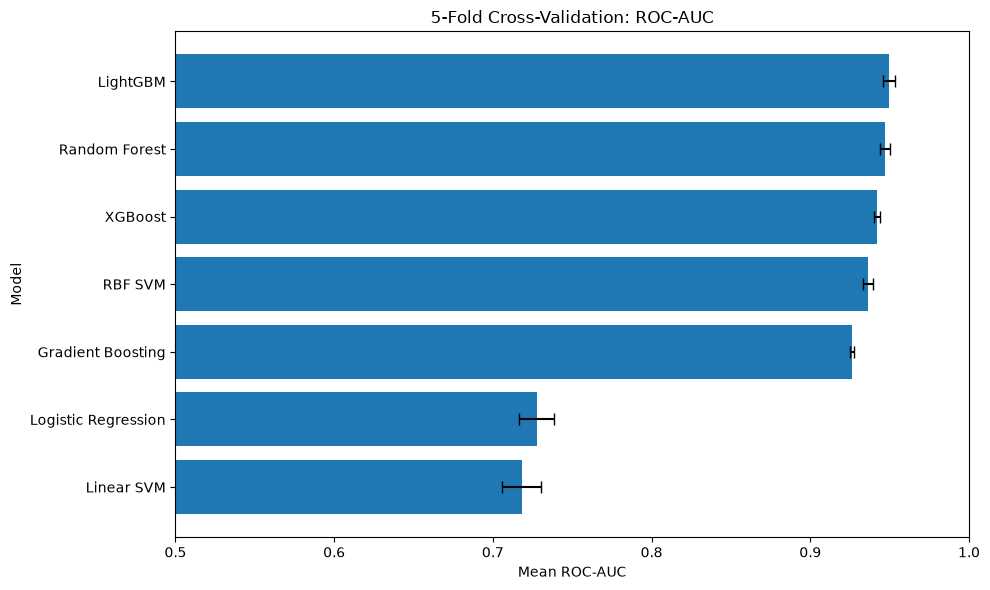

In [175]:
roc_plot_data = cv_results.sort_values(
    "roc_auc_mean",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    roc_plot_data["Model"],
    roc_plot_data["roc_auc_mean"],
    xerr=roc_plot_data["roc_auc_std"],
    capsize=4
)

plt.xlabel("Mean ROC-AUC")
plt.ylabel("Model")
plt.title("5-Fold Cross-Validation: ROC-AUC")
plt.xlim(0.5, 1.0)

plt.tight_layout()
plt.show()

## 15.19 Visualize PR-AUC

ROC-AUC can sometimes provide an overly optimistic impression when the positive class is relatively uncommon.

PR-AUC focuses directly on the relationship between:

* Precision
* Recall

Therefore, it provides another useful perspective on classifier quality.

We compare the same models using mean PR-AUC and its fold-to-fold standard deviation.


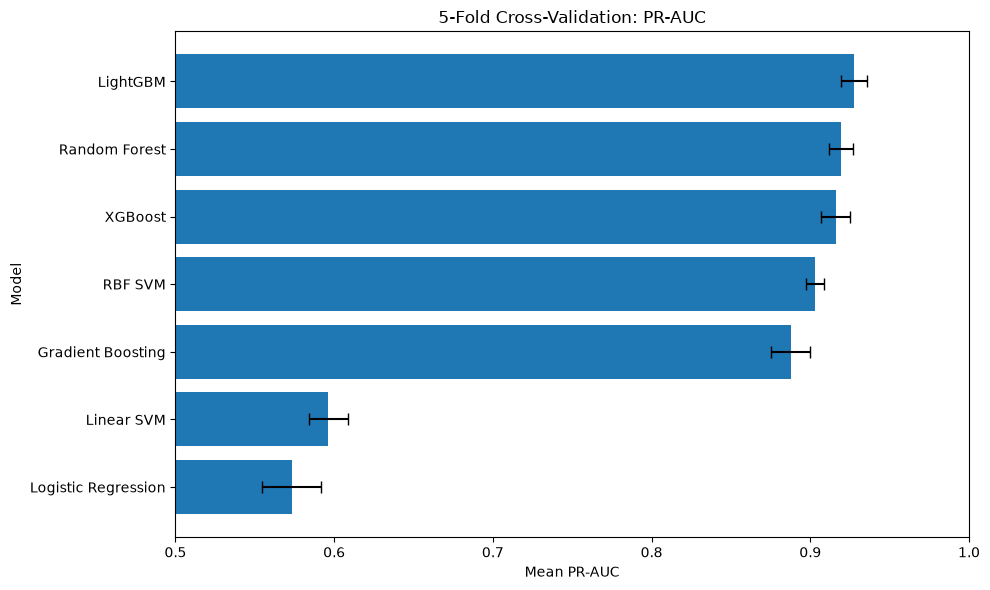

In [176]:
pr_plot_data = cv_results.sort_values(
    "pr_auc_mean",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    pr_plot_data["Model"],
    pr_plot_data["pr_auc_mean"],
    xerr=pr_plot_data["pr_auc_std"],
    capsize=4
)

plt.xlabel("Mean PR-AUC")
plt.ylabel("Model")
plt.title("5-Fold Cross-Validation: PR-AUC")
plt.xlim(0.5, 1.0)

plt.tight_layout()
plt.show()

## 15.20 Compare F1 Scores

ROC-AUC and PR-AUC evaluate ranking quality across thresholds.

F1 evaluates classification performance at the model's default decision threshold.

Therefore, it is useful to compare F1 separately.

A model with excellent ROC-AUC does not necessarily have the best F1 score at a particular threshold.

This distinction reinforces an important idea:

$$
\boxed{
\text{Ranking Performance}
\neq
\text{Decision Performance}
}
$$


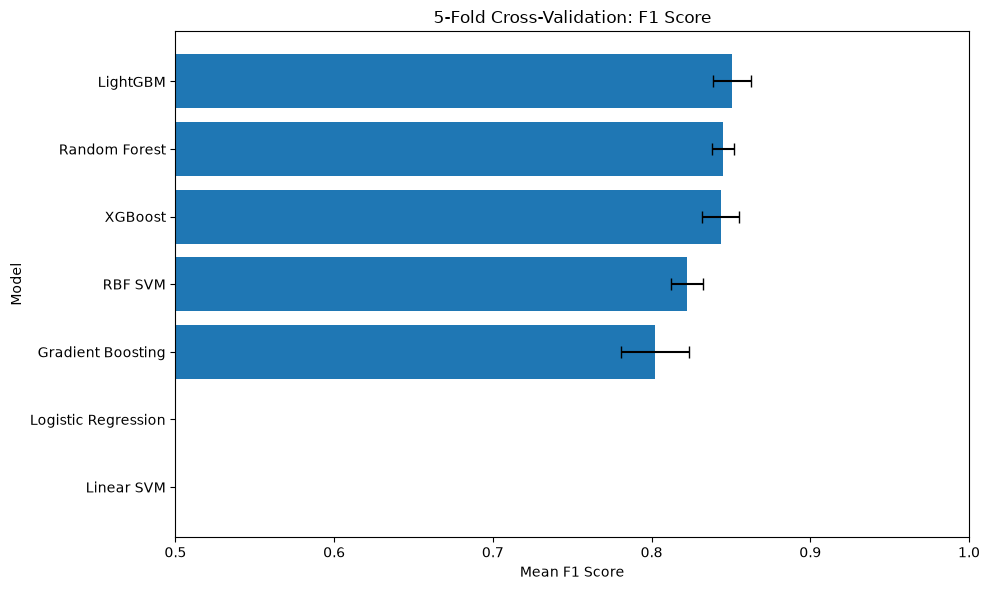

In [177]:
f1_plot_data = cv_results.sort_values(
    "f1_mean",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    f1_plot_data["Model"],
    f1_plot_data["f1_mean"],
    xerr=f1_plot_data["f1_std"],
    capsize=4
)

plt.xlabel("Mean F1 Score")
plt.ylabel("Model")
plt.title("5-Fold Cross-Validation: F1 Score")
plt.xlim(0.5, 1.0)

plt.tight_layout()
plt.show()

## 15.21 Multi-Metric Model Comparison

A single metric can hide important differences between classifiers.

We therefore compare the mean values of:

* Accuracy
* Precision
* Recall
* F1
* ROC-AUC
* PR-AUC

This provides a broader view of model behavior.


In [178]:
metric_comparison = cv_results.set_index("Model")[
    [
        "accuracy_mean",
        "precision_mean",
        "recall_mean",
        "f1_mean",
        "roc_auc_mean",
        "pr_auc_mean"
    ]
].copy()

metric_comparison.columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

metric_comparison

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
Logistic Regression,0.689375,0.602024,0.384103,0.468579,0.727671,0.573248
Linear SVM,0.702083,0.657000,0.349084,0.455223,0.718159,0.596336
RBF SVM,0.881458,0.884003,0.768823,0.822264,0.936340,0.903089
Random Forest,0.894792,0.890960,0.803848,0.845086,0.947109,0.919223
Gradient Boosting,0.867917,0.861060,0.751339,0.802266,0.926216,0.887609
XGBoost,0.893333,0.885229,0.805609,0.843521,0.941989,0.915992
LightGBM,0.898750,0.896959,0.809694,0.850948,0.949320,0.927513


## 15.22 Multi-Metric Visualization

We can visualize the complete metric profile of each model.

Because all of these metrics lie between 0 and 1, they can be compared on the same scale.

This visualization is not intended to produce a single universal winner. Instead, it helps identify trade-offs between different performance objectives.


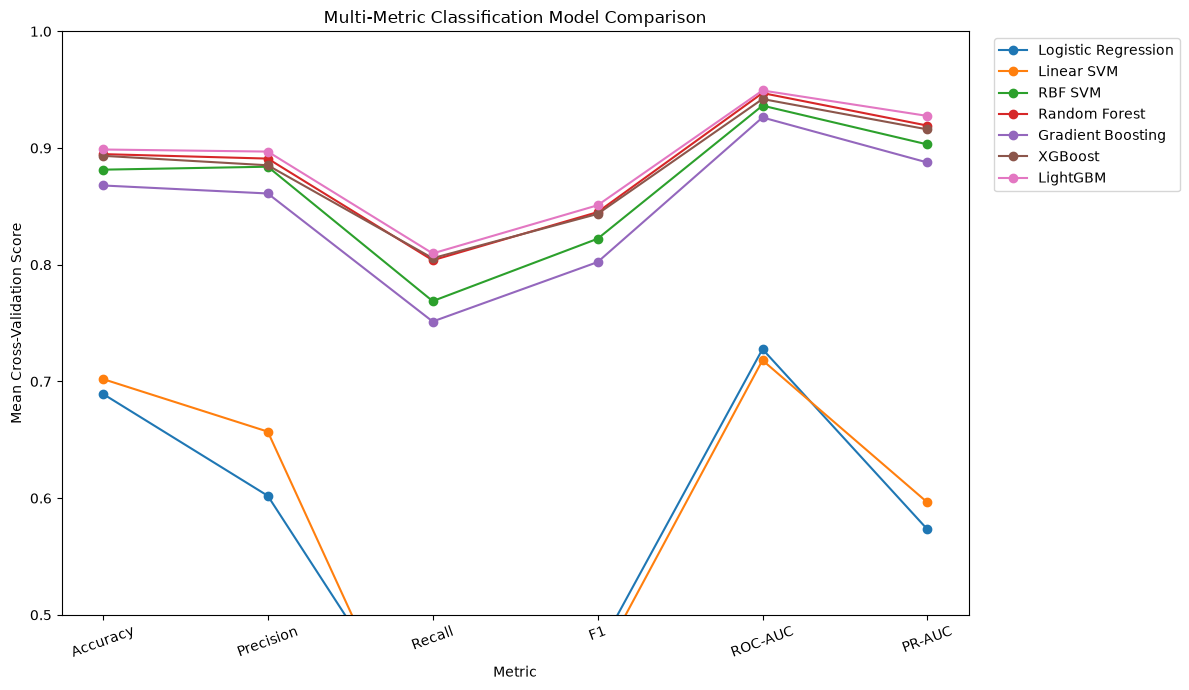

In [179]:
plt.figure(figsize=(12, 7))

for model_name in metric_comparison.index:
    plt.plot(
        metric_comparison.columns,
        metric_comparison.loc[model_name],
        marker="o",
        label=model_name
    )

plt.ylim(0.5, 1.0)
plt.xlabel("Metric")
plt.ylabel("Mean Cross-Validation Score")
plt.title("Multi-Metric Classification Model Comparison")
plt.xticks(rotation=20)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 15.23 Interpreting the Cross-Validation Results

At this stage, we should not immediately declare one model to be the winner.

Instead, examine several properties.

### 1. Mean Performance

A larger mean score generally indicates better average validation performance.

### 2. Variability

A smaller standard deviation indicates more consistent performance across folds.

### 3. Metric Trade-Offs

A model can have:

* high precision but lower recall
* high recall but lower precision
* strong ROC-AUC but weaker F1
* strong PR-AUC but lower accuracy

Therefore, the appropriate model depends on the application.

### 4. Generalization

A model that performs extremely well on its training folds but substantially worse on validation folds may be overfitting.

We will investigate this next.

The goal is therefore not simply:

$$
\max \text{Validation Score}
$$

but rather:

$$
\boxed{
\text{High Performance}
+
\text{Low Variability}
+
\text{Good Generalization}
}
$$

A final model should ultimately be selected according to the actual objective of the classification problem.


## 15.24 Fold-by-Fold Performance and Model Stability

The mean and standard deviation summarize cross-validation performance, but they hide the individual fold results.

For example, two models could both achieve:

$$
\text{Mean ROC-AUC}=0.92
$$

while having very different fold-level behavior:

```text
Model A → 0.91, 0.92, 0.92, 0.93, 0.92
Model B → 0.80, 0.96, 0.94, 0.99, 0.91
```

Both have a similar average, but Model A is considerably more stable.

Therefore, we should inspect the individual validation scores produced by each fold.


In [180]:
fold_roc_auc_results = []

for model_name, model in models_for_cv.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=1
    )

    for fold_number, score in enumerate(
        scores["test_score"],
        start=1
    ):
        fold_roc_auc_results.append({
            "Model": model_name,
            "Fold": fold_number,
            "ROC-AUC": score
        })

fold_roc_auc_results = pd.DataFrame(
    fold_roc_auc_results
)

fold_roc_auc_results

,Model,Fold,ROC-AUC
0,Logistic Regression,1,0.724328
1,Logistic Regression,2,0.734841
2,Logistic Regression,3,0.745226
3,Logistic Regression,4,0.714352
4,Logistic Regression,5,0.719606
5,Linear SVM,1,0.704782
6,Linear SVM,2,0.722544
7,Linear SVM,3,0.740156
8,Linear SVM,4,0.709561
9,Linear SVM,5,0.713752


## 15.25 Inspect Fold-Level Scores

We can transform the results into a matrix where:

* Rows represent models.
* Columns represent validation folds.
* Values represent ROC-AUC.

This makes differences in stability easier to inspect.


In [181]:
fold_roc_auc_table = fold_roc_auc_results.pivot(
    index="Model",
    columns="Fold",
    values="ROC-AUC"
)

fold_roc_auc_table

Fold,1,2,3,4,5
Model,,,,,
Gradient Boosting,0.925836,0.928542,0.925224,0.926632,0.924846
LightGBM,0.950605,0.943560,0.953187,0.952913,0.946336
Linear SVM,0.704782,0.722544,0.740156,0.709561,0.713752
Logistic Regression,0.724328,0.734841,0.745226,0.714352,0.719606
RBF SVM,0.934012,0.932890,0.942570,0.935737,0.936489
Random Forest,0.943439,0.943049,0.949672,0.949105,0.950281
XGBoost,0.942561,0.938350,0.943898,0.944129,0.941006


## 15.26 Visualize Fold-Level ROC-AUC

The following visualization shows how each model performs on each validation fold.

A model whose points remain close together has relatively stable performance.

A model with large fluctuations may be more sensitive to the particular observations contained in each fold.


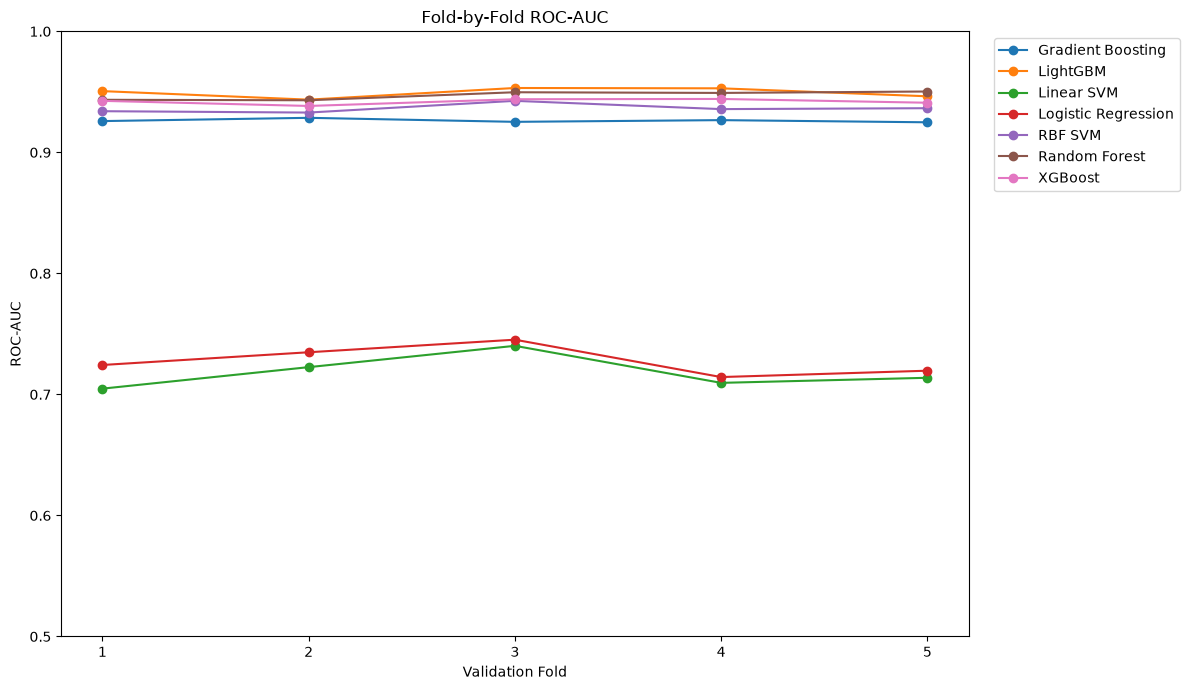

In [182]:
plt.figure(figsize=(12, 7))

for model_name in fold_roc_auc_table.index:
    plt.plot(
        fold_roc_auc_table.columns,
        fold_roc_auc_table.loc[model_name],
        marker="o",
        label=model_name
    )

plt.xlabel("Validation Fold")
plt.ylabel("ROC-AUC")
plt.title("Fold-by-Fold ROC-AUC")
plt.xticks(range(1, cv.n_splits + 1))
plt.ylim(0.5, 1.0)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 15.27 Measure Model Stability

We can quantify stability using the standard deviation of the validation scores.

For model $m$:

$$
\text{Stability Variability}_m
=
\operatorname{std}
(s_{m,1},s_{m,2},\ldots,s_{m,K})
$$

A smaller value means the model's performance varies less across folds.

We will combine the mean and standard deviation into a compact stability table.


In [183]:
stability_summary = (
    fold_roc_auc_results
    .groupby("Model")["ROC-AUC"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

stability_summary["Range"] = (
    stability_summary["max"]
    - stability_summary["min"]
)

stability_summary = stability_summary.sort_values(
    "mean",
    ascending=False
)

stability_summary

,Model,mean,std,min,max,Range
1,LightGBM,0.949320,0.004231,0.943560,0.953187,0.009628
5,Random Forest,0.947109,0.003556,0.943049,0.950281,0.007233
6,XGBoost,0.941989,0.002385,0.938350,0.944129,0.005779
4,RBF SVM,0.936340,0.003759,0.932890,0.942570,0.009679
0,Gradient Boosting,0.926216,0.001466,0.924846,0.928542,0.003697
3,Logistic Regression,0.727671,0.012382,0.714352,0.745226,0.030874
2,Linear SVM,0.718159,0.013923,0.704782,0.740156,0.035374


## 15.28 Visualize Performance Range

The range:

$$
\text{Range}
=
s_{\max}-s_{\min}
$$

provides another simple measure of how much the model's performance changes between its best and worst folds.

A smaller range indicates greater consistency.

However, range should not be interpreted in isolation because it is strongly affected by the number of folds.


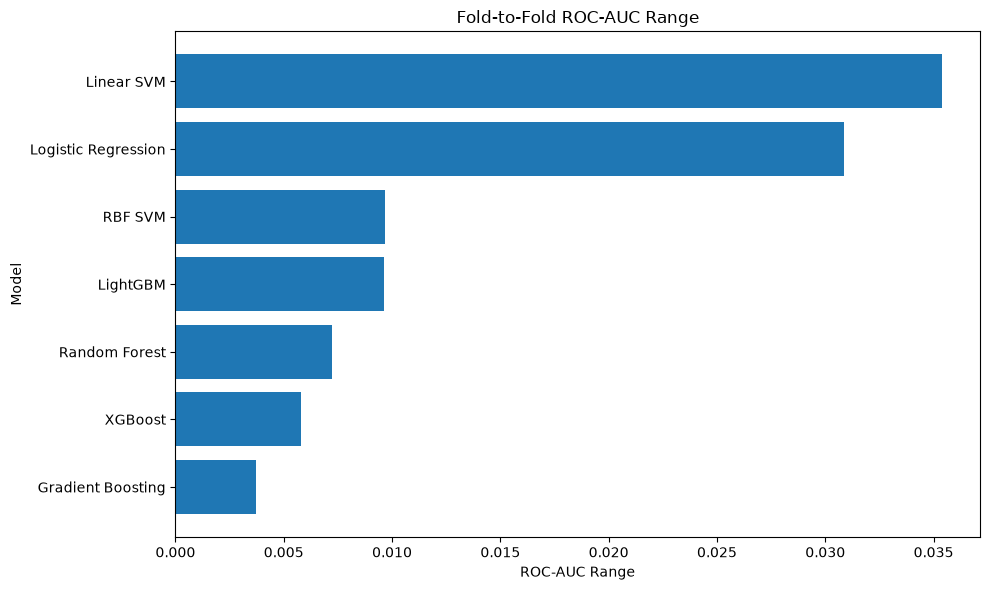

In [184]:
range_plot = stability_summary.sort_values(
    "Range",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    range_plot["Model"],
    range_plot["Range"]
)

plt.xlabel("ROC-AUC Range")
plt.ylabel("Model")
plt.title("Fold-to-Fold ROC-AUC Range")
plt.tight_layout()
plt.show()

## 15.29 Mean Performance vs Stability

A useful way to think about model comparison is to consider two dimensions simultaneously:

$$
\text{Model Quality}
\approx
\text{High Mean Performance}
+
\text{Low Variability}
$$

We can visualize this relationship by placing:

* Mean ROC-AUC on the x-axis
* ROC-AUC standard deviation on the y-axis

The ideal region is generally toward:

* higher mean ROC-AUC
* lower standard deviation


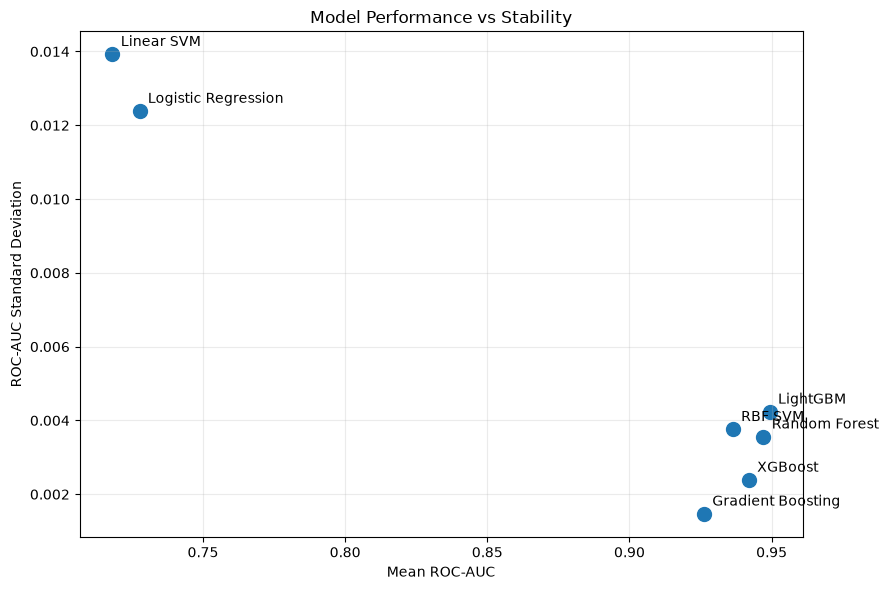

In [185]:
plt.figure(figsize=(9, 6))

plt.scatter(
    stability_summary["mean"],
    stability_summary["std"],
    s=100
)

for _, row in stability_summary.iterrows():
    plt.annotate(
        row["Model"],
        (
            row["mean"],
            row["std"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Mean ROC-AUC")
plt.ylabel("ROC-AUC Standard Deviation")
plt.title("Model Performance vs Stability")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 15.30 Interpretation of Model Stability

The previous analysis gives us a more complete picture of model performance.

Consider two hypothetical models:

$$
M_A: 0.94\pm0.01
$$

and

$$
M_B: 0.95\pm0.08.
$$

Model $B$ has a higher mean score, but its performance is considerably more variable.

Depending on the application, Model $A$ may be preferable because its behavior is more predictable.

This does **not** mean that lower variance is always more important than higher performance.

Instead, model selection should consider:

$$
\boxed{
\text{Performance}
+
\text{Stability}
+
\text{Application Requirements}
}
$$

Cross-validation therefore gives us more information than a single validation score.

It allows us to ask not only:

> How well does the model perform?

but also:

> How consistently does the model perform?

The next question is whether the models are **overfitting**. We can investigate this by comparing their training and validation performance.


## 15.31 Training vs Validation Performance

Cross-validation gives us an estimate of validation performance, but we can learn more by comparing it with the model's training performance.

This helps us identify possible **overfitting**.

For a metric $S$, define the generalization gap as:

$$
\text{Generalization Gap}
=
S_{\text{train}}
-
S_{\text{validation}}
$$

A large positive gap means that the model performs substantially better on its training data than on unseen validation data.

Conceptually:

```text
Underfitting

Training Performance   ────────
Validation Performance ────────
        Small gap
        Both relatively low
```

```text
Good Generalization

Training Performance   ───────────
Validation Performance ─────────
        Small gap
        Both relatively high
```

```text
Overfitting

Training Performance   ───────────────
Validation Performance ───────
        Large gap
```

The gap is not a complete diagnostic by itself. We must consider the absolute validation performance as well.


In [186]:
generalization_gap = cv_results[
    [
        "Model",
        "roc_auc_train_mean",
        "roc_auc_mean"
    ]
].copy()

generalization_gap["ROC-AUC Gap"] = (
    generalization_gap["roc_auc_train_mean"]
    - generalization_gap["roc_auc_mean"]
)

generalization_gap = generalization_gap.sort_values(
    "ROC-AUC Gap",
    ascending=False
).reset_index(drop=True)

generalization_gap

,Model,roc_auc_train_mean,roc_auc_mean,ROC-AUC Gap
0,XGBoost,0.998063,0.941989,0.056074
1,Random Forest,1.000000,0.947109,0.052891
2,LightGBM,1.000000,0.949320,0.050680
3,Gradient Boosting,0.968398,0.926216,0.042182
4,RBF SVM,0.972631,0.936340,0.036291
5,Linear SVM,0.724948,0.718159,0.006789
6,Logistic Regression,0.733317,0.727671,0.005646


## 15.32 Training vs Validation ROC-AUC

We can directly compare the mean training and validation ROC-AUC for every classifier.

A large separation between the two indicates that the model may have difficulty generalizing beyond the observations used to fit it.


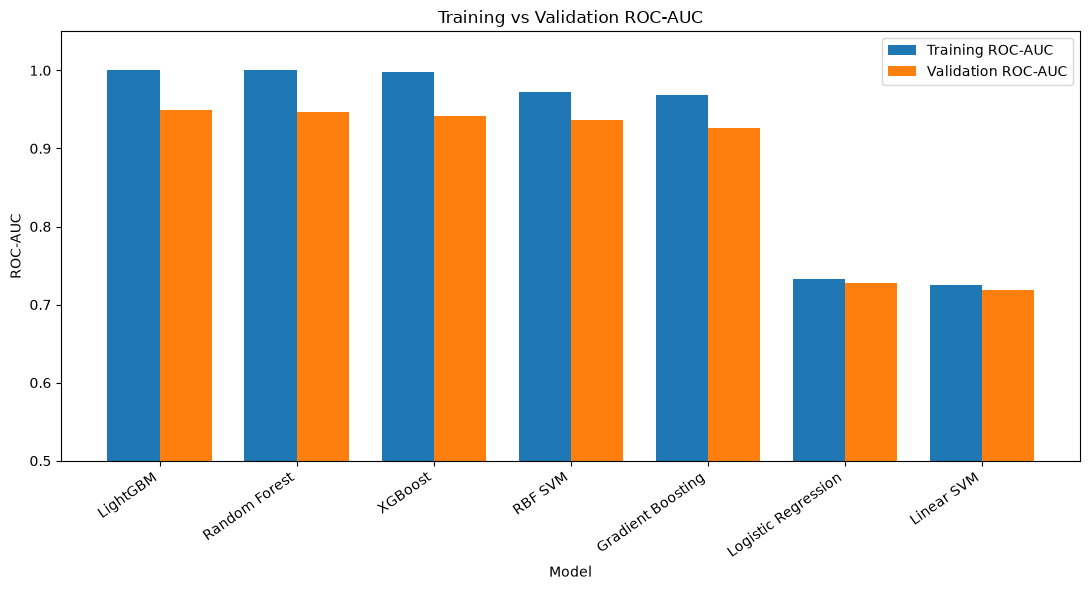

In [187]:
comparison_generalization = cv_results[
    [
        "Model",
        "roc_auc_train_mean",
        "roc_auc_mean"
    ]
].sort_values(
    "roc_auc_mean",
    ascending=False
)

x = np.arange(len(comparison_generalization))
width = 0.38

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    comparison_generalization["roc_auc_train_mean"],
    width,
    label="Training ROC-AUC"
)

plt.bar(
    x + width / 2,
    comparison_generalization["roc_auc_mean"],
    width,
    label="Validation ROC-AUC"
)

plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.title("Training vs Validation ROC-AUC")
plt.xticks(
    x,
    comparison_generalization["Model"],
    rotation=35,
    ha="right"
)
plt.ylim(0.5, 1.05)
plt.legend()

plt.tight_layout()
plt.show()

## 15.33 Generalization Gap

We can now directly visualize the difference between training and validation ROC-AUC.

$$
\Delta_{\text{generalization}}
=
S_{\text{train}}
-
S_{\text{validation}}
$$

A larger positive value indicates a larger difference between training and validation performance.


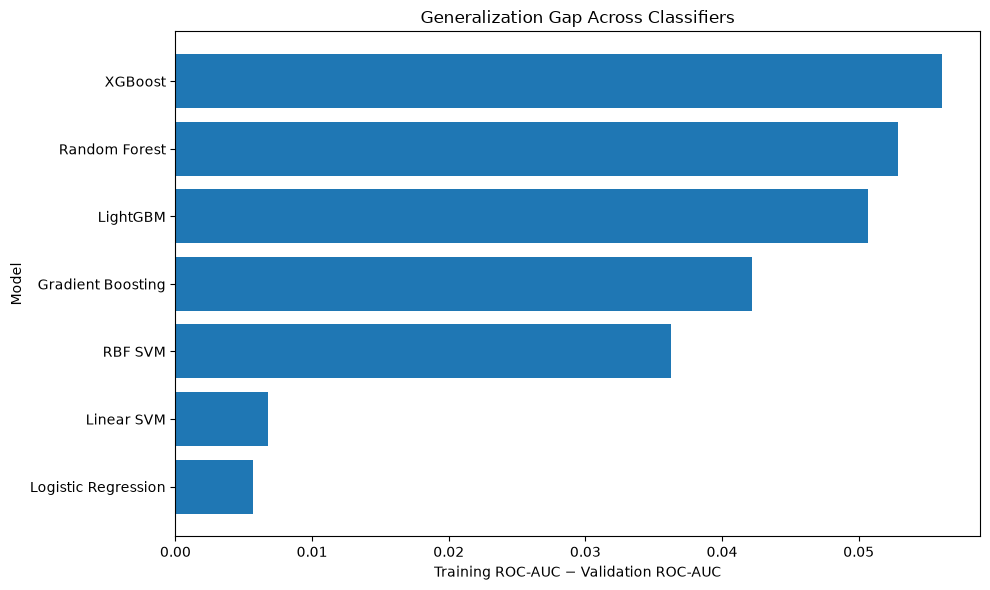

In [188]:
gap_plot = generalization_gap.sort_values(
    "ROC-AUC Gap",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    gap_plot["Model"],
    gap_plot["ROC-AUC Gap"]
)

plt.xlabel("Training ROC-AUC − Validation ROC-AUC")
plt.ylabel("Model")
plt.title("Generalization Gap Across Classifiers")

plt.tight_layout()
plt.show()

## 15.34 Identify Potential Overfitting

A large training-validation gap can be an indication of overfitting.

However, we should avoid using an arbitrary rule such as:

$$
\text{Gap}>0.05
\Rightarrow
\text{Overfitting}.
$$

There is no universal threshold that applies to every dataset and model.

Instead, we should examine three quantities together:

1. Training performance
2. Validation performance
3. Validation variability

For example:

$$
\text{High Training}
+
\text{Low Validation}
+
\text{High Variance}
$$

is stronger evidence of a generalization problem than a large training-validation gap alone.

Conversely:

$$
\text{High Training}
+
\text{High Validation}
+
\text{Low Variance}
$$

is generally a more desirable pattern.

Therefore, cross-validation should be interpreted as a collection of evidence rather than a single number.


## 15.35 F1 Generalization Gap

The same analysis can be performed for F1.

This is useful because ROC-AUC evaluates ranking performance, whereas F1 evaluates the balance between precision and recall at the classifier's decision threshold.


In [189]:
f1_gap = cv_results[
    [
        "Model",
        "f1_train_mean",
        "f1_mean"
    ]
].copy()

f1_gap["F1 Gap"] = (
    f1_gap["f1_train_mean"]
    - f1_gap["f1_mean"]
)

f1_gap = f1_gap.sort_values(
    "F1 Gap",
    ascending=False
)

f1_gap

,Model,f1_train_mean,f1_mean,F1 Gap
3,Random Forest,1.000000,0.845086,0.154914
6,LightGBM,1.000000,0.850948,0.149052
5,XGBoost,0.969088,0.843521,0.125566
4,Gradient Boosting,0.877773,0.802266,0.075508
2,RBF SVM,0.890684,0.822264,0.068420
0,Logistic Regression,0.482068,0.468579,0.013489
1,Linear SVM,0.460911,0.455223,0.005688


## 15.36 Visualize F1 Generalization

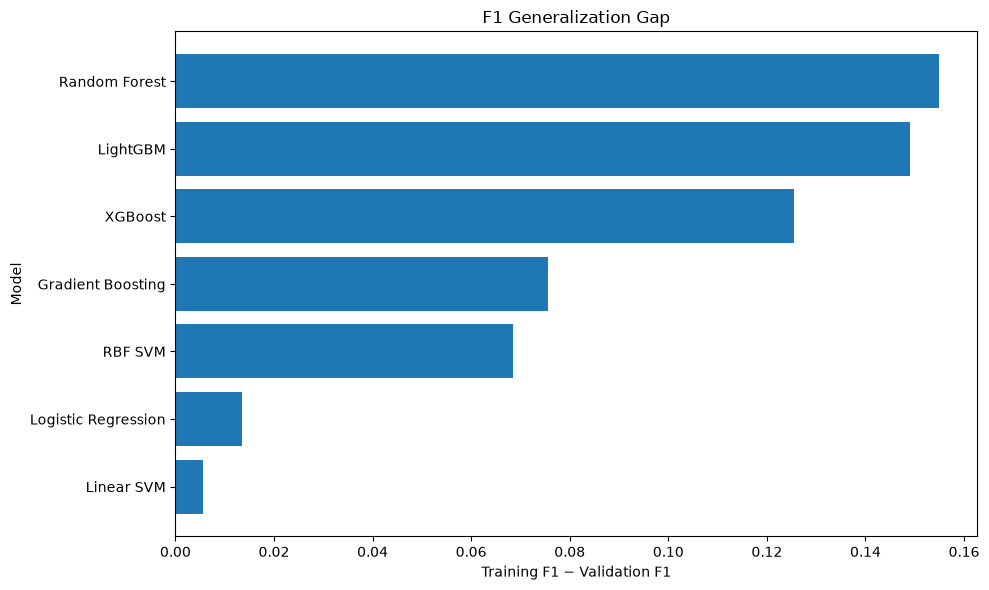

In [190]:
plt.figure(figsize=(10, 6))

plot_data = f1_gap.sort_values(
    "F1 Gap",
    ascending=True
)

plt.barh(
    plot_data["Model"],
    plot_data["F1 Gap"]
)

plt.xlabel("Training F1 − Validation F1")
plt.ylabel("Model")
plt.title("F1 Generalization Gap")

plt.tight_layout()
plt.show()

## 15.37 Generalization Analysis Summary

We have now evaluated the classifiers from three complementary perspectives:

### Average performance

$$
\bar{s}
=
\frac{1}{K}
\sum_{k=1}^{K}s_k
$$

This tells us how well the model performs on average.

### Stability

$$
s_{\text{std}}
=
\sqrt{
\frac{1}{K-1}
\sum_{k=1}^{K}
(s_k-\bar{s})^2
}
$$

This tells us how much performance varies between folds.

### Generalization

$$
\Delta
=
S_{\text{train}}
-
S_{\text{validation}}
$$

This tells us how much performance decreases when moving from training observations to unseen validation observations.

Together:

$$
\boxed{
\text{Robust Evaluation}
=
\text{Mean Performance}
+
\text{Variability}
+
\text{Generalization}
}
$$

This is substantially more informative than evaluating a classifier using one test score.

In the next step, we will use these results to **rank the classifiers across multiple metrics** and determine whether one model consistently performs well or whether different models are preferable under different objectives.


## 15.38 Multi-Metric Model Ranking

We have now measured each classifier using several complementary metrics.

A model may perform well according to one metric but not another.

For example:

* Accuracy may favor one model.
* Recall may favor another.
* F1 may favor another.
* ROC-AUC may favor another.
* PR-AUC may provide yet another ranking.

Therefore, model selection should not automatically be based on a single metric.

We will first calculate the ranking of every model for each major metric.

For all metrics considered here, a larger value represents better performance.


In [191]:
ranking_results = cv_results[
    [
        "Model",
        "accuracy_mean",
        "precision_mean",
        "recall_mean",
        "f1_mean",
        "roc_auc_mean",
        "pr_auc_mean"
    ]
].copy()

ranking_results["Accuracy Rank"] = (
    ranking_results["accuracy_mean"]
    .rank(ascending=False, method="min")
)

ranking_results["Precision Rank"] = (
    ranking_results["precision_mean"]
    .rank(ascending=False, method="min")
)

ranking_results["Recall Rank"] = (
    ranking_results["recall_mean"]
    .rank(ascending=False, method="min")
)

ranking_results["F1 Rank"] = (
    ranking_results["f1_mean"]
    .rank(ascending=False, method="min")
)

ranking_results["ROC-AUC Rank"] = (
    ranking_results["roc_auc_mean"]
    .rank(ascending=False, method="min")
)

ranking_results["PR-AUC Rank"] = (
    ranking_results["pr_auc_mean"]
    .rank(ascending=False, method="min")
)

ranking_results

,Model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,pr_auc_mean,Accuracy Rank,Precision Rank,Recall Rank,F1 Rank,ROC-AUC Rank,PR-AUC Rank
0,Logistic Regression,0.689375,0.602024,0.384103,0.468579,0.727671,0.573248,7.0,7.0,6.0,6.0,6.0,7.0
1,Linear SVM,0.702083,0.657000,0.349084,0.455223,0.718159,0.596336,6.0,6.0,7.0,7.0,7.0,6.0
2,RBF SVM,0.881458,0.884003,0.768823,0.822264,0.936340,0.903089,4.0,4.0,4.0,4.0,4.0,4.0
3,Random Forest,0.894792,0.890960,0.803848,0.845086,0.947109,0.919223,2.0,2.0,3.0,2.0,2.0,2.0
4,Gradient Boosting,0.867917,0.861060,0.751339,0.802266,0.926216,0.887609,5.0,5.0,5.0,5.0,5.0,5.0
5,XGBoost,0.893333,0.885229,0.805609,0.843521,0.941989,0.915992,3.0,3.0,2.0,3.0,3.0,3.0
6,LightGBM,0.898750,0.896959,0.809694,0.850948,0.949320,0.927513,1.0,1.0,1.0,1.0,1.0,1.0


## 15.39 Overall Metric Rank

For an educational comparison, we can calculate an average rank across the six metrics.

$$
R_{\text{overall}}
=
\frac{
R_{\text{accuracy}}
+
R_{\text{precision}}
+
R_{\text{recall}}
+
R_{F_1}
+
R_{\text{ROC-AUC}}
+
R_{\text{PR-AUC}}
}{6}
$$

A smaller average rank indicates more consistently strong performance across the metrics.

This is **not a universal model-selection rule**. It is simply a useful way to summarize multi-metric behavior.


In [192]:
rank_columns = [
    "Accuracy Rank",
    "Precision Rank",
    "Recall Rank",
    "F1 Rank",
    "ROC-AUC Rank",
    "PR-AUC Rank"
]

ranking_results["Average Rank"] = (
    ranking_results[rank_columns]
    .mean(axis=1)
)

overall_ranking = ranking_results[
    [
        "Model",
        *rank_columns,
        "Average Rank"
    ]
].sort_values(
    "Average Rank"
).reset_index(drop=True)

overall_ranking

,Model,Accuracy Rank,Precision Rank,Recall Rank,F1 Rank,ROC-AUC Rank,PR-AUC Rank,Average Rank
0,LightGBM,1.0,1.0,1.0,1.0,1.0,1.0,1.000000
1,Random Forest,2.0,2.0,3.0,2.0,2.0,2.0,2.166667
2,XGBoost,3.0,3.0,2.0,3.0,3.0,3.0,2.833333
3,RBF SVM,4.0,4.0,4.0,4.0,4.0,4.0,4.000000
4,Gradient Boosting,5.0,5.0,5.0,5.0,5.0,5.0,5.000000
5,Linear SVM,6.0,6.0,7.0,7.0,7.0,6.0,6.500000
6,Logistic Regression,7.0,7.0,6.0,6.0,6.0,7.0,6.500000


## 15.40 Overall Model Ranking

The average rank provides a compact view of how consistently each model performs across multiple metrics.

However, the ranking should be treated as a summary rather than a replacement for the individual metrics.

The actual application determines which metric should receive the greatest importance.


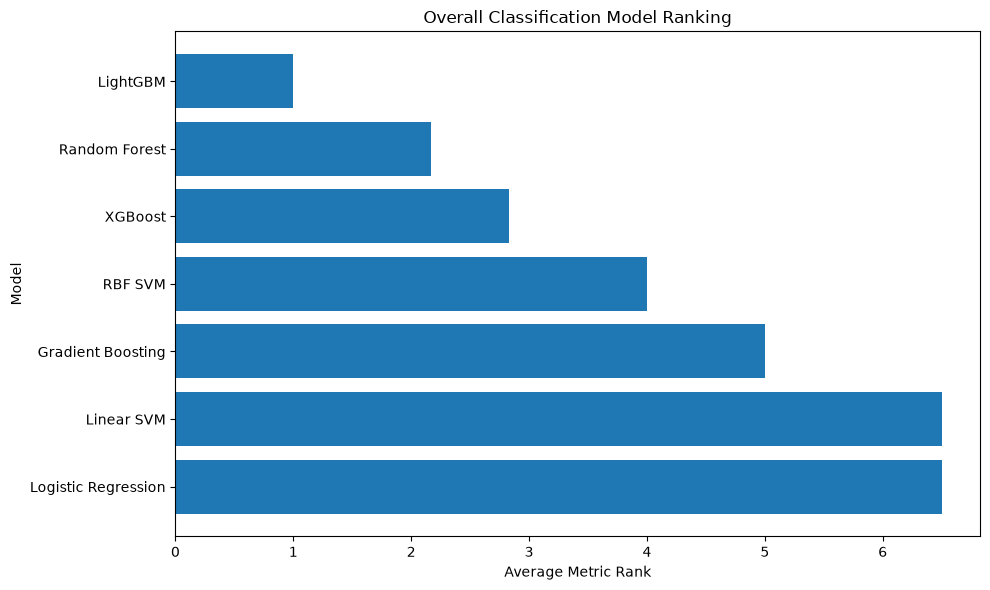

In [193]:
ranking_plot = overall_ranking.sort_values(
    "Average Rank",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    ranking_plot["Model"],
    ranking_plot["Average Rank"]
)

plt.xlabel("Average Metric Rank")
plt.ylabel("Model")
plt.title("Overall Classification Model Ranking")
plt.tight_layout()
plt.show()

## 15.41 ROC-AUC Ranking

ROC-AUC measures the ability of a classifier to rank positive observations above negative observations across different decision thresholds.

If the primary objective is discrimination, ROC-AUC can be an appropriate model-selection metric.

We therefore create a dedicated ROC-AUC ranking.


In [194]:
roc_ranking = cv_results[
    [
        "Model",
        "roc_auc_mean",
        "roc_auc_std"
    ]
].copy()

roc_ranking["Rank"] = (
    roc_ranking["roc_auc_mean"]
    .rank(ascending=False, method="min")
)

roc_ranking = roc_ranking.sort_values(
    "Rank"
).reset_index(drop=True)

roc_ranking

,Model,roc_auc_mean,roc_auc_std,Rank
0,LightGBM,0.949320,0.003784,1.0
1,Random Forest,0.947109,0.003180,2.0
2,XGBoost,0.941989,0.002133,3.0
3,RBF SVM,0.936340,0.003362,4.0
4,Gradient Boosting,0.926216,0.001311,5.0
5,Logistic Regression,0.727671,0.011074,6.0
6,Linear SVM,0.718159,0.012453,7.0


## 15.42 PR-AUC Ranking

PR-AUC emphasizes the relationship between precision and recall.

This can be particularly informative when the positive class is relatively uncommon.

Therefore, if identifying positive observations is especially important, PR-AUC may be more informative than accuracy or even ROC-AUC.


In [195]:
pr_ranking = cv_results[
    [
        "Model",
        "pr_auc_mean",
        "pr_auc_std"
    ]
].copy()

pr_ranking["Rank"] = (
    pr_ranking["pr_auc_mean"]
    .rank(ascending=False, method="min")
)

pr_ranking = pr_ranking.sort_values(
    "Rank"
).reset_index(drop=True)

pr_ranking

,Model,pr_auc_mean,pr_auc_std,Rank
0,LightGBM,0.927513,0.008282,1.0
1,Random Forest,0.919223,0.007593,2.0
2,XGBoost,0.915992,0.009129,3.0
3,RBF SVM,0.903089,0.005526,4.0
4,Gradient Boosting,0.887609,0.012457,5.0
5,Linear SVM,0.596336,0.012468,6.0
6,Logistic Regression,0.573248,0.018775,7.0


## 15.43 Metric-Specific Model Selection

The appropriate model depends on the objective.

### If overall correctness matters

Accuracy may be useful.

$$
\max \text{Accuracy}
$$

### If false positives are expensive

Precision becomes more important.

$$
\max \text{Precision}
$$

### If missing positive cases is expensive

Recall becomes more important.

$$
\max \text{Recall}
$$

### If precision and recall must both be considered

F1 is useful.

$$
\max F_1
$$

### If ranking quality is the main concern

ROC-AUC can be appropriate.

$$
\max \text{ROC-AUC}
$$

### If the positive class is relatively rare

PR-AUC can be particularly informative.

$$
\max \text{PR-AUC}
$$

Thus:

$$
\boxed{
\text{Best Model}
=
\text{Model that best satisfies the actual objective}
}
$$


## 15.44 A More Realistic Selection Criterion

In a real machine-learning project, model selection usually involves more than simply maximizing one metric.

For example, suppose two models have:

$$
M_A:
\quad
\text{ROC-AUC}=0.94\pm0.01
$$

and

$$
M_B:
\quad
\text{ROC-AUC}=0.95\pm0.06.
$$

Model $B$ has the higher mean score, but Model $A$ is substantially more stable.

We may prefer Model $A$ if consistent performance is important.

We should therefore consider:

$$
\boxed{
\text{Model Selection}
=
\text{Performance}
+
\text{Stability}
+
\text{Generalization}
+
\text{Application Cost}
}
$$

The final criterion should be defined before looking at the final test result.

This helps prevent selecting a model simply because it happened to perform best on one particular dataset split.


## 15.45 Select the Candidate Model

For this notebook, we will use **ROC-AUC as the primary ranking metric**, while also considering PR-AUC, F1, variability, and the generalization gap.

We are not yet evaluating the final test set.

Instead, we identify the strongest candidate using only cross-validation results.

This follows the correct conceptual workflow:

$$
\boxed{
\text{Training Data}
\rightarrow
\text{Cross-Validation}
\rightarrow
\text{Model Selection}
\rightarrow
\text{Final Test Evaluation}
}
$$

The final test set should only be used after the model-selection process has been completed.


In [196]:
best_model_row = cv_results.loc[
    cv_results["roc_auc_mean"].idxmax()
]

best_model_name = best_model_row["Model"]

print("Candidate model selected using CV ROC-AUC:")
print(best_model_name)

print(
    f"\nMean ROC-AUC: "
    f"{best_model_row['roc_auc_mean']:.4f}"
)

print(
    f"ROC-AUC Std: "
    f"{best_model_row['roc_auc_std']:.4f}"
)

print(
    f"Mean PR-AUC: "
    f"{best_model_row['pr_auc_mean']:.4f}"
)

print(
    f"Mean F1: "
    f"{best_model_row['f1_mean']:.4f}"
)

Candidate model selected using CV ROC-AUC:
LightGBM

Mean ROC-AUC: 0.9493
ROC-AUC Std: 0.0038
Mean PR-AUC: 0.9275
Mean F1: 0.8509


## 15.46 Important Methodological Note

The candidate selected above is the model with the highest mean cross-validation ROC-AUC.

However, this does **not** mean that it is universally the best classifier.

The selection is conditional on:

* This dataset
* This feature representation
* These hyperparameters
* These evaluation metrics
* This cross-validation strategy

A different dataset or objective could produce a different winner.

Furthermore, cross-validation does not eliminate all sources of uncertainty.

For a rigorous research experiment, we may additionally consider:

* Repeated cross-validation
* Confidence intervals
* Statistical comparison of paired fold scores
* Hyperparameter optimization
* Nested cross-validation

The important principle is:

$$
\boxed{
\text{Cross-validation provides evidence, not certainty}
}
$$


## 15.47 Section Takeaway

Cross-validation gives us a more reliable way to compare classifiers than relying on a single train/test split.

We learned that:

* `StratifiedKFold` preserves class proportions.
* Preprocessing must occur inside the cross-validation pipeline.
* Multiple metrics should be considered.
* Mean performance measures average validation quality.
* Standard deviation measures fold-to-fold variability.
* Training-validation gaps provide evidence about generalization.
* Different metrics can produce different model rankings.
* There is no universally best classifier.
* The application determines which metric matters most.
* The final test set should remain untouched during model selection.

The overall evaluation process is:

$$
\boxed{
\text{Stratified CV}
\rightarrow
\text{Performance}
\rightarrow
\text{Stability}
\rightarrow
\text{Generalization}
\rightarrow
\text{Model Selection}
}
$$

We now have a principled candidate model.

The next step is to move from **model selection** to **error analysis**, where we investigate *why* classifiers make mistakes and where their predictions disagree.


# 16. Model Selection & Error Analysis

A high validation score does not explain **where** a classifier fails.

Error analysis examines the predictions made by the selected model and helps identify:

* False positives
* False negatives
* Difficult observations
* Systematic errors
* Differences between competing models

The objective is to move from:

$$
\text{How good is the model?}
$$

to:

$$
\boxed{\text{Where and why does the model fail?}}
$$


## 16.1 Refit the Selected Model

We first retrieve the model selected through cross-validation and fit it on the complete training dataset.

The test set remains reserved for evaluation.


In [197]:
selected_model = models_for_cv[best_model_name]

selected_model.fit(X_train, y_train)

y_pred_selected = selected_model.predict(X_test)
y_prob_selected = selected_model.predict_proba(X_test)[:, 1]

print("Selected model:", best_model_name)

Selected model: LightGBM


## 16.2 Final Test Metrics

We now evaluate the selected candidate on the test set.

This is the first point in this model-selection workflow where the selected model is evaluated against the held-out test data.


In [198]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_selected),
    "Precision": precision_score(y_test, y_pred_selected),
    "Recall": recall_score(y_test, y_pred_selected),
    "F1": f1_score(y_test, y_pred_selected),
    "ROC-AUC": roc_auc_score(y_test, y_prob_selected),
    "PR-AUC": average_precision_score(y_test, y_prob_selected)
}

pd.Series(final_metrics).round(4)

Accuracy     0.9025
Precision    0.8997
Recall       0.8178
F1           0.8568
ROC-AUC      0.9464
PR-AUC       0.9102
dtype: float64

## 16.3 Confusion Matrix

The confusion matrix shows exactly how the classifier's predictions are distributed.

$$
\begin{array}{c|cc}
 & \hat{Y}=0 & \hat{Y}=1\\
\hline
Y=0 & TN & FP\\
Y=1 & FN & TP
\end{array}
$$

This allows us to distinguish between false positives and false negatives.


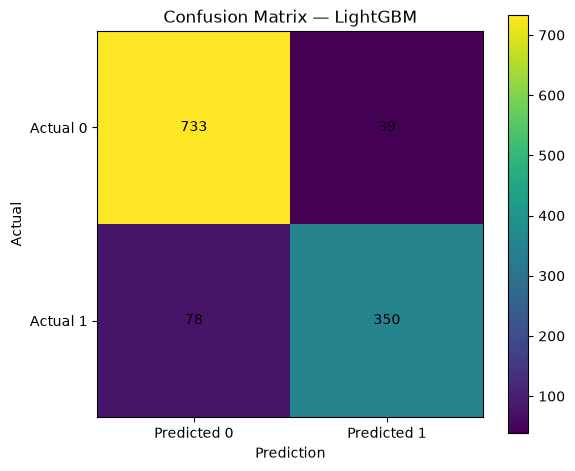

In [199]:
cm = confusion_matrix(
    y_test,
    y_pred_selected
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")

plt.colorbar()
plt.tight_layout()
plt.show()

## 16.4 Locate Misclassified Samples

We can explicitly identify the observations that the model classified incorrectly.

This is useful for investigating whether errors are random or whether they follow a pattern.


In [200]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.to_numpy()
error_analysis["Predicted"] = y_pred_selected
error_analysis["Probability"] = y_prob_selected

errors = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
].copy()

print("Total test samples:", len(error_analysis))
print("Misclassified samples:", len(errors))
print(
    "Error rate:",
    round(len(errors) / len(error_analysis), 4)
)

errors.head(10)

Total test samples: 1200
Misclassified samples: 117
Error rate: 0.0975


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,Actual,Predicted,Probability
1459,1.685491,-0.179843,1.535005,-3.653530,-0.064660,0.007665,0.993848,-1.817364,0.433957,-1.538765,...,-0.540091,-0.959054,1.686737,-0.729022,-0.359064,0.755928,1.204813,1,0,0.117422
1523,0.227077,-1.057182,1.874118,-3.511533,0.403992,4.676739,-0.815371,-1.319886,0.637050,-1.625650,...,0.976897,-0.027181,-0.484130,2.070263,0.019482,0.154796,-2.110072,0,1,0.759976
1738,-0.294570,0.608444,1.235184,-3.961347,-0.365586,3.597909,-1.257307,-0.315883,-1.129600,0.752293,...,-1.239000,0.313243,1.393148,0.881281,0.049251,0.476940,-2.599100,1,0,0.118360
733,-0.297837,0.633986,2.311015,-3.932552,0.734807,1.797924,-0.300300,0.238084,-0.436015,-0.495658,...,-1.100390,4.868037,-2.896087,-0.467527,-0.560750,0.537067,2.752803,1,0,0.007013
3316,1.539721,-0.399315,1.735178,-6.315232,-0.445222,3.310206,-0.869911,-3.032815,-0.779470,-3.690446,...,-1.082488,-2.000218,0.264058,-1.760515,0.858873,1.179238,1.086324,1,0,0.285642
5192,1.517758,-1.593075,-0.899325,-6.167536,0.236626,2.424599,-1.013586,-2.027005,-1.888716,0.610869,...,0.450529,0.826520,2.158882,-1.886823,-0.364244,-0.516285,3.144397,1,0,0.273044
5376,0.131736,-1.073545,-4.347363,3.472001,0.696869,4.696065,0.052482,0.018646,0.811235,-0.978138,...,1.825375,0.110680,-0.166814,2.670744,1.188495,-0.683458,-1.672114,0,1,0.976399
3609,0.162016,-1.162280,-0.632892,-5.608492,-1.966227,4.593761,-1.133518,-2.779832,0.637275,0.015394,...,0.108889,-1.467421,2.373217,-1.714166,-0.263707,-1.536491,0.195319,1,0,0.001760
5266,1.070976,-0.218232,1.232112,-4.176932,-1.713393,3.463134,-0.045911,0.076746,-0.422075,-1.207483,...,0.025976,1.247710,1.655695,0.947766,0.384919,-0.857536,-2.013808,1,0,0.090553
5905,-0.241473,-0.629632,1.382237,3.233002,0.294151,-5.108959,-0.733734,2.119030,0.606703,2.270212,...,-0.877721,-1.894849,0.696040,1.427261,-0.608834,0.320582,-2.731377,1,0,0.405989


## 16.5 Confidence of Errors

A particularly interesting group consists of **high-confidence mistakes**.

For binary classification, predictions close to:

$$
0.5
$$

are uncertain, while predictions close to $0$ or $1$ are more confident.

We can therefore examine errors where the model was highly confident.


In [201]:
errors["Confidence"] = np.abs(
    errors["Probability"] - 0.5
)

high_confidence_errors = errors.sort_values(
    "Confidence",
    ascending=False
)

high_confidence_errors.head(10)

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,Actual,Predicted,Probability,Confidence
4696,-2.519595,-0.022031,0.591226,-5.367613,-0.300802,6.522307,-0.435070,-5.045809,1.141266,-3.320065,...,-1.209431,-3.128698,-5.123283,-0.057368,-0.312773,3.578037,1,0,0.000898,0.499102
3609,0.162016,-1.162280,-0.632892,-5.608492,-1.966227,4.593761,-1.133518,-2.779832,0.637275,0.015394,...,-1.467421,2.373217,-1.714166,-0.263707,-1.536491,0.195319,1,0,0.001760,0.498240
2149,-1.363189,-1.401543,-0.345076,-0.949973,0.000110,4.528429,-1.035657,-2.723092,1.233535,-2.192090,...,-0.186199,-4.040613,-0.575001,-0.686839,1.844735,2.140464,1,0,0.001896,0.498104
1236,-2.255433,0.256525,-1.789307,5.188358,-0.389650,-5.732710,0.133337,2.232748,0.157719,2.296973,...,-5.309515,3.657732,-4.325514,0.776864,-0.553129,-3.903911,0,1,0.997983,0.497983
3220,-0.842384,-0.721000,1.053912,-2.989317,-0.158429,3.942528,0.635141,-2.868638,-1.091356,-2.847044,...,1.287795,-3.249727,-1.661954,1.144515,-0.460444,3.353397,1,0,0.003064,0.496936
611,-1.930344,-0.714123,1.362436,-2.615189,0.275212,5.291733,-1.353155,-2.586412,0.772319,-2.317042,...,0.706155,-4.785532,-0.666600,0.917011,-0.816121,1.632754,1,0,0.003086,0.496914
1154,-1.962877,-0.519312,-3.547681,4.804711,0.321455,-3.920007,-1.938982,0.636990,-0.593493,1.999358,...,-4.827652,0.611462,-4.050959,-0.397615,-0.520290,-0.292334,0,1,0.996648,0.496648
59,-2.867852,0.426909,-2.645060,5.930043,0.339741,1.864602,1.094393,2.014728,-1.246467,-2.031857,...,-1.346401,-0.772717,-1.752731,0.999897,1.382372,-4.253682,0,1,0.995891,0.495891
4595,-0.884817,-0.841795,-0.302093,0.679965,-0.203397,-2.099768,-0.392466,1.767645,0.867385,1.247568,...,-1.929632,2.711894,-2.322810,0.855440,-0.588778,-2.954354,0,1,0.994839,0.494839
314,-1.291495,0.753290,-2.636338,-0.304787,1.247768,3.267071,1.081978,-3.743891,-0.492400,-1.233407,...,-1.471778,-0.768784,-3.155356,-1.444372,1.598720,3.626862,1,0,0.006117,0.493883


## 16.6 Error Analysis Takeaway

Error analysis reveals information that aggregate metrics cannot show.

Important questions include:

* Are false negatives more common than false positives?
* Are errors concentrated around uncertain probabilities?
* Are there high-confidence mistakes?
* Do certain feature patterns appear repeatedly among errors?

Therefore:

$$
\boxed{
\text{Model Evaluation}
=
\text{Metrics}
+
\text{Error Analysis}
}
$$

A strong ML workflow does not stop after obtaining a high score. It investigates the model's failures and uses those findings to improve the next modeling iteration.


# 17. Multiclass Classification

So far, most experiments have focused on binary classification:

$$
Y\in\{0,1\}
$$

Many real-world problems contain more than two classes:

$$
Y\in\{1,2,\ldots,K\}
$$

Examples include:

* Image classification
* Handwritten digit recognition
* Document classification
* Disease-category prediction
* Customer segmentation

In this section, we will examine how modern classifiers handle multiple classes.

We will focus on:

* Multiclass logistic regression
* One-vs-Rest (OvR)
* One-vs-One (OvO)
* Multiclass evaluation
* Confusion matrices


In [202]:
from sklearn.datasets import make_classification

X_multi, y_multi = make_classification(
    n_samples=5000,
    n_features=15,
    n_informative=8,
    n_redundant=3,
    n_classes=4,
    n_clusters_per_class=1,
    class_sep=1.0,
    random_state=RANDOM_STATE
)

X_multi = pd.DataFrame(
    X_multi,
    columns=[f"feature_{i+1}" for i in range(X_multi.shape[1])]
)

y_multi = pd.Series(
    y_multi,
    name="target"
)

print("Features:", X_multi.shape)
print("Classes:", y_multi.nunique())

Features: (5000, 15)
Classes: 4


## 17.1 Inspect Class Distribution

Before training a multiclass classifier, we should inspect the number of observations belonging to each class.


target
0    1249
1    1248
2    1254
3    1249
Name: count, dtype: int64


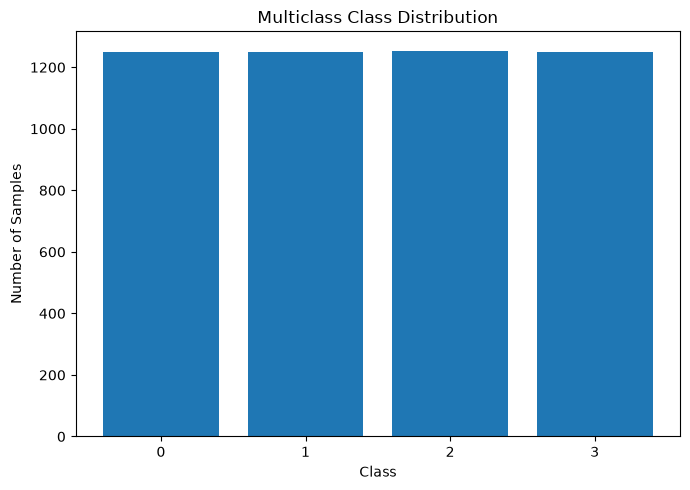

In [203]:
class_counts = y_multi.value_counts().sort_index()

print(class_counts)

plt.figure(figsize=(7, 5))

plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Multiclass Class Distribution")

plt.tight_layout()
plt.show()

In [204]:
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.20,
    stratify=y_multi,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_multi_train))
print("Test samples:", len(X_multi_test))

Training samples: 4000
Test samples: 1000


## 17.3 Multiclass Logistic Regression

For multiclass classification, logistic regression can estimate a probability for every class.

For $K$ classes, the softmax function is:

$$
P(Y=k\mid X=x)
=
\frac{
e^{w_k^Tx+b_k}
}{
\sum_{j=1}^{K}e^{w_j^Tx+b_j}
}
$$

The probabilities satisfy:

$$
\sum_{k=1}^{K}P(Y=k\mid X=x)=1
$$

The predicted class is:

$$
\hat{y}
=
\arg\max_k P(Y=k\mid X=x)
$$


In [206]:
multiclass_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

multiclass_logistic.fit(
    X_multi_train,
    y_multi_train
)

y_multi_pred = multiclass_logistic.predict(
    X_multi_test
)

y_multi_prob = multiclass_logistic.predict_proba(
    X_multi_test
)

print("Probability matrix shape:", y_multi_prob.shape)
print("First probability vector:")
print(y_multi_prob[0])
print("Probability sum:", y_multi_prob[0].sum())

Probability matrix shape: (1000, 4)
First probability vector:
[0.180083   0.18736234 0.25448994 0.37806472]
Probability sum: 1.0


## 17.4 Multiclass Metrics

Binary metrics need to be adapted for multiclass classification.

Two common averaging strategies are:

### Macro averaging

Calculate the metric independently for each class and then take the unweighted mean:

$$
M_{\text{macro}}
=
\frac{1}{K}
\sum_{k=1}^{K}M_k
$$

Every class receives equal importance.

### Weighted averaging

Weight each class according to its number of observations:

$$
M_{\text{weighted}}
=
\sum_{k=1}^{K}
\frac{n_k}{n}M_k
$$

This gives larger classes greater influence.

Macro metrics are particularly useful when performance on every class matters.


In [208]:
multi_accuracy = accuracy_score(
    y_multi_test,
    y_multi_pred
)

multi_precision_macro = precision_score(
    y_multi_test,
    y_multi_pred,
    average="macro"
)

multi_recall_macro = recall_score(
    y_multi_test,
    y_multi_pred,
    average="macro"
)

multi_f1_macro = f1_score(
    y_multi_test,
    y_multi_pred,
    average="macro"
)

multi_f1_weighted = f1_score(
    y_multi_test,
    y_multi_pred,
    average="weighted"
)

multiclass_metrics = {
    "Accuracy": multi_accuracy,
    "Macro Precision": multi_precision_macro,
    "Macro Recall": multi_recall_macro,
    "Macro F1": multi_f1_macro,
    "Weighted F1": multi_f1_weighted
}

pd.Series(multiclass_metrics).round(4)

Accuracy           0.7990
Macro Precision    0.7993
Macro Recall       0.7990
Macro F1           0.7982
Weighted F1        0.7982
dtype: float64

## 17.5 Classification Report

In [209]:
print(
    classification_report(
        y_multi_test,
        y_multi_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       250
           1       0.83      0.75      0.79       249
           2       0.75      0.74      0.74       251
           3       0.71      0.75      0.73       250

    accuracy                           0.80      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.80      0.80      0.80      1000



## 17.6 Multiclass Confusion Matrix

A multiclass confusion matrix shows which classes are confused with one another.

The diagonal represents correct predictions:

$$
CM_{kk}=TP_k
$$

while off-diagonal entries represent classification errors between different classes.


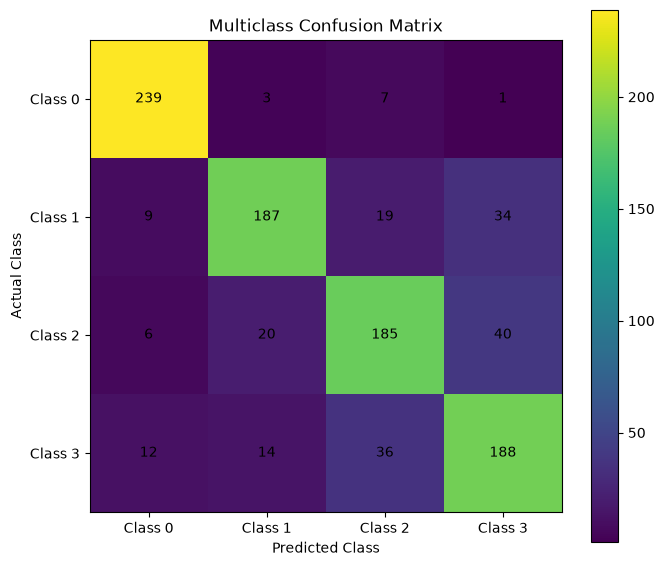

In [210]:
multi_cm = confusion_matrix(
    y_multi_test,
    y_multi_pred
)

plt.figure(figsize=(7, 6))

plt.imshow(multi_cm)

plt.xticks(
    range(4),
    [f"Class {i}" for i in range(4)]
)

plt.yticks(
    range(4),
    [f"Class {i}" for i in range(4)]
)

for i in range(4):
    for j in range(4):
        plt.text(
            j,
            i,
            multi_cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Multiclass Confusion Matrix")
plt.colorbar()

plt.tight_layout()
plt.show()

## 17.7 One-vs-Rest (OvR)

One-vs-Rest converts a $K$-class problem into $K$ binary classification problems.

For four classes:

```text
Classifier 1 → Class 0 vs All Other Classes
Classifier 2 → Class 1 vs All Other Classes
Classifier 3 → Class 2 vs All Other Classes
Classifier 4 → Class 3 vs All Other Classes
```

For class $k$:

$$
y_k=
\begin{cases}
1 & \text{if } y=k\\
0 & \text{otherwise}
\end{cases}
$$

The final prediction is typically the class with the strongest decision score.

OvR is attractive because it is conceptually simple and works naturally with many binary classifiers.


In [211]:
from sklearn.multiclass import OneVsRestClassifier

ovr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", OneVsRestClassifier(
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    ))
])

ovr_model.fit(
    X_multi_train,
    y_multi_train
)

y_ovr_pred = ovr_model.predict(
    X_multi_test
)

print(
    "OvR Accuracy:",
    round(
        accuracy_score(
            y_multi_test,
            y_ovr_pred
        ),
        4
    )
)

OvR Accuracy: 0.789


## 17.8 One-vs-One (OvO)

One-vs-One trains a separate binary classifier for every pair of classes.

For $K$ classes, the number of classifiers is:

$$
\boxed{
\frac{K(K-1)}{2}
}
$$

For four classes:

$$
\frac{4(4-1)}{2}=6
$$

So the classifiers are:

```text
Class 0 vs Class 1
Class 0 vs Class 2
Class 0 vs Class 3
Class 1 vs Class 2
Class 1 vs Class 3
Class 2 vs Class 3
```

The individual binary classifiers then contribute to the final multiclass prediction.

OvO can be especially useful for algorithms such as SVMs.


In [212]:
from sklearn.multiclass import OneVsOneClassifier

ovo_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", OneVsOneClassifier(
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    ))
])

ovo_model.fit(
    X_multi_train,
    y_multi_train
)

y_ovo_pred = ovo_model.predict(
    X_multi_test
)

print(
    "OvO Accuracy:",
    round(
        accuracy_score(
            y_multi_test,
            y_ovo_pred
        ),
        4
    )
)

OvO Accuracy: 0.854


## 17.9 Multiclass Classification Takeaway

Multiclass classification extends binary classification to:

$$
Y\in\{1,\ldots,K\}
$$

Important concepts include:

* **Softmax** for multiclass probabilities
* **Macro averaging** for equal class importance
* **Weighted averaging** for class-frequency-aware evaluation
* **One-vs-Rest** using $K$ binary classifiers
* **One-vs-One** using $\frac{K(K-1)}{2}$ binary classifiers
* Multiclass confusion matrices for error analysis

The main idea is:

$$
\boxed{
\text{Binary Classification Techniques}
\rightarrow
\text{Multiclass Decision Strategy}
}
$$




## 18.1 Why Combine Classifiers?

Different classifiers make different errors.

Instead of relying on one model, ensemble methods combine several models to produce a final prediction.

The intuition is:

$$
\boxed{
\text{Multiple Diverse Models}
\rightarrow
\text{Combined Decision}
}
$$

Two important ensemble strategies are:

* **Voting** — combine predictions from several classifiers.
* **Stacking** — train a second-level model to learn how to combine the base classifiers.

The goal is not simply to use more models, but to combine models whose errors are sufficiently different.


## 18.2 Voting Classifier

A voting classifier combines predictions from multiple base classifiers.

For **hard voting**, each classifier produces a class prediction:

$$
\hat y_1,\hat y_2,\ldots,\hat y_M
$$

and the final prediction is determined by majority vote.

For **soft voting**, the predicted probabilities are averaged:

$$
P(y=k|x)
=
\frac{1}{M}
\sum_{m=1}^{M}
P_m(y=k|x)
$$

The class with the highest combined probability is selected.

Soft voting can be useful when the component classifiers provide meaningful probability estimates.


In [213]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        (
            "logistic",
            Pipeline([
                ("scaler", StandardScaler()),
                ("classifier", LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE
                ))
            ])
        ),
        (
            "rbf_svm",
            Pipeline([
                ("scaler", StandardScaler()),
                ("classifier", SVC(
                    kernel="rbf",
                    C=2.0,
                    probability=True,
                    random_state=RANDOM_STATE
                ))
            ])
        ),
        (
            "random_forest",
            RandomForestClassifier(
                n_estimators=300,
                max_features="sqrt",
                n_jobs=-1,
                random_state=RANDOM_STATE
            )
        )
    ],
    voting="soft"
)

voting_model.fit(
    X_train,
    y_train
)

y_pred_voting = voting_model.predict(X_test)
y_prob_voting = voting_model.predict_proba(X_test)[:, 1]

print(
    "Voting ROC-AUC:",
    round(
        roc_auc_score(y_test, y_prob_voting),
        4
    )
)

print(
    "Voting F1:",
    round(
        f1_score(y_test, y_pred_voting),
        4
    )
)

Voting ROC-AUC: 0.9345
Voting F1: 0.8325


## 18.3 Compare Voting with Individual Models

The ensemble should not automatically be assumed to be better.

We compare it with the individual classifiers using the same test-set metrics.


In [216]:
# Refit RBF SVM for a clean comparison

rbf_svm_comparison = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=2.0,
        gamma="scale",
        probability=True,
        random_state=RANDOM_STATE
    ))
])

rbf_svm_comparison.fit(
    X_train,
    y_train
)

y_pred_rbf_comparison = rbf_svm_comparison.predict(X_test)
y_prob_rbf_comparison = rbf_svm_comparison.predict_proba(X_test)[:, 1]


voting_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "RBF SVM",
        "Random Forest",
        "Soft Voting"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_rbf_comparison),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_voting)
    ],
    "F1": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rbf_comparison),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_voting)
    ]
})

voting_comparison.round(4)

,Model,ROC-AUC,F1
0,Logistic Regression,0.7280,0.5118
1,RBF SVM,0.9358,0.8259
2,Random Forest,0.9467,0.8477
3,Soft Voting,0.9345,0.8325


## 18.4 Stacking

Stacking uses multiple base classifiers and trains a **meta-model** to combine their predictions.

Conceptually:

```text
Input Features
      │
      ├── Logistic Regression ──┐
      ├── RBF SVM ──────────────┤
      └── Random Forest ────────┤
                                ↓
                         Meta-Classifier
                                ↓
                           Final Prediction
```

The base models generate predictions that become inputs to the meta-model.

The meta-model learns:

$$
\hat y
=
g(
f_1(x),
f_2(x),
\ldots,
f_M(x)
)
$$

where $f_1,\ldots,f_M$ are the base classifiers and $g$ is the meta-classifier.

A major advantage of stacking is that the meta-model can learn that some classifiers are more useful than others for particular patterns.


In [215]:
from sklearn.ensemble import StackingClassifier

stacking_model = StackingClassifier(
    estimators=[
        (
            "logistic",
            Pipeline([
                ("scaler", StandardScaler()),
                ("classifier", LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE
                ))
            ])
        ),
        (
            "rbf_svm",
            Pipeline([
                ("scaler", StandardScaler()),
                ("classifier", SVC(
                    kernel="rbf",
                    C=2.0,
                    probability=True,
                    random_state=RANDOM_STATE
                ))
            ])
        ),
        (
            "random_forest",
            RandomForestClassifier(
                n_estimators=300,
                max_features="sqrt",
                n_jobs=-1,
                random_state=RANDOM_STATE
            )
        )
    ],
    final_estimator=LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    stack_method="predict_proba",
    cv=5,
    n_jobs=1
)

stacking_model.fit(
    X_train,
    y_train
)

y_pred_stacking = stacking_model.predict(X_test)
y_prob_stacking = stacking_model.predict_proba(X_test)[:, 1]

print(
    "Stacking ROC-AUC:",
    round(
        roc_auc_score(y_test, y_prob_stacking),
        4
    )
)

print(
    "Stacking F1:",
    round(
        f1_score(y_test, y_pred_stacking),
        4
    )
)

Stacking ROC-AUC: 0.9489
Stacking F1: 0.8571


## 18.5 Voting vs Stacking

| Method      | Combination Strategy  | Complexity |
| ----------- | --------------------- | ---------- |
| Hard Voting | Majority class vote   | Low        |
| Soft Voting | Average probabilities | Low        |
| Stacking    | Learned meta-model    | Higher     |

Voting uses a predefined combination rule.

Stacking learns the combination rule from data.

Therefore:

$$
\boxed{
\text{Voting} \rightarrow \text{Fixed Combination}
}
$$

while:

$$
\boxed{
\text{Stacking} \rightarrow \text{Learned Combination}
}
$$


## 18.6 Ensemble Takeaway

Combining classifiers can improve predictive performance when the component models make sufficiently different errors.

The main strategies covered here are:

* Hard voting
* Soft voting
* Stacking

However, an ensemble is **not automatically superior** to its individual components.

Its usefulness depends on:

* Model diversity
* Base-model quality
* Correlation between errors
* Calibration
* Dataset size
* Computational cost

The central principle is:

$$
\boxed{
\text{Useful Ensemble}
\approx
\text{Strong Models}
+
\text{Complementary Errors}
}
$$




# 19. End-to-End Classification Pipeline

A practical classification system should not consist of an isolated model.

A complete workflow combines:

$$
\boxed{
\text{Data}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Model Selection}
\rightarrow
\text{Probability Estimation}
\rightarrow
\text{Calibration}
\rightarrow
\text{Threshold Selection}
\rightarrow
\text{Final Evaluation}
}
$$

The important principle is to keep the roles of the datasets separate:

```text id="4q2w8e"
Training Data
      │
      ├── Cross-Validation
      │       └── Model Selection
      │
      └── Fit Selected Model
              │
              └── Threshold / Calibration
                      
Test Data
      │
      └── Final Evaluation
```

The test set should not influence model selection.


## 19.1 Select a Final Candidate

We use the cross-validation ROC-AUC result from Section 15 to identify the candidate model.

This selection is based on validation performance rather than the test set.


In [217]:
best_model_name = cv_results.loc[
    cv_results["roc_auc_mean"].idxmax(),
    "Model"
]

final_model = models_for_cv[best_model_name]

print("Selected model:", best_model_name)

Selected model: LightGBM


## 19.2 Fit the Final Model

After model selection, the chosen model can be trained on the complete training dataset.

The test set remains untouched until final evaluation.


In [219]:
final_model.fit(
    X_train,
    y_train
)

y_final_pred = final_model.predict(X_test)
y_final_prob = final_model.predict_proba(X_test)[:, 1]

print("Final model fitted successfully.")

Final model fitted successfully.


In [220]:
## 19.3 Final Evaluation
final_results = {
    "Accuracy": accuracy_score(
        y_test,
        y_final_pred
    ),
    "Precision": precision_score(
        y_test,
        y_final_pred
    ),
    "Recall": recall_score(
        y_test,
        y_final_pred
    ),
    "F1": f1_score(
        y_test,
        y_final_pred
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_final_prob
    ),
    "PR-AUC": average_precision_score(
        y_test,
        y_final_prob
    )
}

pd.Series(final_results).round(4)

Accuracy     0.9025
Precision    0.8997
Recall       0.8178
F1           0.8568
ROC-AUC      0.9464
PR-AUC       0.9102
dtype: float64

## 19.4 Final ROC and Precision-Recall Curves

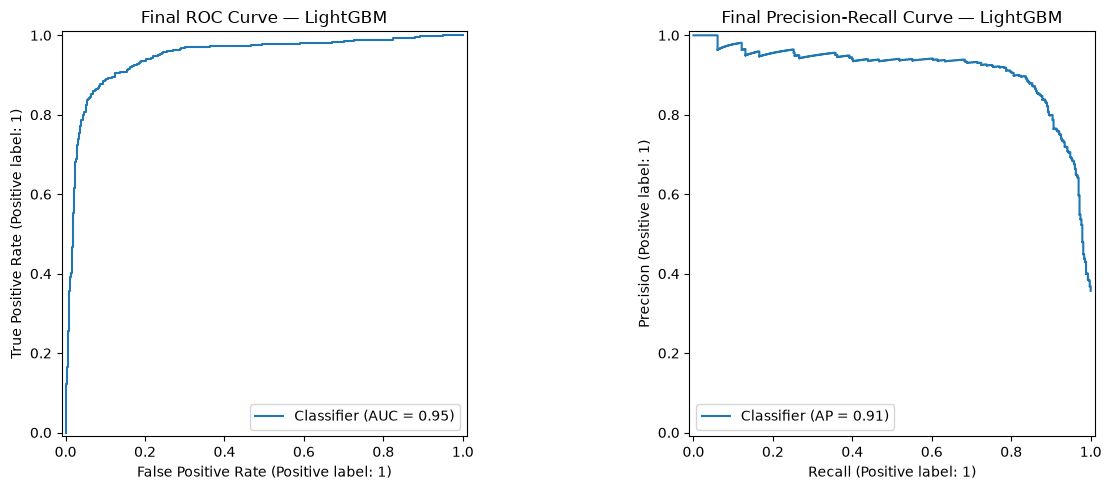

In [222]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_final_prob,
    ax=axes[0]
)

axes[0].set_title(
    f"Final ROC Curve — {best_model_name}"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_final_prob,
    ax=axes[1]
)

axes[1].set_title(
    f"Final Precision-Recall Curve — {best_model_name}"
)

plt.tight_layout()
plt.show()

## 19.5 Final Confusion Matrix

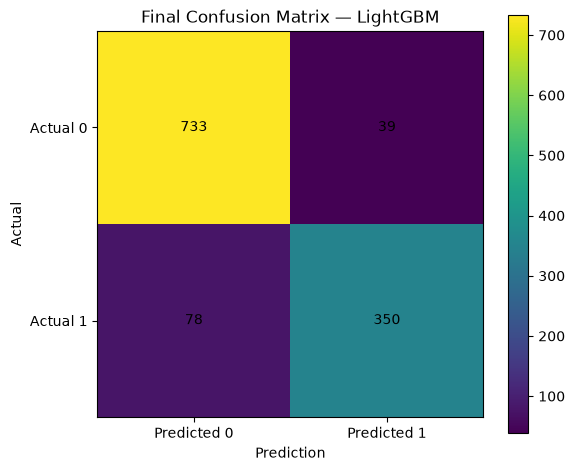

In [223]:
final_cm = confusion_matrix(
    y_test,
    y_final_pred
)

plt.figure(figsize=(6, 5))

plt.imshow(final_cm)

plt.xticks(
    [0, 1],
    ["Predicted 0", "Predicted 1"]
)

plt.yticks(
    [0, 1],
    ["Actual 0", "Actual 1"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            final_cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title(f"Final Confusion Matrix — {best_model_name}")
plt.colorbar()

plt.tight_layout()
plt.show()

In [224]:
## 19.6 Final Classification Report
print(
    classification_report(
        y_test,
        y_final_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.95      0.93       772
           1       0.90      0.82      0.86       428

    accuracy                           0.90      1200
   macro avg       0.90      0.88      0.89      1200
weighted avg       0.90      0.90      0.90      1200



## 19.7 End-to-End Workflow Summary

The complete classification workflow developed in this notebook is:

$$
\boxed{
\begin{aligned}
&\text{1. Understand the data}\\
&\downarrow\\
&\text{2. Establish a baseline}\\
&\downarrow\\
&\text{3. Train candidate classifiers}\\
&\downarrow\\
&\text{4. Evaluate using appropriate metrics}\\
&\downarrow\\
&\text{5. Use cross-validation}\\
&\downarrow\\
&\text{6. Select a candidate model}\\
&\downarrow\\
&\text{7. Analyze errors}\\
&\downarrow\\
&\text{8. Calibrate probabilities when required}\\
&\downarrow\\
&\text{9. Select an appropriate decision threshold}\\
&\downarrow\\
&\text{10. Evaluate once on the held-out test set}
\end{aligned}
}
$$

This separation between **model learning**, **decision policy**, and **final evaluation** is one of the most important ideas in practical classification.


# 20. Final Summary & Classification Decision Guide

This notebook explored modern classification methods from classical probabilistic models to advanced ensembles and neural classifiers.

The central classification problem is:

$$
\hat{y}
=
\arg\max_{k}
P(Y=k\mid X=x)
$$

For binary classification, the predicted class can also be determined using a decision threshold:

$$
\hat{y}
=
\mathbb{1}[\hat{p}(x)\geq t]
$$

Therefore, a complete classification system contains two important components:

$$
\boxed{
\text{Probability Model}
+
\text{Decision Policy}
}
$$

---

## 20.1 Methods Covered

| Method              | Main Strength                              |
| ------------------- | ------------------------------------------ |
| Logistic Regression | Simple, interpretable baseline             |
| Linear SVM          | Effective linear maximum-margin classifier |
| RBF SVM             | Powerful nonlinear classification          |
| Random Forest       | Robust bagging-based ensemble              |
| Gradient Boosting   | Strong sequential tree ensemble            |
| XGBoost             | Regularized, high-performance boosting     |
| LightGBM            | Efficient gradient boosting                |
| CatBoost            | Native categorical-feature handling        |
| Neural Network      | Flexible nonlinear representation          |
| Voting              | Combines several classifiers               |
| Stacking            | Learns how to combine classifiers          |

---

## 20.2 Evaluation Concepts

We studied:

* Accuracy
* Precision
* Recall
* F1
* ROC-AUC
* PR-AUC
* Confusion matrices
* Probability calibration
* Brier score
* Threshold optimization
* Cost-sensitive classification
* Cross-validation
* Generalization gaps
* Error analysis

A strong evaluation framework is:

$$
\boxed{
\text{Performance}
+
\text{Calibration}
+
\text{Threshold}
+
\text{Error Analysis}
+
\text{Generalization}
}
$$

---

## 20.3 Choosing a Classifier

A useful practical guide is:

```text
Need interpretability?
        │
       Yes
        ↓
Logistic Regression

Need nonlinear decision boundaries?
        │
       Yes
        ↓
RBF SVM / Tree Ensembles

Need strong tabular-data performance?
        │
       Yes
        ↓
Gradient Boosting / XGBoost / LightGBM

Have many categorical features?
        │
       Yes
        ↓
CatBoost

Need highly flexible nonlinear representation?
        │
       Yes
        ↓
Neural Network

Have several strong but different models?
        │
       Yes
        ↓
Voting / Stacking
```

This is a guideline rather than a strict rule.

---

## 20.4 Metric Selection

The appropriate metric depends on the problem.

$$
\boxed{
\begin{array}{ll}
\text{Balanced classes} &\rightarrow \text{Accuracy}\\
\text{False positives costly} &\rightarrow \text{Precision}\\
\text{False negatives costly} &\rightarrow \text{Recall}\\
\text{Precision + Recall} &\rightarrow F_1\\
\text{Ranking quality} &\rightarrow \text{ROC-AUC}\\
\text{Rare positive class} &\rightarrow \text{PR-AUC}
\end{array}
}
$$

In real applications, business or operational costs should ultimately determine the evaluation criterion.

---

## 20.5 Most Important Lessons

### 1. No universally best classifier

$$
\boxed{
\text{Best Model}
\neq
\text{Best Model for Every Dataset}
}
$$

### 2. Accuracy is not enough

A classifier can have high accuracy while performing poorly on the class we actually care about.

### 3. Probabilities and decisions are different

A probability estimate does not automatically determine the correct decision threshold.

### 4. Calibration matters

A model can rank observations well while producing poorly calibrated probabilities.

### 5. Cross-validation improves model comparison

$$
\text{Multiple Validation Folds}
>
\text{Single Validation Split}
$$

for estimating performance more robustly.

### 6. Error analysis matters

A model's mistakes often reveal more useful information than its aggregate score.

### 7. Test data must remain isolated

The final test set should be used only after model development and selection are complete.

---

## 20.6 Final Classification Workflow

The complete workflow developed throughout this notebook is:

$$
\boxed{
\text{Data}
\rightarrow
\text{Baseline}
\rightarrow
\text{Candidate Models}
\rightarrow
\text{Cross-Validation}
\rightarrow
\text{Model Selection}
\rightarrow
\text{Calibration}
\rightarrow
\text{Threshold Optimization}
\rightarrow
\text{Error Analysis}
\rightarrow
\text{Final Test Evaluation}
}
$$

This workflow provides a strong foundation for building reliable classification systems.

---

## 20.7 Final Takeaway

Classification is not simply about training a model and calculating accuracy.

A mature classification workflow asks:

$$
\boxed{
\begin{aligned}
&\text{Can the model discriminate between classes?}\\
&\text{Are its probabilities reliable?}\\
&\text{Is the decision threshold appropriate?}\\
&\text{Does it generalize?}\\
&\text{Where does it make mistakes?}\\
&\text{Does it satisfy the application's actual objective?}
\end{aligned}
}
$$

The ultimate goal is therefore:

$$
\boxed{
\text{Reliable Predictions}
\rightarrow
\text{Reliable Decisions}
}
$$

**End of `02_Recent_Classification_Methods.ipynb`**


In [225]:
print("=" * 60)
print("02_Recent_Classification_Methods.ipynb")
print("Completed successfully.")
print("=" * 60)

print("\nFinal selected model:", best_model_name)

for metric, value in final_results.items():
    print(f"{metric:10s}: {value:.4f}")

02_Recent_Classification_Methods.ipynb
Completed successfully.

Final selected model: LightGBM
Accuracy  : 0.9025
Precision : 0.8997
Recall    : 0.8178
F1        : 0.8568
ROC-AUC   : 0.9464
PR-AUC    : 0.9102
